In [1]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from lifelines import CoxPHFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
import warnings
warnings.filterwarnings("ignore")


In [2]:
path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [7]:
df = pd.read_csv(path_data/"NAC_RNI_EGRESOS_ENTREGA_ISCI_24_10_2024_encr.CSV", encoding = "latin-1", sep = ";")
df_play = pd.read_csv(path_data/"NAC_RNI_EGRESOS_ENTREGA_ISCI_21_10_2024_encr.CSV", encoding = "latin-1", sep = ";")
df.head()

,RUN,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,INS_N_M,COMUNA,COMUNA_N,REG_RES,URBA_RURAL,NAC_MA,FECHA_INMUNIZACION,VACUNADO,FECHA_DEFUNCION,CAUSA_DEFUNCION,VIVO,FALLECIDO_PREVIO,ESTAB,ServicioSalud,Seremi,EDAD_CANT,TIPO_EDAD,ETNIA,T_ETNIA,P_ORIGEN,PREVI,FECHA_INGRESO,AREA_FUNC_I,SER_CLIN_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,SERC_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,SERC_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,SERC_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,SERC_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,SERC_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,SERC_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,SERC_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,SERC_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,SERC_9_TRAS,FECHA_EGRESO,AREAF_EGR,SERC_EGR,DIAS_ESTAD,COND_EGR,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,01OCT2023,10,2023,1,38.0,2865.0,46.0,17,3,2,13108,13108,13.0,0,C,NaN,SI,NaN,NaN,SI,VIVO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,02OCT2023,10,2023,1,38.0,2790.0,49.0,18,4,2,13108,13108,13.0,0,C,NaN,SI,NaN,NaN,SI,VIVO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc84...,01OCT2023,10,2023,2,34.0,1815.0,42.0,16,3,2,13127,13127,13.0,0,C,NaN,SI,NaN,NaN,SI,VIVO,109100.0,9.0,NaN,1.0,4.0,96.0,NaN,152.0,1.0,01OCT2023,414.0,311.0,8.0,10.0,2023.0,415.0,324.0,6.0,11.0,2023.0,413.0,152.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08NOV2023,413.0,152.0,38.0,1.0,P009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d...,01OCT2023,10,2023,2,34.0,2300.0,43.0,16,3,2,13127,13127,13.0,0,C,NaN,SI,NaN,NaN,SI,VIVO,109100.0,9.0,NaN,1.0,4.0,96.0,NaN,152.0,1.0,01OCT2023,414.0,311.0,12.0,10.0,2023.0,415.0,324.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30NOV2023,415.0,324.0,60.0,1.0,P027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d...,01OCT2023,10,2023,2,34.0,2300.0,43.0,16,3,2,13127,13127,13.0,0,C,NaN,SI,NaN,NaN,SI,VIVO,109101.0,9.0,NaN,2.0,2.0,96.0,NaN,152.0,1.0,02DEC2023,410.0,153.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11DEC2023,410.0,153.0,9.0,1.0,R11X,NaN,T801,K219,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
pd.set_option('display.max_columns', None)

In [5]:
df.shape[0]

173499

In [ ]:
df['PAIS_ORIGEN_M'].nunique()

In [7]:
df['FECHA_INMUNIZACION'].notna().value_counts()

FECHA_INMUNIZACION
True     153489
False     17293
Name: count, dtype: int64

In [8]:
df.columns

Index(['RUN', 'FECHA_NACIMIENTO', 'MES_NAC', 'ANO_NAC', 'SEXO', 'SEMANAS',
       'PESO', 'TALLA', 'EDAD_M', 'INS_C_M', 'INS_N_M', 'COMUNA', 'COMUNA_N',
       'REG_RES', 'URBA_RURAL', 'NAC_MA', 'FECHA_INMUNIZACION', 'VACUNADO',
       'FECHA_DEFUNCION', 'CAUSA_DEFUNCION', 'VIVO', 'FALLECIDO_PREVIO',
       'ESTAB', 'ServicioSalud', 'Seremi', 'EDAD_CANT', 'TIPO_EDAD', 'ETNIA',
       'T_ETNIA', 'P_ORIGEN', 'PREVI', 'FECHA_INGRESO', 'AREA_FUNC_I',
       'SER_CLIN_I', 'DIA_1_TRAS', 'MES_1_TRAS', 'ANO_1_TRAS', 'AREAF_1_TRAS',
       'SERC_1_TRAS', 'DIA_2_TRAS', 'MES_2_TRAS', 'ANO_2_TRAS', 'AREAF_2_TRAS',
       'SERC_2_TRAS', 'DIA_3_TRAS', 'MES_3_TRAS', 'ANO_3_TRAS', 'AREAF_3_TRAS',
       'SERC_3_TRAS', 'DIA_4_TRAS', 'MES_4_TRAS', 'ANO_4_TRAS', 'AREAF_4_TRAS',
       'SERC_4_TRAS', 'DIA_5_TRAS', 'MES_5_TRAS', 'ANO_5_TRAS', 'AREAF_5_TRAS',
       'SERC_5_TRAS', 'DIA_6_TRAS', 'MES_6_TRAS', 'ANO_6_TRAS', 'AREAF_6_TRAS',
       'SERC_6_TRAS', 'DIA_7_TRAS', 'MES_7_TRAS', 'ANO_7_TRAS', 'AREAF

In [9]:
# Obtener los nombres de las columnas en ambos DataFrames
columnas_df = set(df.columns)
columnas_df_play = set(df_play.columns)

# Encontrar las columnas que están en df pero no en df_play
diferentes_df = columnas_df - columnas_df_play

# Encontrar las columnas que están en df_play pero no en df
diferentes_df_play = columnas_df_play - columnas_df

# Imprimir las columnas diferentes
print("Columnas en df pero no en df_play:", diferentes_df)
print("Columnas en df_play pero no en df:", diferentes_df_play)

Columnas en df pero no en df_play: set()
Columnas en df_play pero no en df: set()


In [15]:
df.FALLECIDO_PREVIO.value_counts()

FALLECIDO_PREVIO
VIVO    169662
NO         619
SI         501
Name: count, dtype: int64

In [16]:
df.VIVO.value_counts()

VIVO
SI    169662
NO      1120
Name: count, dtype: int64

In [13]:
df[df['FECHA_INGRESO'].notna()][['FECHA_INGRESO','VACUNADO','FECHA_EGRESO']]

,FECHA_INGRESO,VACUNADO,FECHA_EGRESO
84,16APR2024,NO,15JUL2024
89,09JUN2024,SI,10JUN2024
95,15MAY2024,SI,16MAY2024
121,04MAY2024,SI,04MAY2024
153,09JUN2024,SI,11JUN2024
...,...,...,...
134162,03AUG2024,SI,06AUG2024
134255,03AUG2024,SI,08AUG2024
134432,04AUG2024,NO,07AUG2024
134960,05AUG2024,SI,10AUG2024


In [14]:
df.shape

(140290, 95)

In [15]:
df_play['FECHA_NAC']

0         01-10-2023
1         02-10-2023
2         01-10-2023
3         01-10-2023
4         04-10-2023
             ...    
130648    27-07-2024
130649    27-07-2024
130650    27-07-2024
130651    27-07-2024
130652    20-07-2024
Name: FECHA_NAC, Length: 130653, dtype: object

In [10]:
df['FECHA_NAC'] = pd.to_datetime(df['FECHA_NACIMIENTO'], format='%d%b%Y')
df['FECHA_INMUNIZACION'] = pd.to_datetime(df['FECHA_INMUNIZACION'], format='%d%b%Y')
df['FECHA_ING'] = pd.to_datetime(df['FECHA_INGRESO'], format='%d%b%Y')
df['FECHA_EGR'] = pd.to_datetime(df['FECHA_EGRESO'], format='%d%b%Y')

In [12]:
df['FECHA_NAC'].max()

Timestamp('2024-09-03 00:00:00')

In [18]:
df[['FECHA_NAC','FECHA_INGRESO','FECHA_INMUNIZACION', 'VACUNADO','FECHA_EGRESO']]

,FECHA_NAC,FECHA_INGRESO,FECHA_INMUNIZACION,VACUNADO,FECHA_EGRESO
0,2023-10-01,NaN,2024-05-10,SI,NaN
1,2023-10-02,NaN,2024-04-12,SI,NaN
2,2023-10-01,NaN,2024-05-28,SI,NaN
3,2023-10-01,NaN,2024-05-28,SI,NaN
4,2023-10-04,NaN,2024-04-30,SI,NaN
...,...,...,...,...,...
140285,2024-08-16,NaN,2024-08-17,SI,NaN
140286,2024-08-07,NaN,2024-08-09,SI,NaN
140287,2024-08-07,NaN,2024-08-08,SI,NaN
140288,2024-07-26,NaN,2024-07-26,SI,NaN


In [19]:
def convertir_a_fecha(numero):
    if pd.isna(numero):
        return None 
    numero_str = str(int(numero))
    return datetime.strptime(numero_str, "%Y%m%d")

#df['FECHA_NAC'] = pd.to_datetime(df['FECHA_NAC'], format='%d-%m-%Y')
#df['FECHA_ING'] = df['FECHA_ING'].apply(convertir_a_fecha)
#df['FECHA_EGR'] = df['FECHA_EGR'].apply(convertir_a_fecha)
#df['FECHA_INMUNIZACION'] = pd.to_datetime(df['FECHA_INMUNIZACION'], format='%d-%m-%Y')

In [20]:
print(df[['FECHA_ING', 'FECHA_NAC', 'FECHA_INMUNIZACION', 'FECHA_DEFUNCION', 'FECHA_EGR']].dtypes)

FECHA_ING             datetime64[ns]
FECHA_NAC             datetime64[ns]
FECHA_INMUNIZACION    datetime64[ns]
FECHA_DEFUNCION               object
FECHA_EGR             datetime64[ns]
dtype: object


In [13]:
areasUPC = [406, 412, 415, 405, 411, 414]
diagnosticosVRS = ['J121', 'J205', 'J210','J219', 'B974' ]

In [14]:
df['VRS'] = np.where(df[['DIAG1'#,'DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11'
                         ]].isin(diagnosticosVRS).any(axis=1), 1, 0)
#df_play['VRS'] = np.where(df_play[['DIAG1','DIAG3','DIAG4','DIAG5','DIAG6','DIAG7','DIAG8','DIAG9','DIAG10','DIAG11'
#                         ]].isin(diagnosticosVRS).any(axis=1), 1, 0)
df['event'] = df['VRS'].astype(bool)
df['is_inm'] = np.where(((pd.notna(df['FECHA_INMUNIZACION'])) & (df['VRS']==0)) | ((df['FECHA_INMUNIZACION'] + timedelta(days=7) <= df['FECHA_ING']) & (df['VRS']==1)), 1, 0)
df['group'] = np.where(df['FECHA_NAC']< pd.to_datetime("2024-04-01"), "CATCH_UP", "SEASONAL")
df['vacunasAlDia'] = np.where(df['VACUNADO']=='SI',1,0)

In [15]:
df['VRS'].sum()

520

In [16]:
df['SEXO'].unique()

array([1, 2, 9], dtype=int64)

In [17]:
print(df['SEXO'].value_counts()[9])
df = df[df['SEXO']!=9]
df['SEXO'] = np.where(df['SEXO']==1.0,1,0)


8


C:\Users\ntrig\AppData\Local\Temp\ipykernel_23092\4100321386.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SEXO'] = np.where(df['SEXO']==1.0,1,0)


In [18]:

def son_similares(cadena1, cadena2, umbral=0.6):
    similitud = SequenceMatcher(None, cadena1, cadena2).ratio()
    return similitud >= umbral

def mapear_region(region, regiones_dict, umbral=0.6):
    for key, value in regiones_dict.items():
        if son_similares(region, key, umbral):
            return value
    return None 

region_a_macrozona2 = {
    "ARICA Y PARINACOTA": "Norte",
    "TARAPACA": "Norte",
    "ANTOFAGASTA": "Norte",
    "ATACAMA": "Norte",  # Atacama se cubre con Tarapacá
    "COQUIMBO": "Centro",  # Coquimbo se cubre con Valparaíso
    "VALPARAISO": "Centro",
    "METROPOLITANA": "Centro",
    "O'HIGGINS": "Centro",
    #"Del Libertador B. O'Higgins":  "Macrozona Centro Sur",
    #"Del Libertador Gral. B. O'Higgins": "Macrozona Centro Sur",
    "MAULE": "Centro",  # Maule se cubre con Biobío
    "NUBLE": "Centro",
    "BIOBIO": "Centro",
    "ARAUCANIA": "Sur",  # Araucanía se cubre con Los Ríos y Los Lagos
    "LOS RIOS": "Sur",
    "LOS LAGOS": "Sur",
    "AISEN": "Sur",
    "MAGALLANES Y ANTARTICA": "Sur"#,
    #'De Aisén del Gral. C. Ibáñez del Campo': "Macrozona Austral",
} 

In [19]:
regiones = {
'Metropolitana de Santiago': 'METROPOLITANA',
'De Los Lagos': 'LOS LAGOS',
'De Valparaíso': 'VALPARAISO',
'Extranjero': 'EXTRANJERO',
'De Tarapacá': 'TARAPACA',
'Del Maule': 'MAULE',
'De Ñuble': 'NUBLE',
'Del Bíobío': 'BIOBIO',
"Del Libertador B. O'Higgins": "O'HIGGINS",
'De La Araucanía': 'ARAUCANIA',
'De Aisén del Gral. C. Ibáñez del Campo': 'AISEN',
'De Coquimbo': 'COQUIMBO',
'De Arica y Parinacota': 'ARICA Y PARINACOTA',
'De Antofagasta': 'ANTOFAGASTA',
'De Magallanes y de La Antártica Chilena': 'MAGALLANES Y ANTARTICA',
'De Los Ríos': 'LOS RIOS',
'DESCONOCIDO' : None,
'De Atacama': 'ATACAMA'
}

sex = {2:'Female',1:'Male',9:'intersex'}

comunas = pd.read_excel(path_data/"comunas.xlsx")
comunas = comunas.rename(columns = {'C_COM': 'COMUNA_N','NOM_REG':'NOMBRE_REGION'})
comunas = comunas.drop_duplicates(subset='COMUNA_N')

diagnosticos_upc = [406, 412, 415, 405, 411, 414]

cols_diagnostico = ['AREA_FUNC_I','AREAF_1_TRAS', 'AREAF_2_TRAS', 'AREAF_3_TRAS', 'AREAF_4_TRAS', 'AREAF_5_TRAS', 'AREAF_6_TRAS', 'AREAF_7_TRAS', 'AREAF_8_TRAS', 'AREAF_9_TRAS','AREAF_EGR']

tras_date = {'AREA_FUNC_I': 'FECHA_ING','AREAF_1_TRAS':'fecha_tras_1', 'AREAF_2_TRAS':'fecha_tras_2', 'AREAF_3_TRAS':'fecha_tras_3', 'AREAF_4_TRAS':'fecha_tras_4', 'AREAF_5_TRAS':'fecha_tras_5'
             , 'AREAF_6_TRAS':'fecha_tras_6', 'AREAF_7_TRAS':'fecha_tras_7', 'AREAF_8_TRAS':'fecha_tras_8', 'AREAF_9_TRAS':'fecha_tras_9','AREAF_EGR': 'FECHA_EGR'}

#df.loc[:, 'SEXO'] = df['SEXO'].map(sex)

df = df.merge(comunas,how='left',on ='COMUNA_N')
df['NOMBRE_REGION'] = df['NOMBRE_REGION'].fillna('DESCONOCIDO')  
df['NOMBRE_REGION'] = df['NOMBRE_REGION'].apply(lambda x: mapear_region(x, regiones) if isinstance(x, str) else x)

#df['NOMBRE_REGION'] = df['NOMBRE_REGION'].str.replace('Región ', '')
#df['NOMBRE_REGION'] = df['NOMBRE_REGION'].apply(lambda x: mapear_region(x, regiones))
df['Macrozona2'] = df['NOMBRE_REGION'].map(region_a_macrozona2)

#df = df.merge(comunas,how='left',on ='COMUNA_N')
#df.loc[:, 'NOMBRE_REGION'] = df['NOMBRE_REGION'].map(regiones)
#df['NOMBRE_REGION'] = df['NOMBRE_REGION'].str.replace('Región ', '')
#df['NOMBRE_REGION'] = df['NOMBRE_REGION'].map(regiones)

def obtener_fecha_primer_upc(row):
    for col in cols_diagnostico:
        if row[col] == 1:
            fecha_col = tras_date[col]
            return row[fecha_col]
    return None

for i in range(1, 10):
    year_col = f'ANO_{i}_TRAS'
    month_col = f'MES_{i}_TRAS'
    day_col = f'DIA_{i}_TRAS'
    date_col = f'fecha_tras_{i}'

    df[date_col] = pd.to_datetime({'year': df[year_col], 'month': df[month_col], 'day': df[day_col]}, format='%Y-%m-%d')
    
for col in cols_diagnostico:
    df[col] = df[col].apply(lambda x: 1 if x in diagnosticos_upc else 0)


df['cama'] = np.where(df[cols_diagnostico].eq(1).any(axis=1),'UPC', "")

In [20]:
tras_date = {'AREA_FUNC_I': 'FECHA_ING','AREAF_1_TRAS':'fecha_tras_1', 'AREAF_2_TRAS':'fecha_tras_2', 'AREAF_3_TRAS':'fecha_tras_3', 'AREAF_4_TRAS':'fecha_tras_4', 'AREAF_5_TRAS':'fecha_tras_5'
             , 'AREAF_6_TRAS':'fecha_tras_6', 'AREAF_7_TRAS':'fecha_tras_7', 'AREAF_8_TRAS':'fecha_tras_8', 'AREAF_9_TRAS':'fecha_tras_9','AREAF_EGR': 'FECHA_EGR'}

def obtener_fecha_primer_upc(row):
    for col in cols_diagnostico:
        if row[col] == 1:
            fecha_col = tras_date[col]
            return row[fecha_col]
    return None

df['fecha_upc'] = df.apply(obtener_fecha_primer_upc, axis=1)


In [29]:
#UPCs=df[df['cama']=='UPC']
#UPCs

In [30]:
#pd.set_option('display.max_colwidth', None)  # Muestra todo el contenido de las columnas

In [31]:
df.shape[0]

140282

In [32]:
df[df['RUN']=='e72ef373ab5518a9e99b7f5761ac01ab41fd82dca39ddf7f2aca115ff9e3d06b']

,RUN,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,INS_N_M,COMUNA,COMUNA_N,REG_RES,URBA_RURAL,PAIS_ORIGEN_M,MADRE_MIGRANTE,FECHA_INMUNIZACION,VACUNADO,FECHA_DEFUNCION,CAUSA_DEFUNCION,ESTAB,ServicioSalud,Seremi,EDAD_CANT,TIPO_EDAD,ETNIA,T_ETNIA,P_ORIGEN,COMUNA1,PREVI,FECHA_INGRESO,AREA_FUNC_I,SER_CLIN_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,SERC_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,SERC_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,SERC_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,SERC_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,SERC_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,SERC_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,SERC_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,SERC_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,SERC_9_TRAS,FECHA_EGRESO,AREAF_EGR,SERC_EGR,DIAS_ESTAD,COND_EGR,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11,FECHA_NAC,FECHA_ING,FECHA_EGR,VRS,event,is_inm,group,vacunasAlDia,NOMBRE_REGION,Macrozona2,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,cama,fecha_upc
90488,e72ef373ab5518a9e99b7f5761ac01ab41fd82dca39ddf...,18APR2024,4,2024,0,38.0,3010.0,48.0,30,8,4,6303,6303,6.0,0,NaN,MIGRANTE,2024-04-19,SI,NaN,NaN,115107.0,15.0,NaN,42.0,1.0,96.0,NaN,152.0,6308.0,1.0,28MAY2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,30MAY2024,0,NaN,2.0,1.0,N393,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-18,2024-05-28,2024-05-30,0,False,1,SEASONAL,1,O'HIGGINS,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT
90489,e72ef373ab5518a9e99b7f5761ac01ab41fd82dca39ddf...,18APR2024,4,2024,0,38.0,3010.0,48.0,30,8,4,6303,6303,6.0,0,NaN,MIGRANTE,2024-04-19,SI,NaN,NaN,115107.0,15.0,NaN,60.0,1.0,96.0,NaN,152.0,6301.0,1.0,27APR2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,30APR2024,0,NaN,3.0,1.0,S522,Y004,S223,S021,G252,Z590,NaN,NaN,NaN,NaN,NaN,2024-04-18,2024-04-27,2024-04-30,0,False,1,SEASONAL,1,O'HIGGINS,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT
90490,e72ef373ab5518a9e99b7f5761ac01ab41fd82dca39ddf...,18APR2024,4,2024,0,38.0,3010.0,48.0,30,8,4,6303,6303,6.0,0,NaN,MIGRANTE,2024-04-19,SI,NaN,NaN,115107.0,15.0,NaN,13.0,1.0,96.0,NaN,152.0,6308.0,1.0,28MAY2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,29MAY2024,0,NaN,1.0,1.0,N906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-18,2024-05-28,2024-05-29,0,False,1,SEASONAL,1,O'HIGGINS,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT
90491,e72ef373ab5518a9e99b7f5761ac01ab41fd82dca39ddf...,18APR2024,4,2024,0,38.0,3010.0,48.0,30,8,4,6303,6303,6.0,0,NaN,MIGRANTE,2024-04-19,SI,NaN,NaN,115107.0,15.0,NaN,49.0,1.0,96.0,NaN,152.0,6305.0,1.0,30MAY2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,31MAY2024,0,NaN,1.0,1.0,K353,NaN,D180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-18,2024-05-30,2024-05-31,0,False,1,SEASONAL,1,O'HIGGINS,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT
90492,e72ef373ab5518a9e99b7f5761ac01ab41fd82dca39ddf...,18APR2024,4,2024,0,38.0,3010.0,48.0,30,8,4,6303,6303,6.0,0,NaN,MIGRANTE,2024-04-19,SI,NaN,NaN,115107.0,15.0,NaN,53.0,1.0,96.0,NaN,152.0,6307.0,1.0,26MAY2024,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,29MAY2024,0,NaN,3.0,1.0,C160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-04-18,2024-05-26,2024-05-29,0,False,1,SEASONAL,1,O'HIGGINS,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,Na

In [21]:
L=[]
df['days_upc'] = 0
df['dias_en_ing'] = (df['fecha_tras_1'] - df['FECHA_ING']).apply(lambda x:  1 + x.days if pd.notna(x) else None)
L.append('dias_en_ing')
for i in range(1, 10):
    date_col = f'fecha_tras_{i}'
    date_col_next = f'fecha_tras_{i+1}'
    diff = f'dias_en_area_{i}'
    L.append(diff)
    if i==9:
        date_col_next = 'FECHA_EGR'
    df[diff] = (df[date_col_next] - df[date_col]).apply(lambda x: 1 + x.days if pd.notna(x) else None)
    

df['days_upc'] += df['dias_en_ing'].fillna(0)*df['AREA_FUNC_I']

for i in range(1, 10):
    area_col = f'AREAF_{i}_TRAS'
    diff = f'dias_en_area_{i}'
    df['days_upc'] += df[diff].fillna(0)*df[area_col]

L.append('days_upc')
df[L][df['fecha_tras_1'].notna()]

,dias_en_ing,dias_en_area_1,dias_en_area_2,dias_en_area_3,dias_en_area_4,dias_en_area_5,dias_en_area_6,dias_en_area_7,dias_en_area_8,dias_en_area_9,days_upc
67,2.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
224,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
302,4.0,3.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0
308,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
331,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0
...,...,...,...,...,...,...,...,...,...,...,...
139254,6.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
140241,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
140248,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0
140615,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0


# graficos

In [72]:
#df = dfs[26]
df.shape[0]

140282

In [37]:
peso_critic = 300 #exclusive (no se incluyen los de 300gr en la nueva data)
semana_lower = 22 #inclusive
semana_upper = 42 #inclusive


descart1 = df[df['PESO']<=peso_critic].shape[0]
descart2 = df[df['SEMANAS']<semana_lower].shape[0]
descart3 = df[df['SEMANAS']>semana_upper].shape[0]
descart4 = df[(df['FECHA_ING'] < df['FECHA_NAC']) & (~df['FECHA_ING'].isna())].shape[0]

descart_tot = df[ (df['PESO']<=peso_critic) | (df['SEMANAS']<semana_lower) | (df['SEMANAS']>semana_upper) | ((df['FECHA_ING'] <= df['FECHA_NAC']) & (~df['FECHA_ING'].isna())) ].shape[0]
descart_tot_vrs = df[ ((df['PESO']<=peso_critic) | (df['SEMANAS']<semana_lower) | (df['SEMANAS']>semana_upper) | ((df['FECHA_ING'] <= df['FECHA_NAC']) & (~df['FECHA_ING'].isna()))) & (df['VRS']==1) ].shape[0]


print("menores a", peso_critic,"gr : ", descart1)
print("menor a ", semana_lower, "semanas : ", descart2)
print("mas de", semana_upper, "semanas : ", descart3)
print("Ingreso menor a nacimiento : ", descart4)
print("datos totales descartados: ", descart_tot, "y de los cuales ", descart_tot_vrs, "tienen VRS")

df1 = df[(df['PESO']>peso_critic) & (df['SEMANAS']>=semana_lower) & (df['SEMANAS']<=semana_upper)]

df_eliminar = df1[(df1.SEMANAS >= 35 ) & (df1.PESO <=500)]
df1=df1[~df1.RUN.isin(df_eliminar.RUN)]
print('Cantidad de datos con peso <=1000 y semanas >=35: ', len(df1[(df.SEMANAS >= 35 ) & (df.PESO <=500)]) , '\n')

print('Cantidad de datos con peso >=6000: ', len( df[(df.PESO >= 6000 )]) , '\n')
df_eliminar= df1[(df1.PESO>=1000) & ( df1.SEMANAS <=25)]
df1=df1[~df1.RUN.isin(df_eliminar.RUN)]

df1.loc[(df1['FECHA_INMUNIZACION'] >= df1['FECHA_ING']) & (df1.event ==1 ), 'FECHA_INMUNIZACION'] = pd.NaT
df1.loc[((df1['FECHA_ING'] - df1['FECHA_INMUNIZACION']).dt.days <= 7) & (df1['event']) & (~df1.FECHA_INMUNIZACION.isna()), 'FECHA_INMUNIZACION'] = pd.NaT

df1_outIngNac = df1[(df1['FECHA_ING'] <= df1['FECHA_NAC']) & (~df1['FECHA_ING'].isna())] 
df_filtrado=df1[~df1.RUN.isin(df1_outIngNac.RUN)]

print("Recibieron nirse : ", df_filtrado['FECHA_INMUNIZACION'].notna().sum())
df_filtrado['inmunizado'] = 1 - df_filtrado['FECHA_INMUNIZACION'].isna()

vrs = df_filtrado[df_filtrado.VRS == 1].drop_duplicates(subset=['RUN'], keep='first')
df_novrs = df_filtrado[~df_filtrado.RUN.isin(vrs.RUN.unique())].drop_duplicates(subset=['RUN'], keep='first')
df_filtrado = pd.concat([df_novrs,vrs])

df1=df_filtrado.copy()


menores a 300 gr :  58
menor a  22 semanas :  39
mas de 42 semanas :  55
Ingreso menor a nacimiento :  6
datos totales descartados:  3305 y de los cuales  1 tienen VRS


C:\Users\ntrig\AppData\Local\Temp\ipykernel_4460\108352853.py:25: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print('Cantidad de datos con peso <=1000 y semanas >=35: ', len(df1[(df.SEMANAS >= 35 ) & (df.PESO <=500)]) , '\n')


Cantidad de datos con peso <=1000 y semanas >=35:  0 

Cantidad de datos con peso >=6000:  8 

Recibieron nirse :  122239


C:\Users\ntrig\AppData\Local\Temp\ipykernel_4460\108352853.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['inmunizado'] = 1 - df_filtrado['FECHA_INMUNIZACION'].isna()


In [289]:
df1 = df1[df1['days_estad_vrs'] > 0]
df_prop = df1.groupby(['inmunizado', 'days_estad_vrs'], as_index=False).size()
n_inmunizado = df_prop[df_prop['inmunizado'] == 1]['size'].sum()
n_no_inmunizado = df_prop[df_prop['inmunizado'] == 0]['size'].sum()
df_prop['prop'] = np.where(df_prop['inmunizado'], df_prop['size'] / n_inmunizado, df_prop['size'] / n_no_inmunizado)
full_range = pd.MultiIndex.from_product([[0, 1], range(1, int(df_prop['days_estad_vrs'].max() + 1))], names=['inmunizado', 'days_estad_vrs'])
df_full = df_prop.set_index(['inmunizado', 'days_estad_vrs']).reindex(full_range, fill_value=0).reset_index()

In [247]:
days_vrs = df_full['prop'].tolist()
inmunizado = df_full['inmunizado'].tolist()
boxplot_data = df1.groupby('inmunizado')['days_estad_vrs'].describe(percentiles=[.25, .5, .75])

In [249]:
boxplot_dict = [df1[df1['inmunizado']==1].days_estad_vrs.tolist(), df1[df1['inmunizado']==0].days_estad_vrs.tolist()]

In [ ]:
df_full

In [972]:
df['TALLA'].describe()

count    139117.000000
mean         48.742526
std           2.764492
min          16.000000
25%          48.000000
50%          49.000000
75%          50.000000
max          61.000000
Name: TALLA, dtype: float64

In [38]:
no_vrs = df_filtrado[df_filtrado.event == 0]
df_novrs = df_filtrado[df_filtrado.RUN.isin(no_vrs.RUN.unique())]
df_novrs = df_novrs.drop_duplicates(subset=['RUN'], keep='first')
df_filtrado = df_filtrado[~df_filtrado.RUN.isin(no_vrs.RUN.unique())]
df_filtrado = pd.concat([df_filtrado,df_novrs])

vrs = df_filtrado[df_filtrado.event == 1]
df_vrs = df_filtrado[df_filtrado.RUN.isin(vrs.RUN.unique())]
df_vrs = df_vrs.drop_duplicates(subset=['RUN'], keep='first')
df_filtrado = df_filtrado[~df_filtrado.RUN.isin(vrs.RUN.unique())]
df_filtrado = pd.concat([df_filtrado,df_vrs])
df2=df_filtrado.copy()

In [109]:
df=df2.copy()

In [857]:
df['inmunizado'] = 1 - df['FECHA_INMUNIZACION'].isna()
print("Recibieron nirse : ", df['inmunizado'].sum())

Recibieron nirse :  97579


## Días UPC

In [38]:
df=df1

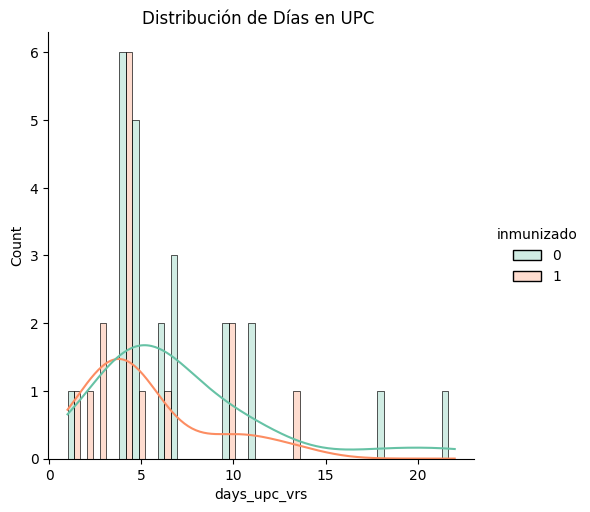

In [39]:
# Crear un gráfico con histograma y KDE
sns.displot(df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            kind="hist",# Usa 'hist' para el histograma
            multiple='dodge',
            kde=True,     # Agrega la curva KDE
            fill=True,    # Rellena el área bajo la curva KDE
            bins=30,
            palette='Set2',# Número de bins en el histograma
            alpha=0.3)    # Transparencia del histograma

plt.title("Distribución de Días en UPC ")
plt.show()

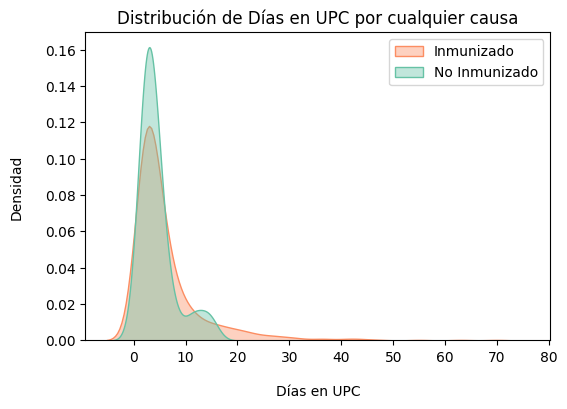

In [418]:
fig, ax2 = plt.subplots(figsize=(6, 4))

sns.kdeplot(data=df[(df['days_upc'] > 0)& (df['VRS']==0)], 
            x="days_upc", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Normalización kde
            fill=True,
            #bw_adjust=0.3, #smmoother
            alpha=0.4,  
            ax=ax2)  


ax2.set_xlabel("Días en UPC", labelpad=15)  
ax2.set_ylabel("Densidad", labelpad=15)  


plt.title("Distribución de Días en UPC por cualquier causa")

ax2.legend(title="", labels=["Inmunizado", "No Inmunizado"])

#ax2.set_xlim(0, None)

plt.show()

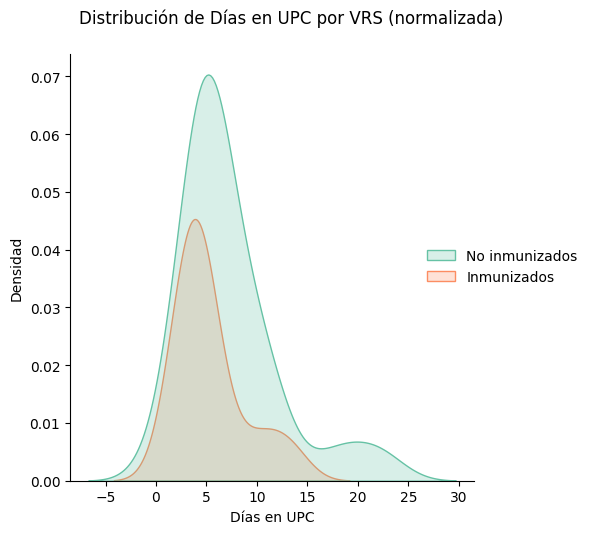

In [419]:
g = sns.displot(df[df['days_upc_vrs']>0], x="days_upc_vrs", hue="inmunizado", kind="kde",palette="Set2",  fill=True)
# Cambiar los nombres de los ejes

#g.set(xlim=(0, None))
g.set_axis_labels("Días en UPC", "Densidad")

# Cambiar el título del gráfico
g.set_titles("Distribución de Días en UPC por VRS")

# Cambiar el título de la leyenda
g._legend.set_title("")

# Cambiar los nombres de las leyendas
new_labels = ['No inmunizados', 'Inmunizados']  # Asegúrate que coincidan con los valores en 'inmunizado'
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# Mostrar el gráfico
g.figure.suptitle("Distribución de Días en UPC por VRS (normalizada)", y=1.06)  # Para ajustar el título un poco hacia arriba
plt.show()

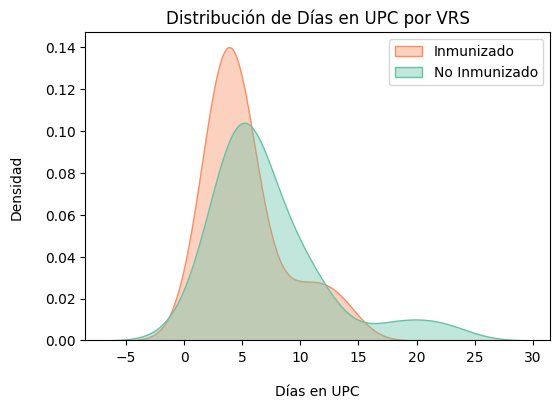

In [420]:
# Crear la figura y el eje
fig, ax2 = plt.subplots(figsize=(6, 4))

# Graficar las curvas kde
sns.kdeplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax2.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días en UPC por VRS")

# Cambiar el título de la leyenda
ax2.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
#ax2.set_xlim(0, None)

# Mostrar el gráfico
plt.show()


In [40]:
print("promedio días upc inmunes: ",df[(df['days_upc_vrs']>0) & (df['inmunizado']==1)]['days_upc_vrs'].mean())
print("promedio días upc no inmunes: ",df[(df['days_upc_vrs']>0) & (df['inmunizado']==0)]['days_upc_vrs'].mean())

promedio días upc inmunes:  5.133333333333334
promedio días upc no inmunes:  7.173913043478261


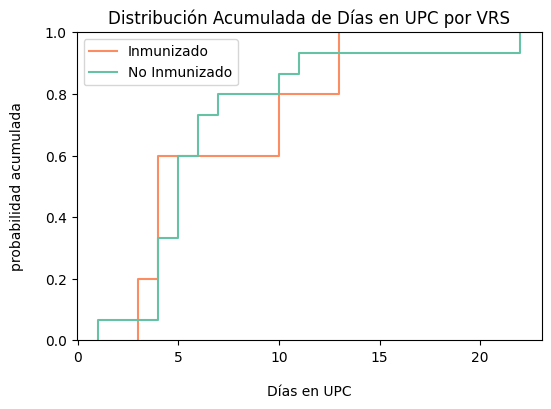

In [858]:
# Crear la figura y el eje
fig, ax3 = plt.subplots(figsize=(6, 4))

# Graficar las curvas de distribución acumulada (ECDF)
sns.ecdfplot(data=df[df['days_upc_vrs'] > 0], 
             x="days_upc_vrs", 
             hue="inmunizado",  
             palette="Set2", 
             ax=ax3)  # Usar el eje para el ECDF

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax3.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax3.set_ylabel("probabilidad acumulada", labelpad=15)  # Ajustar distancia del label del eje y (ECDF)

# Añadir un título
plt.title("Distribución Acumulada de Días en UPC por VRS")

# Cambiar el título de la leyenda
ax3.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
#ax3.set_xlim(0, None)

# Mostrar el gráfico
plt.show()

In [803]:

inmunizado = df[(df['inmunizado'] == 1) & (df['days_upc_vrs']>0)]['days_upc_vrs']
no_inmunizado = df[(df['inmunizado'] == 0) & (df['days_upc_vrs']>0)]['days_upc_vrs']

ks_stat, p_value = ks_2samp(inmunizado, no_inmunizado)

print(f"Distancia KS: {ks_stat}")
print(f"Valor p: {p_value}")

Distancia KS: 0.33201581027667987
Valor p: 0.31240327082602815


In [762]:
# Calcular la prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(inmunizado, no_inmunizado)

# Mostrar los resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

Estadístico t: 0.0805
Valor p: 0.9367
No existe una diferencia significativa entre las medias de los dos grupos.


In [763]:
# Filtrar los datos para obtener las dos muestras
inmunizado = df[(df['inmunizado'] == 1) & (df['days_upc_vrs']>0)]['days_upc_vrs']
no_inmunizado = df[(df['inmunizado'] == 0) & (df['days_upc_vrs']>0)]['days_upc_vrs']

# Ajustar las funciones ECDF para cada grupo
ecdf_inmunizado = ECDF(inmunizado)
ecdf_no_inmunizado = ECDF(no_inmunizado)

# Crear una cuadrícula de valores únicos en la columna 'days_upc_vrs'
grid_days = np.sort(df['days_upc_vrs'].unique())

# Calcular las probabilidades acumuladas en la cuadrícula para cada ECDF
prob_acumulada_inmunizado = ecdf_inmunizado(grid_days)
prob_acumulada_no_inmunizado = ecdf_no_inmunizado(grid_days)

# Calcular la distancia de Kolmogorov-Smirnov
abs_dif = np.abs(prob_acumulada_inmunizado - prob_acumulada_no_inmunizado)
distancia_ks = np.max(abs_dif)

# Mostrar el resultado
print(f"Distancia Kolmogorov-Smirnov: {distancia_ks :.4f}")

resultado_ks = ks_2samp(
    inmunizado,
    no_inmunizado
)

# Mostrar el resultado
print(f"Estadístico de Kolmogorov-Smirnov: {resultado_ks.statistic:.4f}")
print(f"P-valor: {resultado_ks.pvalue:.4f}")

Distancia Kolmogorov-Smirnov: 0.2667
Estadístico de Kolmogorov-Smirnov: 0.2667
P-valor: 0.9340


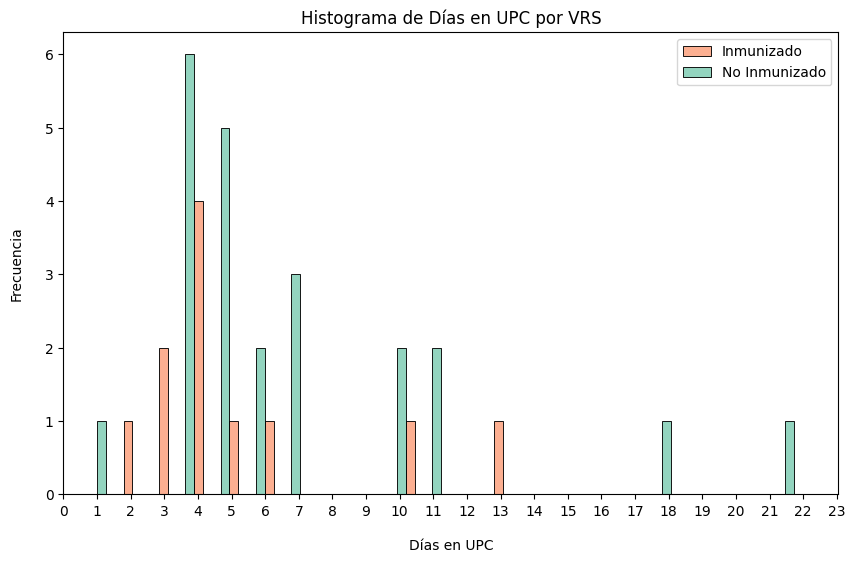

In [804]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 6))

# Graficar el histograma
sns.histplot(df[df['days_upc_vrs'] > 0], 
             x="days_upc_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Frecuencia", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Histograma de Días en UPC por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.grid(True, which='major', axis='x', linestyle='')

ax1.yaxis.set_major_locator(MultipleLocator(1))
# Mostrar el gráfico
plt.show()

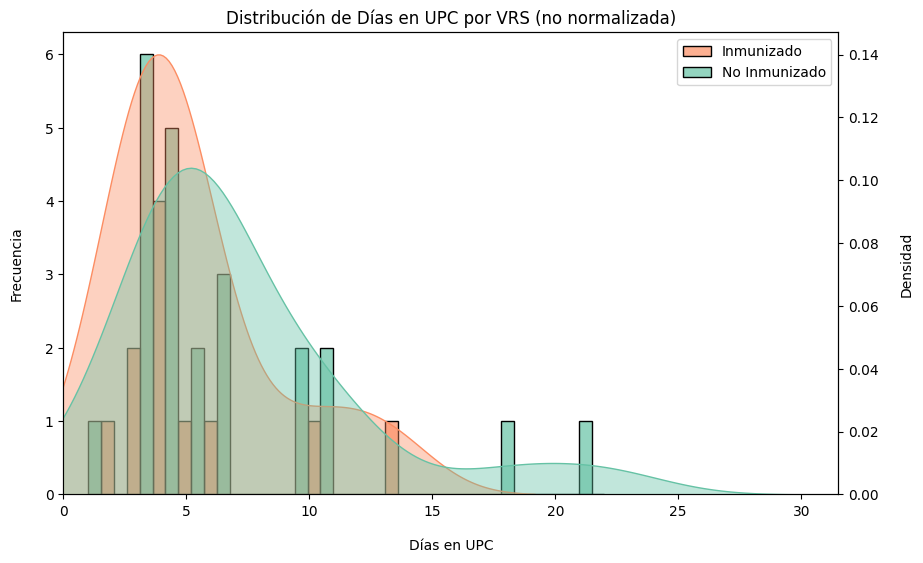

In [805]:

fig, ax1 = plt.subplots(figsize=(10, 6))

# Graficar el histograma en ax1
sns.histplot(df[df['days_upc_vrs'] > 0], 
             x="days_upc_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=20,  # Número de bins en el histograma
             ax=ax1)  # Usar el primer eje para el histograma

# Crear el segundo eje para la densidad (KDE)
ax2 = ax1.twinx()

# Graficar las curvas kde en ax2
sns.kdeplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Frecuencia", labelpad=15)  # Ajustar distancia del label del eje y (histograma)
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días en UPC por VRS (no normalizada)")

# Mostrar solo una leyenda
ax2.get_legend().remove()  # Eliminar la leyenda de ax2

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

# Mostrar el gráfico
plt.show()


C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\2592004921.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['days_upc_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\2592004921.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df[df['days_upc_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\2592004921.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


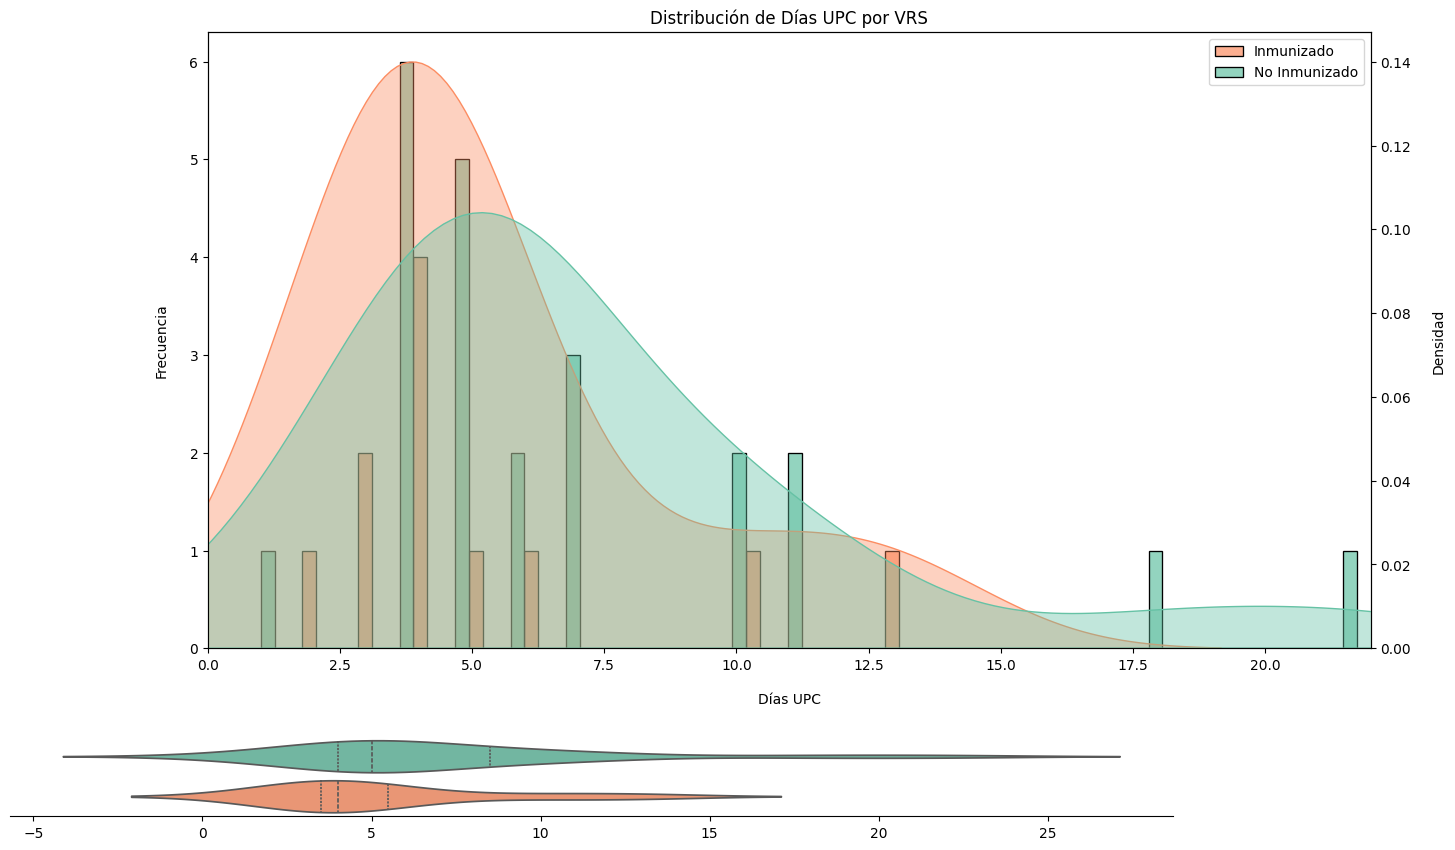

In [428]:
fig, ax1 = plt.subplots(figsize=(15, 8)) 

# Graficar el histograma en ax1
sns.histplot(df[df['days_upc_vrs'] > 0], 
             x="days_upc_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             ax=ax1)  # Usar el primer eje para el histograma

# Crear el segundo eje para la densidad (KDE)
ax2 = ax1.twinx()

# Graficar las curvas kde en ax2
sns.kdeplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Frecuencia", labelpad=15)  # Ajustar distancia del label del eje y (histograma)
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días UPC por VRS")

# Mostrar solo una leyenda
ax2.get_legend().remove()  # Eliminar la leyenda de ax2

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)


#ax1.xaxis.set_major_locator(MultipleLocator(1))
#ax1.grid(True, which='major', axis='x', linestyle='')
# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([-0.007, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

# Graficar los boxplots en ax3
sns.violinplot(data=df[df['days_upc_vrs'] > 0], 
               x="days_upc_vrs", 
               y="inmunizado", 
               palette="Set2", 
               ax=ax3, 
               orient="h", 
               inner="quartile",  # Muestra los cuartiles dentro del violin
               scale="width") 

# Alinear los ejes x de ambos gráficos
min_value = 0  # Valor mínimo del eje x para el histograma y kde
max_value = df['days_upc_vrs'].max()  # Valor máximo del eje x según los datos

# Ajustar los límites del eje x del histograma y kde
ax1.set_xlim(min_value, max_value)
ax2.set_xlim(min_value, max_value)

# Ajustar los límites del eje x del violinplot para que no esté truncado
#ax3.set_xlim(ax1.get_xlim()) 
# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

C:\Users\ntrig\AppData\Local\Temp\ipykernel_4460\3046694965.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['days_upc_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_4460\3046694965.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


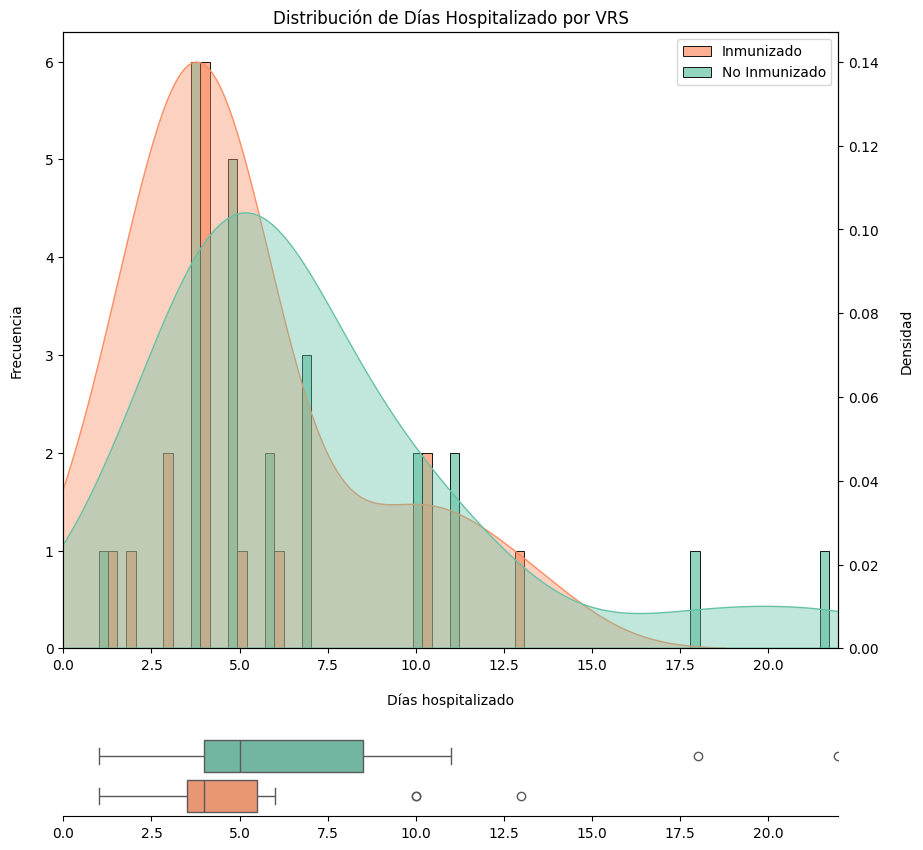

In [41]:
fig, ax1 = plt.subplots(figsize=(10, 8)) 


# Graficar el histograma en ax1
sns.histplot(df[df['days_upc_vrs'] > 0], 
             x="days_upc_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             ax=ax1)  # Usar el primer eje para el histograma

# Crear el segundo eje para la densidad (KDE)
ax2 = ax1.twinx()

# Graficar las curvas kde en ax2
sns.kdeplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Frecuencia", labelpad=15)  # Ajustar distancia del label del eje y (histograma)
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Mostrar solo una leyenda
ax2.get_legend().remove()  # Eliminar la leyenda de ax2

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)


#ax1.xaxis.set_major_locator(MultipleLocator(1))
#ax1.grid(True, which='major', axis='x', linestyle='')
# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_upc_vrs'].max()  # Valor máximo del eje x según los datos

ax1.set_xlim(min_value, max_value)
ax3.set_xlim(min_value, max_value)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

In [42]:
df[(df['days_upc_vrs']>0) & (df['inmunizado']==1)]['days_upc_vrs'].mean(), df[(df['days_upc_vrs']>0) & (df['inmunizado']==0)]['days_upc_vrs'].mean()

(5.133333333333334, 7.173913043478261)

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\1092242627.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['days_upc_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\1092242627.py:85: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


23.0


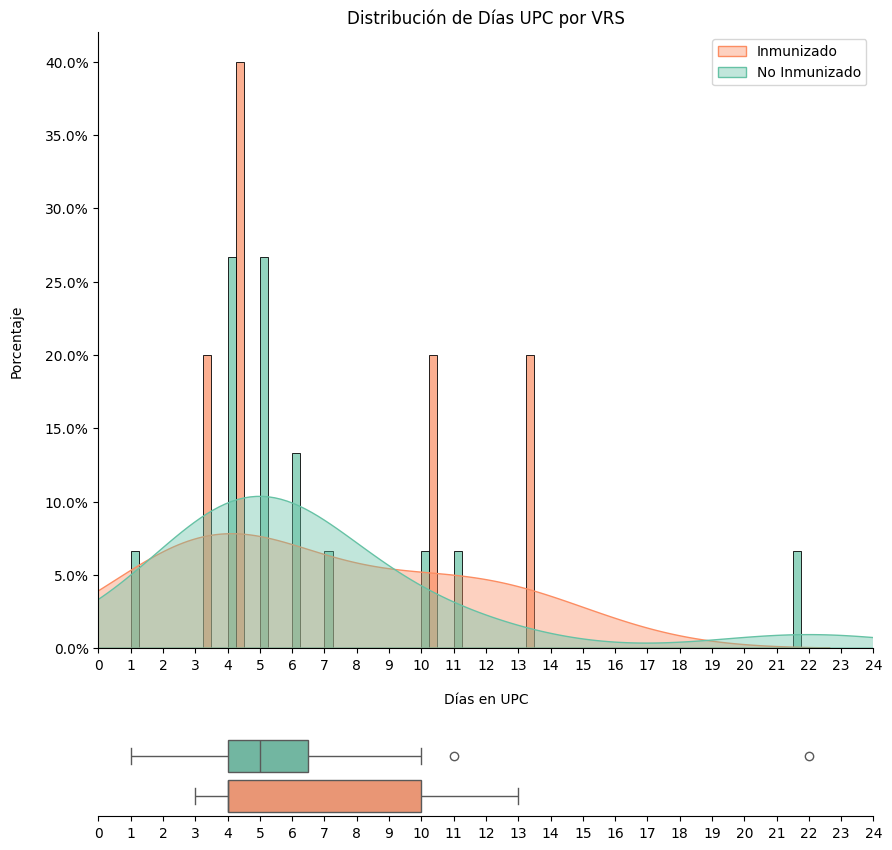

In [859]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

# Graficar el histograma en ax1
sns.histplot(df[df['days_upc_vrs'] > 0], 
             x="days_upc_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             common_norm=False,
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en porcentajes
             binwidth=0.5,
             #shrink=0.8, 
             ax=ax1)  # Usar el primer eje para el histograma

sns.kdeplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax1)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días en UPC", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días UPC por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_upc_vrs'] > 0], 
            x="days_upc_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            #showmeans=True, 
            #meanline=True,
            orient="h")

#ax3.lines[5].set_color('black')  # Cambiar el color de la línea de la media
#ax3.lines[5].set_linestyle('--')  # Cambiar el estilo de la línea de la media

#ax3.lines[12].set_color('black')  # Cambiar el color de la línea de la media
#ax3.lines[12].set_linestyle('--')  # Cambiar el estilo de la línea de la media

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

## Días hospitalización

In [432]:
inmunes = df['days_estad_vrs'][(df['inmunizado']==1) & (df['days_estad_vrs']>0)]
no_inmunes = df['days_estad_vrs'][(df['inmunizado']==0) & (df['days_estad_vrs']>0)]

# Calcular la prueba t de Student para muestras independientes
t_stat, p_value = stats.ttest_ind(inmunes, no_inmunes)

# Mostrar los resultados
print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

# Interpretación
if p_value < 0.05:
    print("Existe una diferencia significativa entre las medias de los dos grupos.")
else:
    print("No existe una diferencia significativa entre las medias de los dos grupos.")

Estadístico t: -3.3580
Valor p: 0.0009
Existe una diferencia significativa entre las medias de los dos grupos.


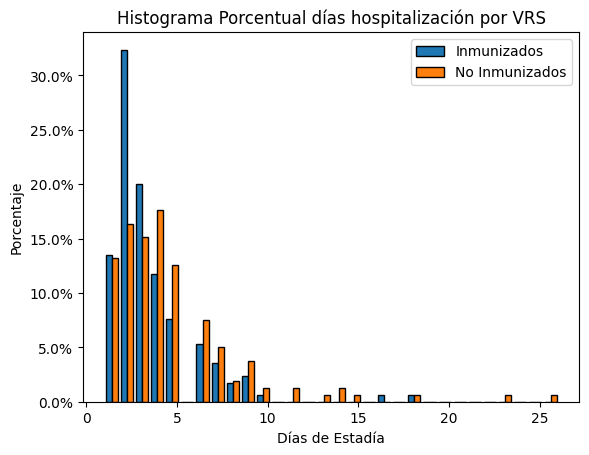

In [433]:
# Total porcentual
inmunes = df['DIAS_ESTAD'][(df['inmunizado']==1) & (df['VRS']==1)
                         & (df['DIAS_ESTAD']>0)]
no_inmunes = df['DIAS_ESTAD'][(df['inmunizado']==0) & (df['VRS']==1)
                            & (df['DIAS_ESTAD']>0)]
# Crear el histograma de frecuencia relativa
plt.hist([inmunes, no_inmunes], 
         bins=30 ,#range(int(min(df['DIAS_ESTAD'].fillna(0))), int(max(df['DIAS_ESTAD'].fillna(0)) + 2)), 
         weights=[np.ones_like(inmunes) / len(inmunes), 
                  np.ones_like(no_inmunes) / len(no_inmunes)], 
         edgecolor='black', 
         label=['Inmunizados', 'No Inmunizados'], 
         density=False)

# Ajustar el eje y para que muestre porcentajes
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

# Añadir títulos y etiquetas
plt.title('Histograma Porcentual días hospitalización por VRS')
plt.xlabel('Días de Estadía')
plt.ylabel('Porcentaje')
plt.legend()

# Mostrar el gráfico
plt.show()

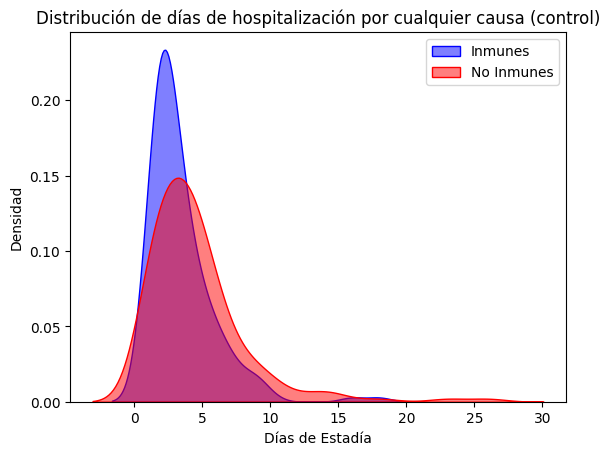

In [434]:
sns.kdeplot(inmunes, label='Inmunes', fill=True, color='blue', alpha=0.5)
sns.kdeplot(no_inmunes, label='No Inmunes', fill=True, color='red', alpha=0.5)

# Añadir títulos y etiquetas
plt.title('Distribución de días de hospitalización por cualquier causa (control)')
plt.xlabel('Días de Estadía')
plt.ylabel('Densidad')
plt.legend()

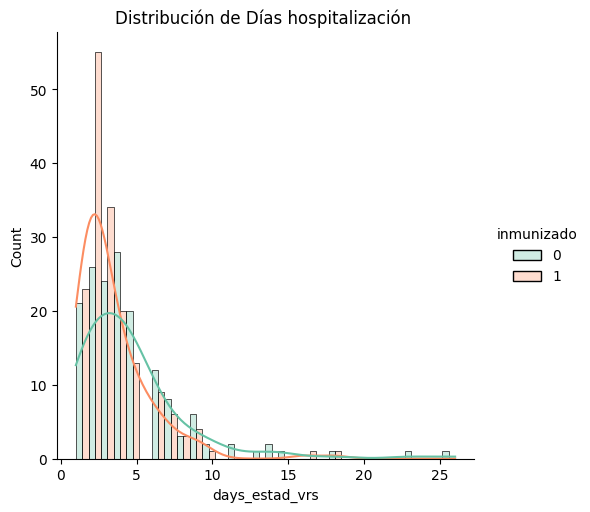

In [435]:
# Crear un gráfico con histograma y KDE
sns.displot(df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            kind="hist",# Usa 'hist' para el histograma
            multiple='dodge',
            kde=True,     # Agrega la curva KDE
            fill=True,    # Rellena el área bajo la curva KDE
            bins=30,
            palette='Set2',# Número de bins en el histograma
            alpha=0.3)    # Transparencia del histograma

plt.title("Distribución de Días hospitalización ")
plt.show()

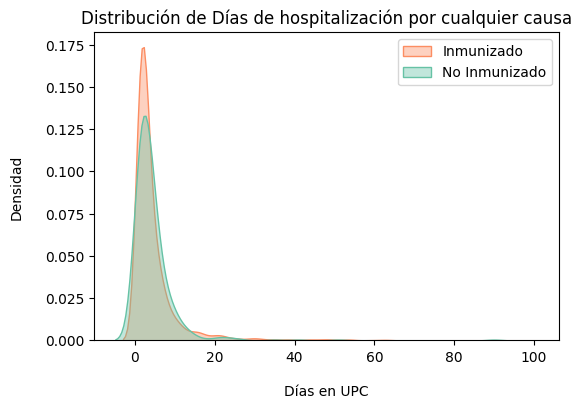

In [436]:
fig, ax2 = plt.subplots(figsize=(6, 4))

sns.kdeplot(data=df[(df['DIAS_ESTAD'] > 0)& (df['VRS']==0)], 
            x="DIAS_ESTAD", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Normalización kde
            fill=True,
            alpha=0.4,  
            ax=ax2)  


ax2.set_xlabel("Días en UPC", labelpad=15)  
ax2.set_ylabel("Densidad", labelpad=15)  


plt.title("Distribución de Días de hospitalización por cualquier causa")

ax2.legend(title="", labels=["Inmunizado", "No Inmunizado"])

#ax2.set_xlim(0, None)

plt.show()

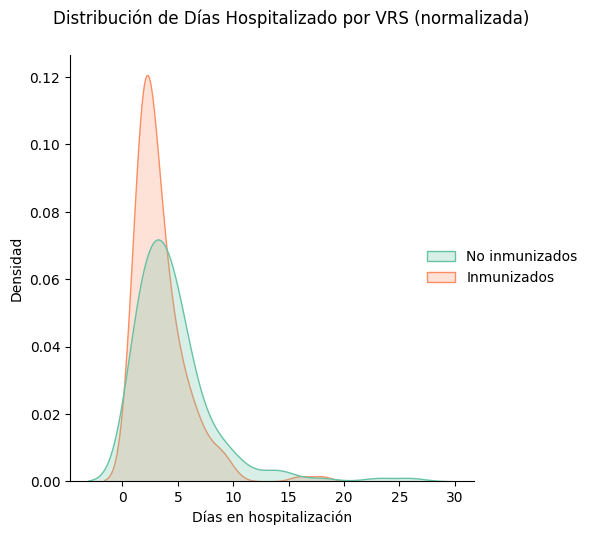

In [437]:
g = sns.displot(df[df['days_estad_vrs']>0], x="days_estad_vrs", hue="inmunizado", kind="kde",palette="Set2",  fill=True)
# Cambiar los nombres de los ejes

#g.set(xlim=(0, None))
g.set_axis_labels("Días en hospitalización", "Densidad")

# Cambiar el título del gráfico
g.set_titles("Distribución de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
g._legend.set_title("")

# Cambiar los nombres de las leyendas
new_labels = ['No inmunizados', 'Inmunizados']  # Asegúrate que coincidan con los valores en 'inmunizado'
for t, l in zip(g._legend.texts, new_labels): t.set_text(l)

# Mostrar el gráfico
g.figure.suptitle("Distribución de Días Hospitalizado por VRS (normalizada)", y=1.06)  # Para ajustar el título un poco hacia arriba
plt.show()

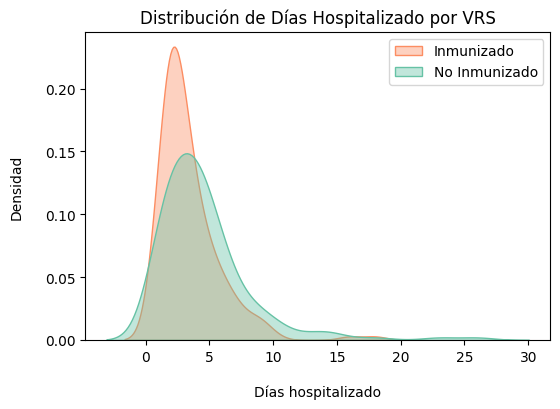

In [438]:
# Crear la figura y el eje
fig, ax2 = plt.subplots(figsize=(6, 4))

# Graficar las curvas kde
sns.kdeplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax2.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
ax2.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
#ax2.set_xlim(0, None)

# Mostrar el gráfico
plt.show()


In [439]:
# Filtrar los datos para obtener las dos muestras
inmunizado = df[(df['inmunizado'] == 1) & (df['days_estad_vrs']>0)]['days_estad_vrs']
no_inmunizado = df[(df['inmunizado'] == 0) & (df['days_estad_vrs']>0)]['days_estad_vrs']

# Calcular la distancia KS y el valor p
ks_stat, p_value = ks_2samp(inmunizado, no_inmunizado)

# Mostrar los resultados
print("Promedio de días hospitlaizado inmune: ", inmunizado.mean())
print("Promedio de días hospitlaizado no inmune: ", no_inmunizado.mean(),"\n")

print(f"Distancia KS: {ks_stat}")
print(f"Valor p: {p_value}")

Promedio de días hospitlaizado inmune:  3.411764705882353
Promedio de días hospitlaizado no inmune:  4.578616352201258 

Distancia KS: 0.21228264890862006
Valor p: 0.000972185834853928


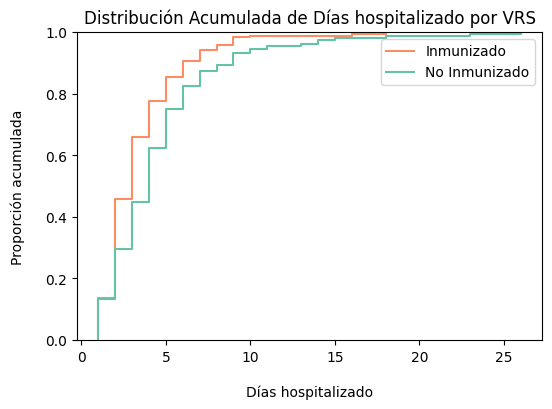

In [440]:
# Crear la figura y el eje
fig, ax3 = plt.subplots(figsize=(6, 4))

# Graficar las curvas de distribución acumulada (ECDF)
sns.ecdfplot(data=df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             palette="Set2", 
             ax=ax3)  # Usar el eje para el ECDF

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax3.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax3.set_ylabel("Proporción acumulada", labelpad=15)  # Ajustar distancia del label del eje y (ECDF)

# Añadir un título
plt.title("Distribución Acumulada de Días hospitalizado por VRS")

# Cambiar el título de la leyenda
ax3.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
#ax3.set_xlim(0, None)

# Mostrar el gráfico
plt.show()

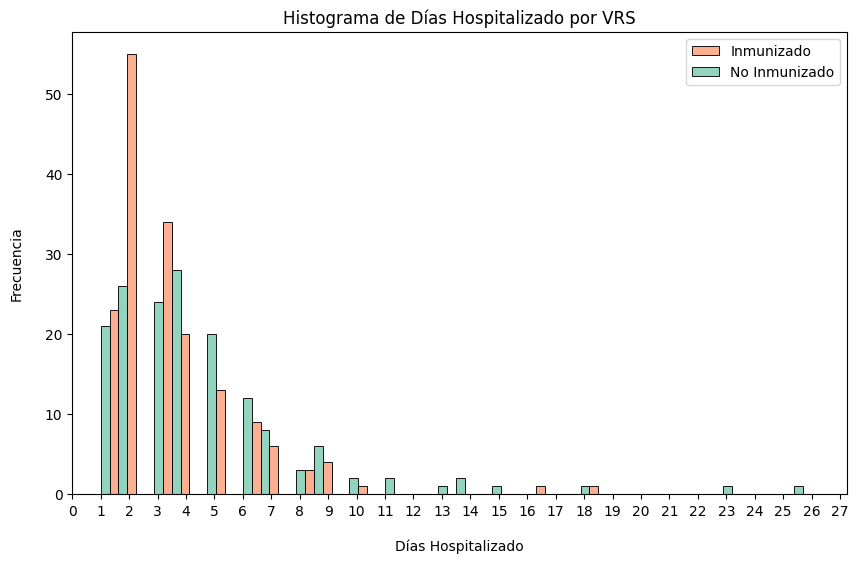

In [441]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 6))

# Graficar el histograma
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días Hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Frecuencia", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Histograma de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))
ax1.grid(True, which='major', axis='x', linestyle='')


# Mostrar el gráfico
plt.show()

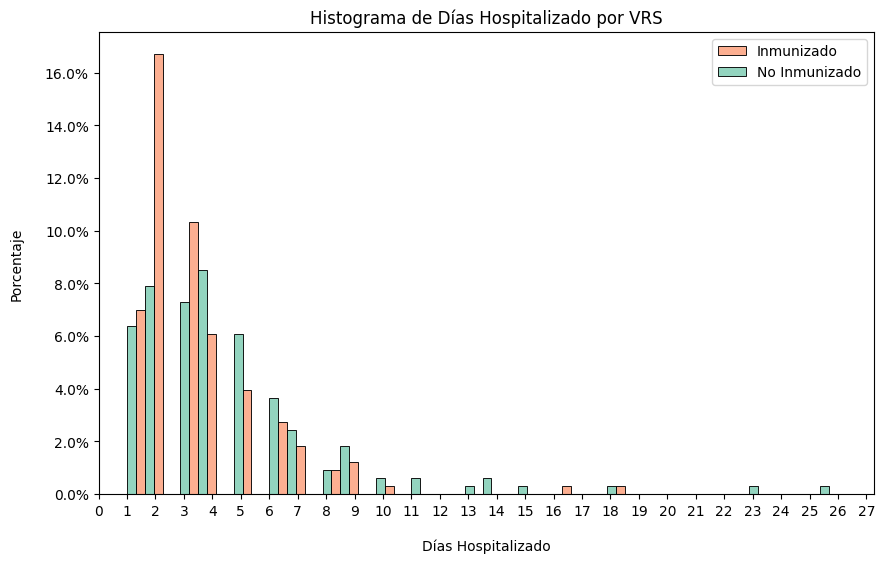

In [442]:
from matplotlib.ticker import MultipleLocator

# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 6))

# Graficar el histograma con porcentajes normalizados dentro de cada grupo
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en probabilidades (porcentajes)
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días Hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Histograma de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Mostrar el gráfico
plt.show()

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\1079748400.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['days_estad_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\1079748400.py:50: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=df[df['days_estad_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\1079748400.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


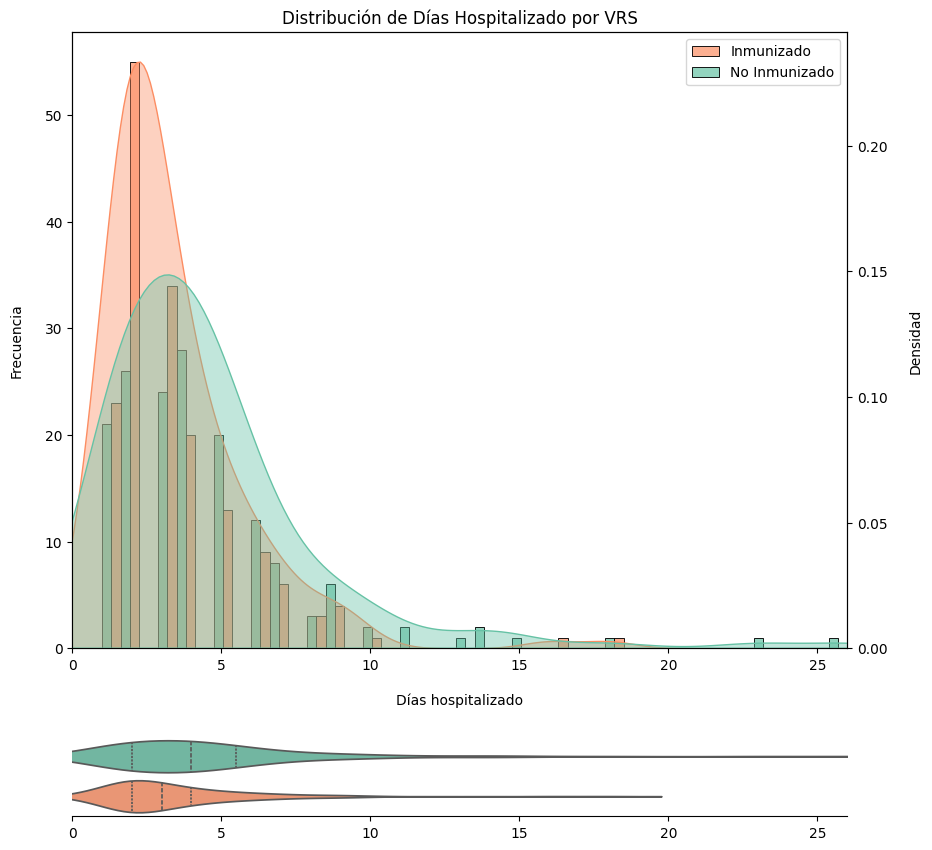

In [443]:

fig, ax1 = plt.subplots(figsize=(10, 8)) 

# Graficar el histograma en ax1
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             ax=ax1)  # Usar el primer eje para el histograma

# Crear el segundo eje para la densidad (KDE)
ax2 = ax1.twinx()

# Graficar las curvas kde en ax2
sns.kdeplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Frecuencia", labelpad=15)  # Ajustar distancia del label del eje y (histograma)
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Mostrar solo una leyenda
ax2.get_legend().remove()  # Eliminar la leyenda de ax2

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)


#ax1.xaxis.set_major_locator(MultipleLocator(1))
#ax1.grid(True, which='major', axis='x', linestyle='')
# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

# Graficar los boxplots en ax3
sns.violinplot(data=df[df['days_estad_vrs'] > 0], 
               x="days_estad_vrs", 
               y="inmunizado", 
               palette="Set2", 
               ax=ax3, 
               orient="h", 
               inner="quartile",  # Muestra los cuartiles dentro del violin
               scale="width") 

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos

ax1.set_xlim(min_value, max_value)
ax3.set_xlim(min_value, max_value)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()


C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\837647504.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['days_estad_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\837647504.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


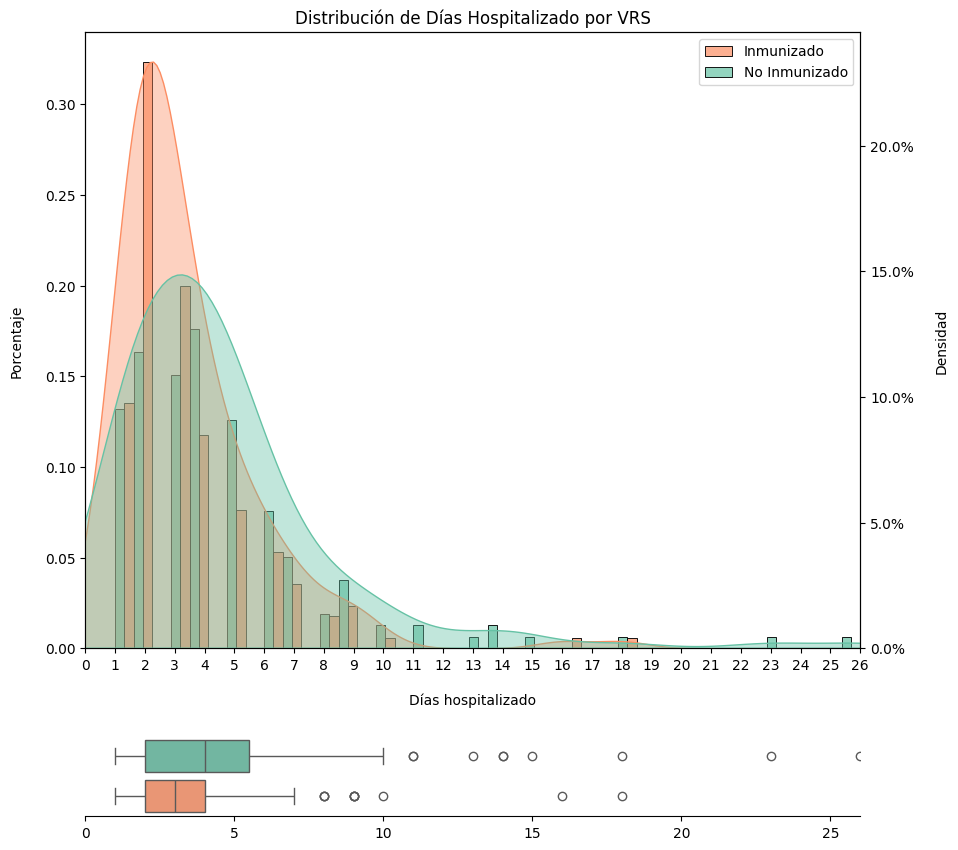

In [444]:
fig, ax1 = plt.subplots(figsize=(10, 8)) 

# Graficar el histograma en ax1
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             common_norm=False,
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en probabilidades (porcentajes)
             ax=ax1)  # Usar el primer eje para el histograma

# Crear el segundo eje para la densidad (KDE)
ax2 = ax1.twinx()

# Graficar las curvas kde en ax2
sns.kdeplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Mostrar solo una leyenda
ax2.get_legend().remove()  # Eliminar la leyenda de ax2


# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')



#ax1.xaxis.set_major_locator(MultipleLocator(1))
#ax1.grid(True, which='major', axis='x', linestyle='')
# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos

ax1.set_xlim(min_value, max_value)
ax3.set_xlim(min_value, max_value)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

In [846]:
df[(df['days_estad_vrs']>0) & (df['inmunizado']==1)]['days_estad_vrs'].mean(),df[(df['days_estad_vrs']>0) & (df['inmunizado']==0)]['days_estad_vrs'].mean()

(3.411764705882353, 4.578616352201258)

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\3335608964.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['days_estad_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\3335608964.py:78: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


26.0


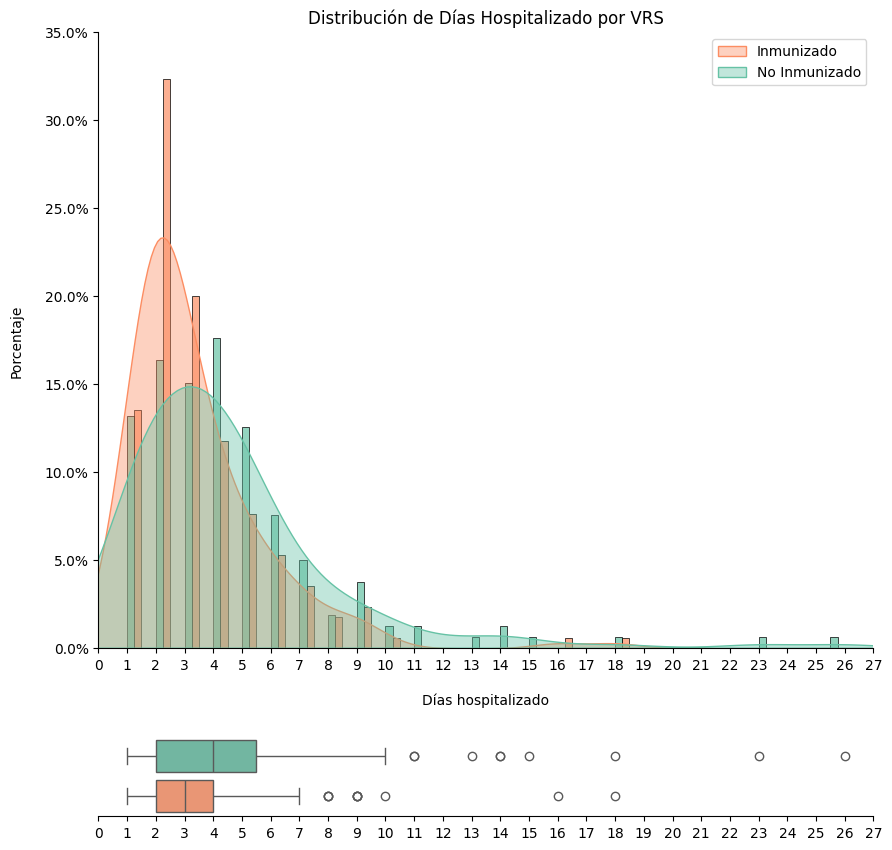

In [849]:
# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

# Graficar el histograma en ax1
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             common_norm=False,
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             stat="proportion",  # Convertir las frecuencias en porcentajes
             binwidth=0.5,
             #shrink=0.8, 
             ax=ax1)  # Usar el primer eje para el histograma

sns.kdeplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax1)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

ax1.xaxis.set_major_locator(MultipleLocator(1))

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
#ax1.spines['right'].set_visible(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
#ax3.spines['left'].set_visible(False)


ax1.yaxis.tick_left()



# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

ax3.xaxis.set_major_locator(MultipleLocator(1))

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos
print(max_value)
ax1.set_xlim(min_value, max_value+1)
ax1.set_ylim(0, 0.35)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

In [198]:
df[df['days_upc_vrs'] > 0]


KeyError: 'days_upc_vrs'

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\4110065161.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['days_estad_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\4110065161.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


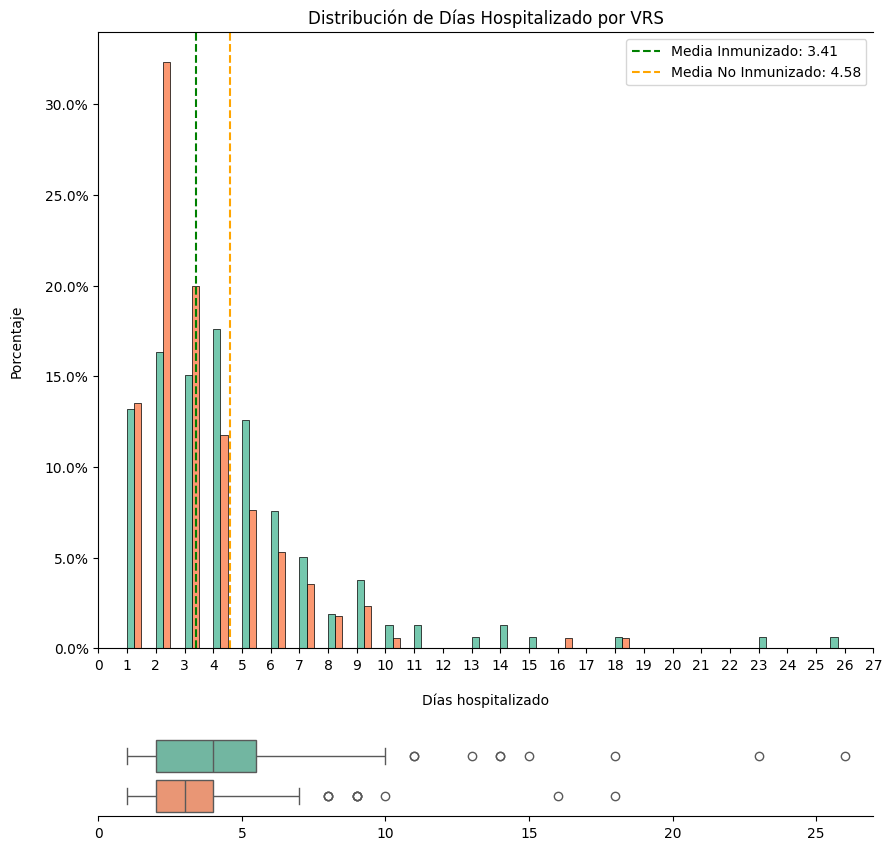

In [447]:
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick

# Crear la figura y el eje
fig, ax1 = plt.subplots(figsize=(10, 8))

# Graficar el histograma en ax1
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             common_norm=False,
             alpha=0.9,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             binwidth=0.5,  # Ajustar el ancho de las barras
             stat="proportion",  # Convertir las frecuencias en porcentajes
             ax=ax1)  # Usar el primer eje para el histograma

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Porcentaje", labelpad=15)  # Ajustar distancia del label del eje y (histograma)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Crear una leyenda separada para las medias, debajo de la original
#legend1 = ax1.legend(title="", loc='upper right', bbox_to_anchor=(1, 1))  # Leyenda para inmunizado/no inmunizado
#ax1.add_artist(legend1)  # Añadir la primera leyenda al gráfico

#ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)

# Ajustar la ubicación de las etiquetas en el eje x para que coincidan con las barras
ax1.xaxis.set_major_locator(MultipleLocator(1))

# Convertir el eje y a formato de porcentaje
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax1.grid(True, which='major', axis='x', linestyle='')

# Eliminar el eje vertical derecho (eliminación del segundo eje)
ax1.spines['right'].set_visible(False)
ax1.yaxis.tick_left()

# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Calcular la media de cada grupo
# Calcular la media de cada grupo
mean_inmunizado = df[(df['days_estad_vrs'] > 0) & (df['inmunizado'] == 1)]['days_estad_vrs'].mean()
mean_no_inmunizado = df[(df['days_estad_vrs'] > 0) & (df['inmunizado'] == 0)]['days_estad_vrs'].mean()

# Añadir líneas punteadas para las medias
linea_media_inmunizado = ax1.axvline(mean_inmunizado, color='green', linestyle='--', linewidth=1.5)
linea_media_no_inmunizado = ax1.axvline(mean_no_inmunizado, color='orange', linestyle='--', linewidth=1.5)



# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos

ax1.set_xlim(min_value, max_value+1)
ax3.set_xlim(min_value, max_value+1)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar ambas leyendas en ax1
handles, labels = ax1.get_legend_handles_labels()
handles.append(linea_media_inmunizado)
handles.append(linea_media_no_inmunizado)
labels.append(f'Media Inmunizado: {mean_inmunizado:.2f}')
labels.append(f'Media No Inmunizado: {mean_no_inmunizado:.2f}')

ax1.legend(handles=handles, labels=labels, title="", loc='upper right', bbox_to_anchor=(1, 1))


# Mostrar el gráfico
plt.show()

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\2471939049.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['days_estad_vrs'] > 0],
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\2471939049.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])


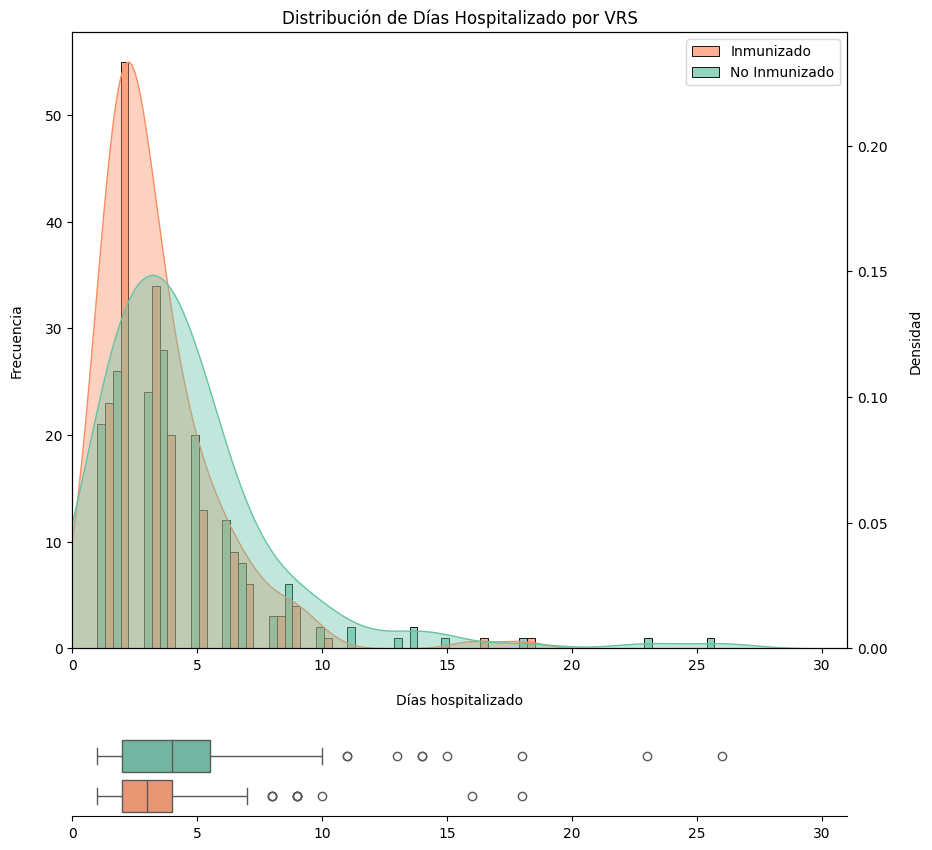

In [448]:
fig, ax1 = plt.subplots(figsize=(10, 8)) 

# Graficar el histograma en ax1
sns.histplot(df[df['days_estad_vrs'] > 0], 
             x="days_estad_vrs", 
             hue="inmunizado", 
             multiple="dodge",  # Barras una al lado de la otra
             palette="Set2", 
             alpha=0.7,  # Transparencia del histograma
             bins=40,  # Número de bins en el histograma
             ax=ax1)  # Usar el primer eje para el histograma

# Crear el segundo eje para la densidad (KDE)
ax2 = ax1.twinx()

# Graficar las curvas kde en ax2
sns.kdeplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            hue="inmunizado", 
            palette="Set2", 
            common_norm=False,  # Para que las curvas no se normalicen juntas
            fill=True,
            alpha=0.4,  # Transparencia de las curvas
            ax=ax2)  # Usar el segundo eje para la densidad

# Cambiar los nombres de los ejes con un labelpad para ajustar la distancia
ax1.set_xlabel("Días hospitalizado", labelpad=15)  # Ajustar distancia del label del eje x
ax1.set_ylabel("Frecuencia", labelpad=15)  # Ajustar distancia del label del eje y (histograma)
ax2.set_ylabel("Densidad", labelpad=15)  # Ajustar distancia del label del eje y (kde)

# Añadir un título
plt.title("Distribución de Días Hospitalizado por VRS")

# Mostrar solo una leyenda
ax2.get_legend().remove()  # Eliminar la leyenda de ax2

# Cambiar el título de la leyenda
ax1.legend(title="", labels=["Inmunizado", "No Inmunizado"])

# Ajustar los límites del eje x
ax1.set_xlim(0, None)


#ax1.xaxis.set_major_locator(MultipleLocator(1))
#ax1.grid(True, which='major', axis='x', linestyle='')
# Crear un nuevo eje para los boxplots
ax3 = fig.add_axes([0.125, -0.1, 0.775, 0.1])  # [left, bottom, width, height]

# Graficar los boxplots en ax3
sns.boxplot(data=df[df['days_estad_vrs'] > 0], 
            x="days_estad_vrs", 
            y="inmunizado", 
            palette="Set2", 
            ax=ax3, 
            orient="h")

# Ajustar los límites del eje x para que coincidan en todos los gráficos
min_value = 0  # Valor mínimo del eje x (ajústalo si es necesario)
max_value = df['days_estad_vrs'].max()  # Valor máximo del eje x según los datos

ax1.set_xlim(min_value, max_value+5)
ax3.set_xlim(min_value, max_value+5)

# Ajustar el eje y para que coincida con los colores de la leyenda
ax3.set_yticklabels(["Inmunizado", "No Inmunizado"])

# Ocultar los labels del eje x de ax3 para que no se dupliquen
ax3.set_xlabel("")

# Quitar el eje y de ax3
ax3.yaxis.set_visible(False)

# Ajustar la visibilidad de las líneas de los ejes
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Mostrar el gráfico
plt.show()

## otros graficos

In [57]:
df[df['FECHA_INMUNIZACION']==df['FECHA_INMUNIZACION'].min()]['RUN']

61554    a3fc16a9f9903d0ddb0b89d5c91584beeb947924f4862b...
Name: RUN, dtype: object

In [114]:
weeks = [start_date + pd.DateOffset(weeks=i) for i in range(18)]
df['week_inm'] = df['FECHA_INMUNIZACION'].dt.isocalendar().week
#df.groupby(['group', 'week_inm']).agg({'RUN': 'count'}).groupby(['group']).cumsum().unstack(0)
df.groupby(['group', 'week_inm']).agg({'RUN': 'count'}).unstack(0).cumsum()


RUN         
group    CATCH_UP SEASONAL
week_inm                  
9             1.0      NaN
13          142.0      NaN
14         9304.0   2136.0
15        20940.0   4684.0
16        30132.0   7219.0
17        39170.0   9837.0
18        44696.0  12419.0
19        50865.0  14889.0
20        56550.0  17342.0
21        60435.0  19825.0
22        64366.0  22350.0
23        66723.0  24875.0
24        68088.0  27512.0
25        69117.0  29909.0
26        69974.0  32429.0
27        70626.0  34915.0
28        71149.0  37530.0
29        71460.0  40077.0
30        71749.0  42547.0
31        71919.0  45104.0
32        72061.0  47520.0
33        72154.0  49342.0
34        72178.0  49435.0

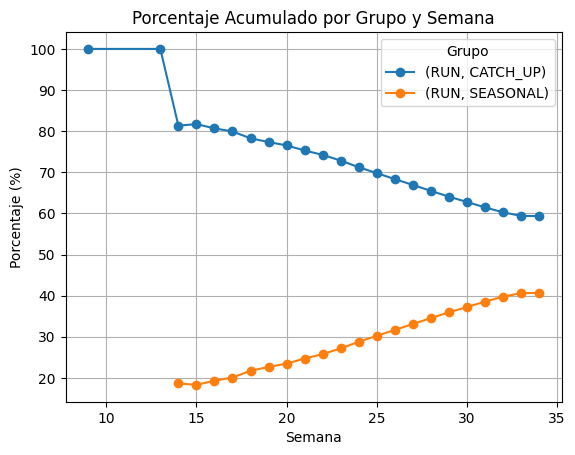

In [115]:
# Agrupar, contar, desagrupar y obtener la suma acumulada
grouped_df = df.groupby(['group', 'week_inm']).agg({'RUN': 'count'}).unstack(0).cumsum()

# Calcular el porcentaje para cada semana
percent_df = grouped_df.div(grouped_df.sum(axis=1), axis=0) * 100

# Graficar
percent_df.plot(kind='line', marker='o')

plt.title('Porcentaje Acumulado por Grupo y Semana')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Semana')
plt.legend(title='Grupo')
plt.grid(True)
plt.show()

In [118]:
df[(df['group'] == 'SEASONAL') & (df['FECHA_NAC'] < pd.to_datetime('2024-04-01') + pd.DateOffset(weeks=1))].shape[0]

2889

In [119]:
df[(df['FECHA_INMUNIZACION'] >= pd.to_datetime('2024-04-01')) & (df['FECHA_INMUNIZACION'] < pd.to_datetime('2024-04-01') + pd.DateOffset(weeks=1)) & (df['group'] == 'SEASONAL') & (df['FECHA_NAC'] < pd.to_datetime('2024-04-01') + pd.DateOffset(weeks=1))].shape[0]

2136

In [120]:
2136/2889

0.7393561786085151

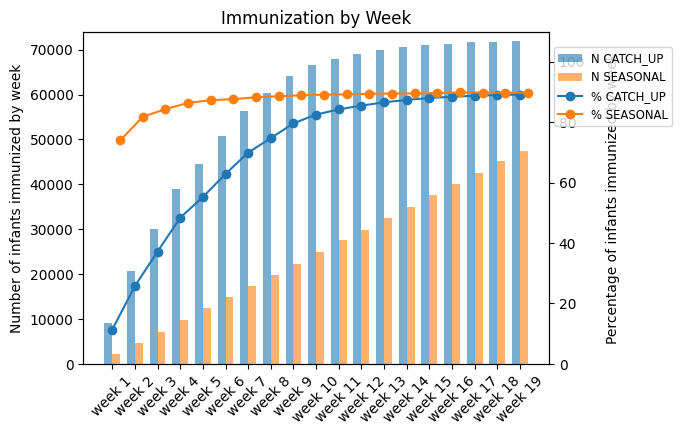

In [111]:
start_date = pd.to_datetime('2024-04-01')

weeks = [start_date + pd.DateOffset(weeks=i) for i in range(20)]
#df['week_inm'] = df['FECHA_INMUNIZACION'].dt.isocalendar().week
#df.groupby(['group', 'week_inm']).agg({'RUN': 'count'})

num_infants_per_week = {group: [] for group in df['group'].unique()}
pct_infants_per_week = {group: [] for group in df['group'].unique()}

for group in df['group'].unique():
    
    cumsum=0
    
    for i in range(len(weeks)-1):
        week_start = weeks[i]
        week_end = weeks[i+1]
    
        # Infantes inmunizados durante la semana para cada grupo
        infants_immunized = df[(df['group'] == group) & (df['FECHA_INMUNIZACION'] >= week_start) & (df['FECHA_INMUNIZACION'] < week_end)].shape[0]
        cumsum += infants_immunized
        num_infants_per_week[group].append(cumsum)
        
        infants_total = df[(df['group'] == group) & (df['FECHA_NAC'] < week_end)].shape[0] #N total per group
        
        # porcentaje
        if infants_total > 0:
            pct_infants_per_week[group].append((cumsum / infants_total) * 100)
        else:
            pct_infants_per_week[group].append(0)

# Crear DataFrame para el gráfico
weeks_str = [f"week {i}" for i in range(1, len(weeks))]
results_df = pd.DataFrame(weeks_str, columns=['weeks'])

for group in df['group'].unique():
    results_df[f'number_of_infants_{group}'] = num_infants_per_week[group]
    results_df[f'percentage_of_infants_{group}'] = pct_infants_per_week[group]

# Crear el gráfico
fig, ax1 = plt.subplots()

# Eje x
x = range(len(weeks_str))

# Eje y para el número de infantes
ax1.set_ylabel('Number of infants immunized by week', color='black')

# Plotear las barras agrupadas
bar_width = 0.35
for i, group in enumerate(df['group'].unique()):
    ax1.bar([pos + i * bar_width for pos in x], results_df[f'number_of_infants_{group}'], width=bar_width, alpha=0.6, label=f'N {group}')

# Ajustar límites del eje y para el número de infantes
ax1.set_ylim(0, max([max(values) for values in num_infants_per_week.values()]) + 2000)

# Eje y para el porcentaje de infantes
ax2 = ax1.twinx()
ax2.set_ylabel('Percentage of infants immunized by week', color='black', labelpad=15)
for i, group in enumerate(df['group'].unique()):
    ax2.plot([pos + i * bar_width + bar_width/2 for pos in x], results_df[f'percentage_of_infants_{group}'], marker='o', label=f'% {group}')

# Ajustar límites del eje y para el porcentaje
ax2.set_ylim(0, max([max(values) for values in pct_infants_per_week.values()]) + 20)

# Ajustar leyenda y etiquetas
ax1.set_xticks([pos + (len(df['group'].unique()) - 1) * bar_width / 2 for pos in x])
ax1.set_xticklabels(weeks_str, rotation=45)

# Combinar las leyendas
handles, labels = [], []
for handle, label in zip(*ax1.get_legend_handles_labels()):
    handles.append(handle)
    labels.append(label)
for handle, label in zip(*ax2.get_legend_handles_labels()):
    handles.append(handle)
    labels.append(label)

# Ajustar leyenda combinada
fig.tight_layout()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(0.864, 0.83), ncol=1, fontsize='small')

# Ajustar el espacio para las leyendas
fig.subplots_adjust(top=0.85)

# Mostrar el gráfico
plt.title('Immunization by Week')
plt.show()

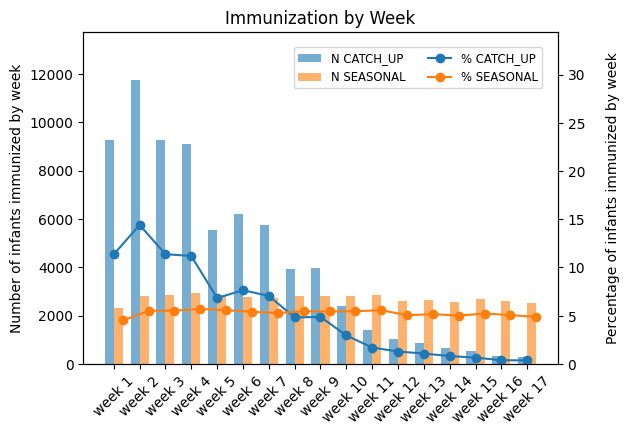

In [ ]:
start_date = pd.to_datetime('2024-04-01')



weeks = [start_date + pd.DateOffset(weeks=i) for i in range(18)]
#df['week_inm'] = df['FECHA_INMUNIZACION'].dt.isocalendar().week

num_infants_per_week = {group: [] for group in df['group'].unique()}
pct_infants_per_week = {group: [] for group in df['group'].unique()}

# Calcular el número y porcentaje de infantes inmunizados por semana
for i in range(len(weeks)-1):
    week_start = weeks[i]
    week_end = weeks[i+1]
    
    for group in df['group'].unique():
        # Infantes inmunizados durante la semana para cada grupo
        infants_immunized = df[(df['group'] == group) & (df['FECHA_INMUNIZACION'] >= week_start) & (df['FECHA_INMUNIZACION'] < week_end)].shape[0]
        num_infants_per_week[group].append(infants_immunized)
        
        infants_total = df[(df['group'] == group) & (df['FECHA_NAC'] < weeks[-1])].shape[0] #N total per group
        
        # porcentaje
        if infants_total > 0:
            pct_infants_per_week[group].append((infants_immunized / infants_total) * 100)
        else:
            pct_infants_per_week[group].append(0)

# Crear DataFrame para el gráfico
weeks_str = [f"week {i}" for i in range(1, len(weeks))]
results_df = pd.DataFrame(weeks_str, columns=['weeks'])

for group in df['group'].unique():
    results_df[f'number_of_infants_{group}'] = num_infants_per_week[group]
    results_df[f'percentage_of_infants_{group}'] = pct_infants_per_week[group]

# Crear el gráfico
fig, ax1 = plt.subplots()

# Eje x
x = range(len(weeks_str))

# Eje y para el número de infantes
ax1.set_ylabel('Number of infants immunized by week', color='black')

# Plotear las barras agrupadas
bar_width = 0.35
for i, group in enumerate(df['group'].unique()):
    ax1.bar([pos + i * bar_width for pos in x], results_df[f'number_of_infants_{group}'], width=bar_width, alpha=0.6, label=f'N {group}')

# Ajustar límites del eje y para el número de infantes
ax1.set_ylim(0, max([max(values) for values in num_infants_per_week.values()]) + 2000)

# Eje y para el porcentaje de infantes
ax2 = ax1.twinx()
ax2.set_ylabel('Percentage of infants immunized by week', color='black', labelpad=15)
for i, group in enumerate(df['group'].unique()):
    ax2.plot([pos + i * bar_width + bar_width/2 for pos in x], results_df[f'percentage_of_infants_{group}'], marker='o', label=f'% {group}')

# Ajustar límites del eje y para el porcentaje
ax2.set_ylim(0, max([max(values) for values in pct_infants_per_week.values()]) + 20)

# Ajustar leyenda y etiquetas
ax1.set_xticks([pos + (len(df['group'].unique()) - 1) * bar_width / 2 for pos in x])
ax1.set_xticklabels(weeks_str, rotation=45)

# Combinar las leyendas
handles, labels = [], []
for handle, label in zip(*ax1.get_legend_handles_labels()):
    handles.append(handle)
    labels.append(label)
for handle, label in zip(*ax2.get_legend_handles_labels()):
    handles.append(handle)
    labels.append(label)

# Ajustar leyenda combinada
fig.tight_layout()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.864, 0.83), ncol=2, fontsize='small')

# Ajustar el espacio para las leyendas
fig.subplots_adjust(top=0.85)

# Mostrar el gráfico
plt.title('Immunization by Week')
plt.show()

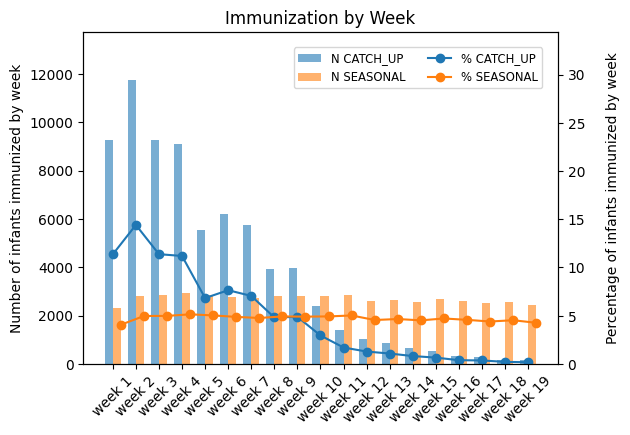

In [54]:

start_date = pd.to_datetime('2024-04-01')

weeks = [start_date + pd.DateOffset(weeks=i) for i in range(20)]
#df['week_inm'] = df['FECHA_INMUNIZACION'].dt.isocalendar().week

num_infants_per_week = {group: [] for group in df['group'].unique()}
pct_infants_per_week = {group: [] for group in df['group'].unique()}

# Calcular el número y porcentaje de infantes inmunizados por semana
for i in range(len(weeks)-1):
    week_start = weeks[i]
    week_end = weeks[i+1]
    
    for group in df['group'].unique():
        # Infantes inmunizados durante la semana para cada grupo
        infants_immunized = df[(df['group'] == group) & (df['FECHA_INMUNIZACION'] >= week_start) & (df['FECHA_INMUNIZACION'] < week_end)].shape[0]
        num_infants_per_week[group].append(infants_immunized)
        
        infants_total = df[(df['group'] == group) & (df['FECHA_NAC'] < weeks[-1])].shape[0] #N total per group
        
        # porcentaje
        if infants_total > 0:
            pct_infants_per_week[group].append((infants_immunized / infants_total) * 100)
        else:
            pct_infants_per_week[group].append(0)

# Crear DataFrame para el gráfico
weeks_str = [f"week {i}" for i in range(1, len(weeks))]
results_df = pd.DataFrame(weeks_str, columns=['weeks'])

for group in df['group'].unique():
    results_df[f'number_of_infants_{group}'] = num_infants_per_week[group]
    results_df[f'percentage_of_infants_{group}'] = pct_infants_per_week[group]

# Crear el gráfico
fig, ax1 = plt.subplots()

# Eje x
x = range(len(weeks_str))

# Eje y para el número de infantes
ax1.set_ylabel('Number of infants immunized by week', color='black')

# Plotear las barras agrupadas
bar_width = 0.35
for i, group in enumerate(df['group'].unique()):
    ax1.bar([pos + i * bar_width for pos in x], results_df[f'number_of_infants_{group}'], width=bar_width, alpha=0.6, label=f'N {group}')

# Ajustar límites del eje y para el número de infantes
ax1.set_ylim(0, max([max(values) for values in num_infants_per_week.values()]) + 2000)

# Eje y para el porcentaje de infantes
ax2 = ax1.twinx()
ax2.set_ylabel('Percentage of infants immunized by week', color='black', labelpad=15)
for i, group in enumerate(df['group'].unique()):
    ax2.plot([pos + i * bar_width + bar_width/2 for pos in x], results_df[f'percentage_of_infants_{group}'], marker='o', label=f'% {group}')

# Ajustar límites del eje y para el porcentaje
ax2.set_ylim(0, max([max(values) for values in pct_infants_per_week.values()]) + 20)

# Ajustar leyenda y etiquetas
ax1.set_xticks([pos + (len(df['group'].unique()) - 1) * bar_width / 2 for pos in x])
ax1.set_xticklabels(weeks_str, rotation=45)

# Combinar las leyendas
handles, labels = [], []
for handle, label in zip(*ax1.get_legend_handles_labels()):
    handles.append(handle)
    labels.append(label)
for handle, label in zip(*ax2.get_legend_handles_labels()):
    handles.append(handle)
    labels.append(label)

# Ajustar leyenda combinada
fig.tight_layout()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.864, 0.83), ncol=2, fontsize='small')

# Ajustar el espacio para las leyendas
fig.subplots_adjust(top=0.85)

# Mostrar el gráfico
plt.title('Immunization by Week')
plt.show()


In [450]:
df['week_inm'] = df['FECHA_INMUNIZACION'].dt.isocalendar().week
df.groupby('week_inm').count()


,RUN,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,...,dias_en_area_7,dias_en_area_8,dias_en_area_9,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,days_upc_vrs,days_estad_vrs,inmunizado
week_inm,,,,,,,,,,,,,,,,,,,,,
9,1,1,1,1,1,1,1,1,1,1,...,0,0,0,1,1,1,1,1,1,1
13,141,141,141,141,141,141,141,141,141,141,...,0,0,0,141,141,141,141,141,141,141
14,11299,11299,11299,11299,11299,11299,11299,11299,11299,11299,...,0,0,0,11299,11299,11299,11299,11299,11299,11299
15,14184,14184,14184,14184,14184,14184,14184,14184,14184,14184,...,0,0,0,14184,14184,14184,14184,14184,14184,14184
16,11727,11727,11727,11727,11727,11727,11727,11727,11727,11727,...,0,0,0,11727,11727,11727,11727,11727,11727,11727
17,11657,11657,11657,11657,11657,11657,11657,11657,11657,11657,...,0,0,0,11657,11657,11657,11657,11657,11657,11657
18,8110,8110,8110,8110,8110,8110,8110,8110,8110,8110,...,0,0,0,8110,8110,8110,8110,8110,8110,8110
19,8639,8639,8639,8639,8639,8639,8639,8639,8639,8639,...,1,0,0,8639,8639,8639,8639,8639,8639,8639
20,8143,8143,8143,8143,8143,8143,8143,8143,8143,8143,...,0,0,0,8143,8143,8143,8143,8143,8143,8143


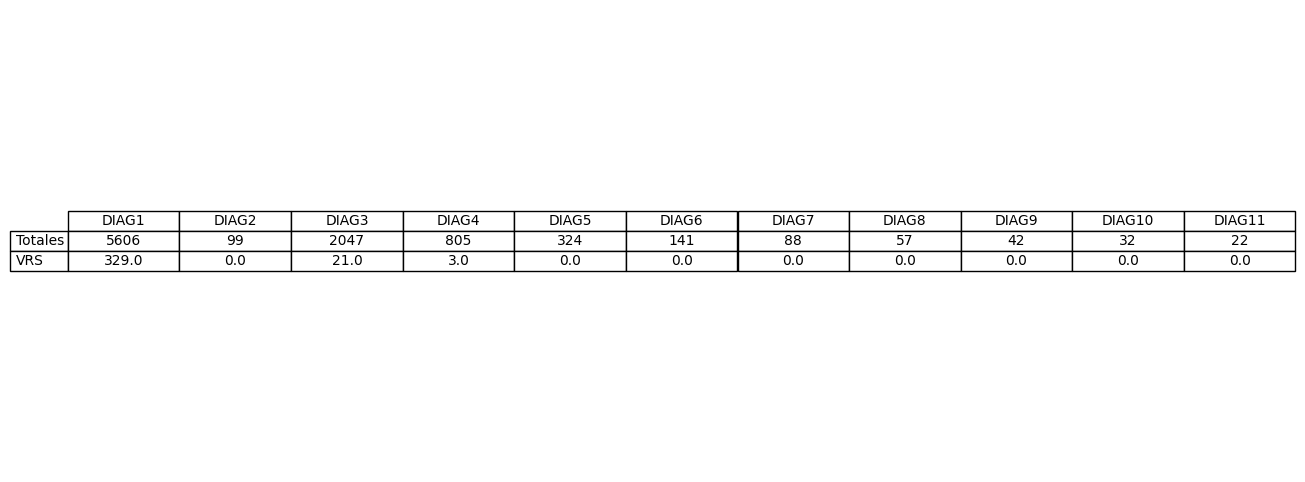

In [451]:
from pandas.plotting import table
# Definir las columnas de interés
columns_of_interest = ['DIAG1', 'DIAG2', 'DIAG3', 'DIAG4', 'DIAG5', 'DIAG6', 'DIAG7', 'DIAG8', 'DIAG9', 'DIAG10', 'DIAG11']

# Lista de valores a contar
values_list = diagnosticosVRS # Ajusta según los valores que te interesan

# Filtrar el DataFrame para solo las columnas de interés
df_filtered = df[columns_of_interest]

# Crear una tabla de frecuencias para N/A
frequency_table = pd.DataFrame(index=['Totales'], columns=df_filtered.columns)

# Contar N/A
for col in df_filtered.columns:
    na_count = df_filtered[col].notna().sum()
    frequency_table.loc['Totales', col] = na_count

# Crear una fila de conteo para los valores específicos en la lista
value_counts = pd.Series(index=df_filtered.columns, dtype=int)
for col in df_filtered.columns:
    value_count = df_filtered[col].isin(values_list).sum()
    value_counts[col] = value_count

# Añadir los conteos de los valores específicos a la tabla de frecuencias
frequency_table.loc['VRS'] = value_counts

# Crear una figura y un eje con matplotlib
fig, ax = plt.subplots(figsize=(12, 6))  # Ajusta el tamaño según sea necesario

# Ocultar el eje
ax.axis('off')

# Añadir la tabla al gráfico
table_plot = table(ax, frequency_table, loc='center', cellLoc='center', colWidths=[0.1]*len(frequency_table.columns))

# Ajustar el estilo de la tabla
table_plot.auto_set_font_size(False)
table_plot.set_fontsize(10)
table_plot.scale(1.2, 1.2)

# Guardar la tabla como una imagen
plt.savefig('tabla_frecuencias_conteo.png', bbox_inches='tight', dpi=300)
plt.show()

In [452]:
print("Hay ", df[df['RUN'].duplicated()].shape[0], "bebes con más de 1 egreso (duplicados en el data frame)")
print("Hay ",df[df['FECHA_INMUNIZACION'].notna()].shape[0], "bebes inmunizados")
print("Hay ",df[(df['FECHA_INMUNIZACION']>df['FECHA_ING']) & (df['VRS']==1)].shape[0], "bebes inmunizados post ingreso VRS") #76
print("Hay ",df[(df['FECHA_INMUNIZACION']>df['FECHA_EGR']) & (df['VRS']==1)].shape[0],"bebes inmunizados post egreso VRS") #69
print("Hay ",df[ (df['FECHA_INMUNIZACION']<df['FECHA_EGR']) & (df['FECHA_INMUNIZACION']>df['FECHA_ING']) & (df['VRS']==1)].shape[0], "bebes inmunizados durante estadía VRS") #3
print("Hay ",df[(df['FECHA_INMUNIZACION']==df['FECHA_EGR']) & (df['VRS']==1)].shape[0] , "bebes que se inmunizaron y egresaron el mismo día")
print("Hay ",df['event'].sum(),"casos de VRS") #149, cambia a 158 sumando Diag3

Hay  0 bebes con más de 1 egreso (duplicados en el data frame)
Hay  120856 bebes inmunizados
Hay  0 bebes inmunizados post ingreso VRS
Hay  0 bebes inmunizados post egreso VRS
Hay  0 bebes inmunizados durante estadía VRS
Hay  0 bebes que se inmunizaron y egresaron el mismo día
Hay  329 casos de VRS


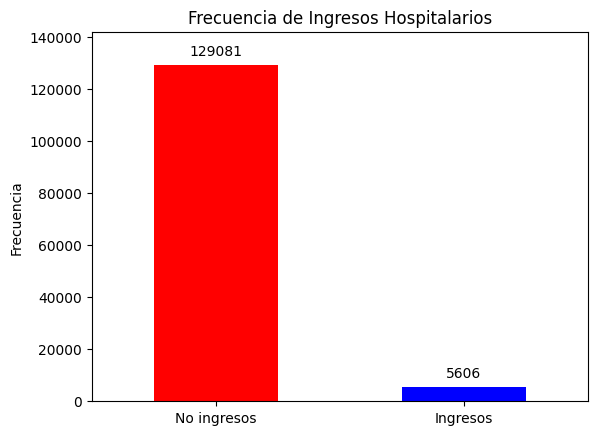

In [453]:
# Contar valores N/A y no N/A
na_ing = df['FECHA_EGR'].isna().sum()
not_na_ing = df['FECHA_EGR'].notna().sum()

# Crear una serie para el histograma
hist_data = pd.Series([na_ing, not_na_ing], index=['No ingresos', 'Ingresos'])

# Crear el histograma
ax = hist_data.plot(kind='bar', color=['red', 'blue'])

# Añadir los valores encima de cada barra
for i, value in enumerate(hist_data.values):
    plt.text(x=i, y=value + 0.02 * max(hist_data.values), s=value, ha='center', va='bottom', color='black')

# Añadir título y etiquetas
plt.title('Frecuencia de Ingresos Hospitalarios')
plt.xlabel('')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

# Ajustar el límite superior del eje y
plt.ylim(0, max(hist_data.values) + 0.1 * max(hist_data.values))  # Ajusta el +0.1 * max según sea necesario

# Mostrar el gráfico
plt.show()

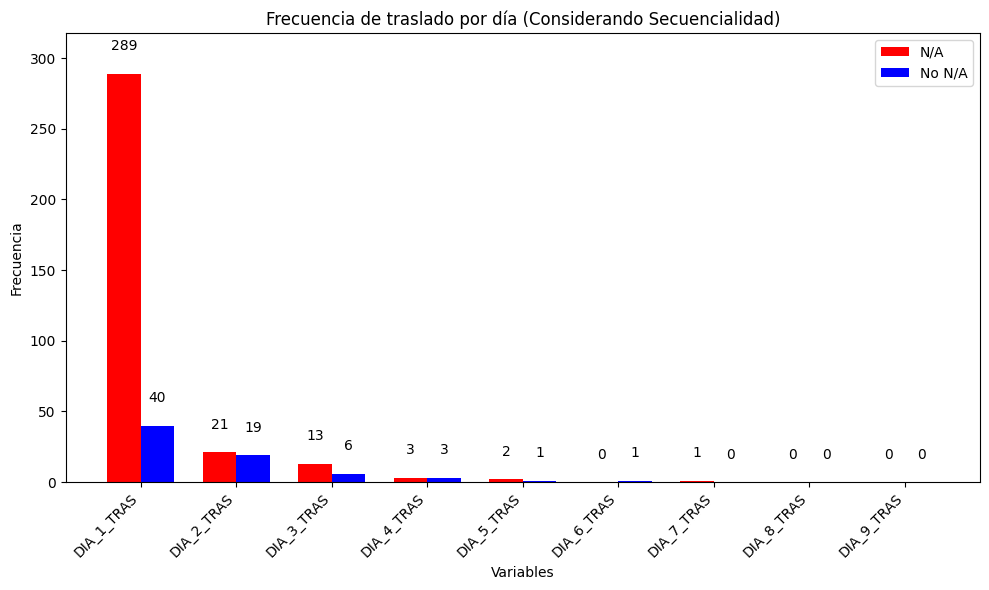

In [454]:
df_in = df[(df['FECHA_EGR'].notna()) & (df['VRS']==1)]

variables = ['DIA_1_TRAS', 'DIA_2_TRAS', 'DIA_3_TRAS', 'DIA_4_TRAS', 'DIA_5_TRAS', 
              'DIA_6_TRAS', 'DIA_7_TRAS', 'DIA_8_TRAS', 'DIA_9_TRAS']

na_counts = []
not_na_counts = []


for i, var in enumerate(variables):
    if i == 0:
        
        na_count = df_in[var].isna().sum()
        not_na_count = df_in[var].notna().sum()
    else:
        
        prev_var = variables[i - 1]
      
        na_count_current = df_in[var].isna().sum()
        
        na_count_prev = df_in[var].isna() & df_in[prev_var].isna()
        na_count_adjusted = na_count_current - na_count_prev.sum()
        
       
        not_na_count_prev = df_in[prev_var].notna().sum()
        not_na_count_current = df_in[var].notna().sum()
        not_na_count_adjusted = min(not_na_count_prev, not_na_count_current)
        
        na_count = na_count_adjusted
        not_na_count = not_na_count_adjusted

 
    na_counts.append(na_count)
    not_na_counts.append(not_na_count)


counts_df = pd.DataFrame({
    'Variable': variables,
    'N/A': na_counts,
    'No N/A': not_na_counts
})


fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35  
index = np.arange(len(variables))  # Posición barras

# barras
bars_na = ax.bar(index - bar_width/2, counts_df['N/A'], bar_width, label='N/A', color='red')
bars_not_na = ax.bar(index + bar_width/2, counts_df['No N/A'], bar_width, label='No N/A', color='blue')

for bar in bars_na:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05 * max(counts_df['N/A'].max(), counts_df['No N/A'].max()),
            f'{int(height)}', ha='center', va='bottom')

for bar in bars_not_na:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.05 * max(counts_df['N/A'].max(), counts_df['No N/A'].max()),
            f'{int(height)}', ha='center', va='bottom')

ax.set_xlabel('Variables')
ax.set_ylabel('Frecuencia')
ax.set_title('Frecuencia de traslado por día (Considerando Secuencialidad)')
ax.set_xticks(index)
ax.set_xticklabels(variables, rotation=45, ha='right')
ax.legend()

plt.ylim(0, max(counts_df['N/A'].max(), counts_df['No N/A'].max()) + 0.1 * max(counts_df['N/A'].max(), counts_df['No N/A'].max()))

# Mostrar el gráfico
plt.tight_layout()
plt.show()

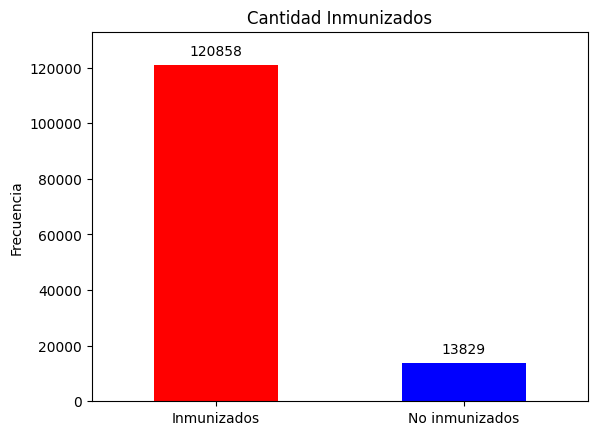

In [455]:
# Contar valores N/A y no N/A
#na_inm = df['FECHA_INMUNIZACION'].isna().sum()
#not_na_inm = df['FECHA_INMUNIZACION'].notna().sum()

na_inm = df['is_inm'].sum()
not_na_inm = df.shape[0]- na_inm 

# Crear una serie para el histograma
hist_data = pd.Series([na_inm, not_na_inm], index=['Inmunizados', 'No inmunizados'])

# Crear el histograma
ax = hist_data.plot(kind='bar', color=['red', 'blue'])

# Añadir los valores encima de cada barra
for i, value in enumerate(hist_data.values):
    plt.text(x=i, y=value + 0.02 * max(hist_data.values), s=value, ha='center', va='bottom', color='black')

# Añadir título y etiquetas
plt.title('Cantidad Inmunizados')
plt.xlabel('')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)

# Ajustar el límite superior del eje y
plt.ylim(0, max(hist_data.values) + 0.1 * max(hist_data.values))  # Ajusta el +0.1 * max según sea necesario

# Mostrar el gráfico
plt.show()

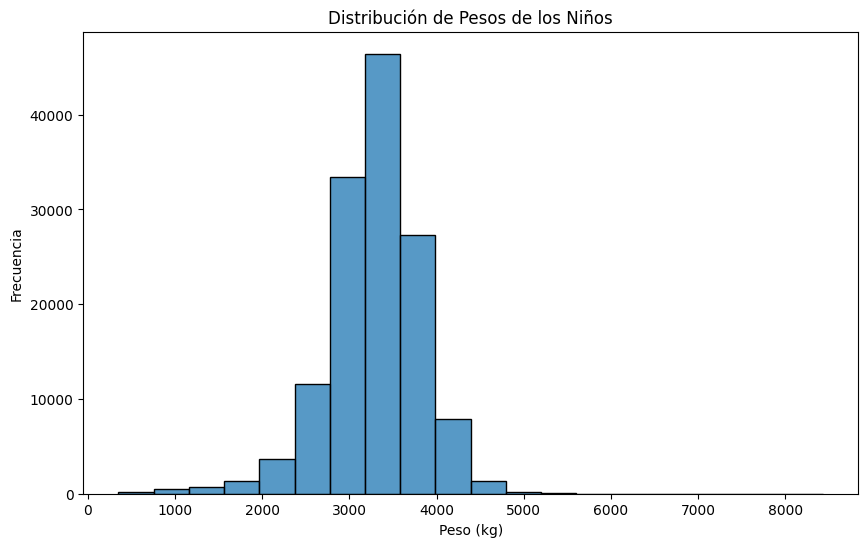

In [456]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PESO'].dropna(), bins=20)
plt.title('Distribución de Pesos de los Niños')
plt.xlabel('Peso (kg)')
plt.ylabel('Frecuencia')
plt.show()

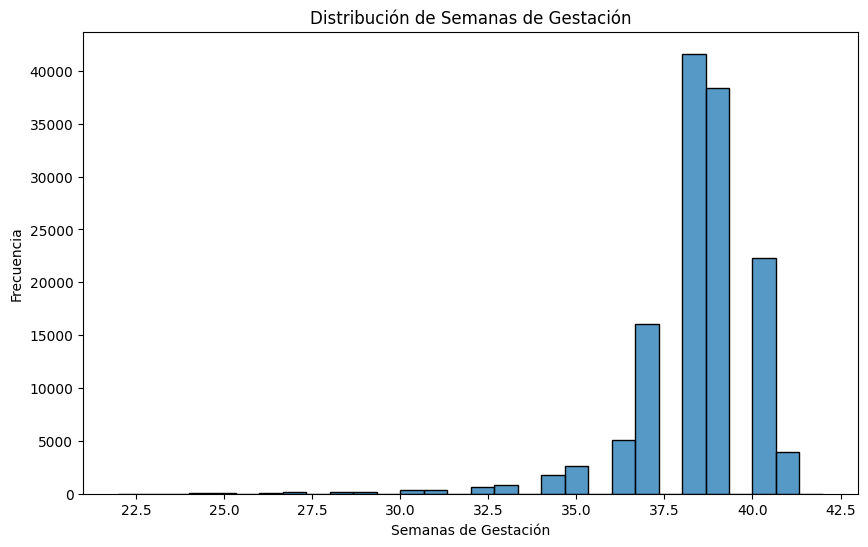

In [457]:
plt.figure(figsize=(10, 6))
sns.histplot(df['SEMANAS'].dropna(), bins=30)
plt.title('Distribución de Semanas de Gestación')
plt.xlabel('Semanas de Gestación')
plt.ylabel('Frecuencia')
plt.show()

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\2431815386.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


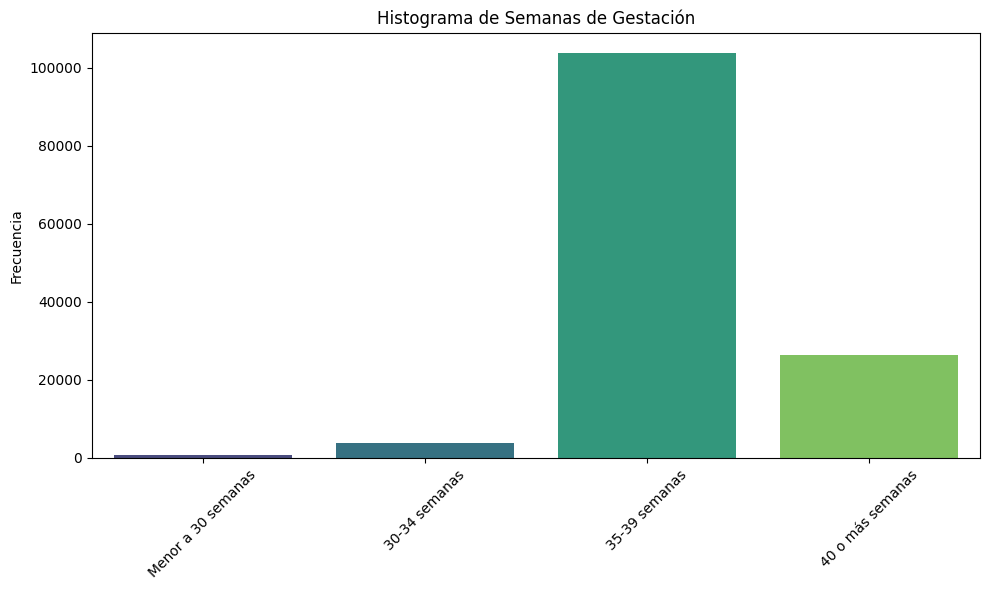

In [458]:
bins = [-float('inf'), 30, 35, 40, float('inf')]
labels = ['Menor a 30 semanas', '30-34 semanas', '35-39 semanas', '40 o más semanas']

df['Rango_SEMANAS'] = pd.cut(df['SEMANAS'], bins=bins, labels=labels, right=False)

counts = df['Rango_SEMANAS'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')

plt.title('Histograma de Semanas de Gestación')
plt.xlabel('')
plt.ylabel('Frecuencia')

plt.xticks(rotation=45)  # Rotar las etiquetas para mayor legibilidad
plt.tight_layout()
plt.show()

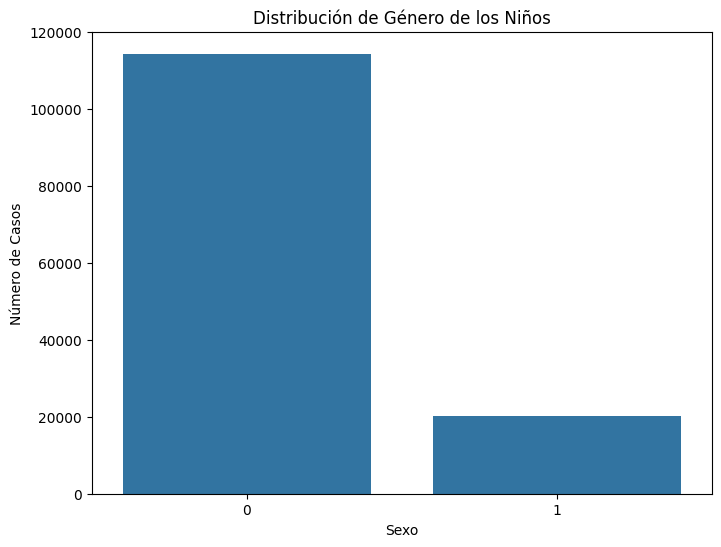

In [459]:
plt.figure(figsize=(8, 6))
sns.countplot(x='SEXO', data=df)
plt.title('Distribución de Género de los Niños')
plt.xlabel('Sexo')
plt.ylabel('Número de Casos')
plt.show()

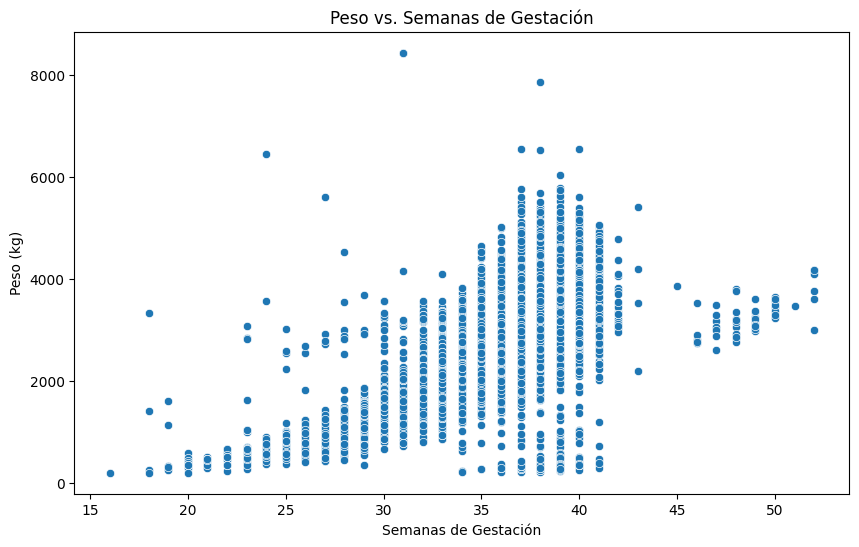

In [914]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SEMANAS', y='PESO', data=df)
plt.title('Peso vs. Semanas de Gestación')
plt.xlabel('Semanas de Gestación')
plt.ylabel('Peso (kg)')
plt.show()

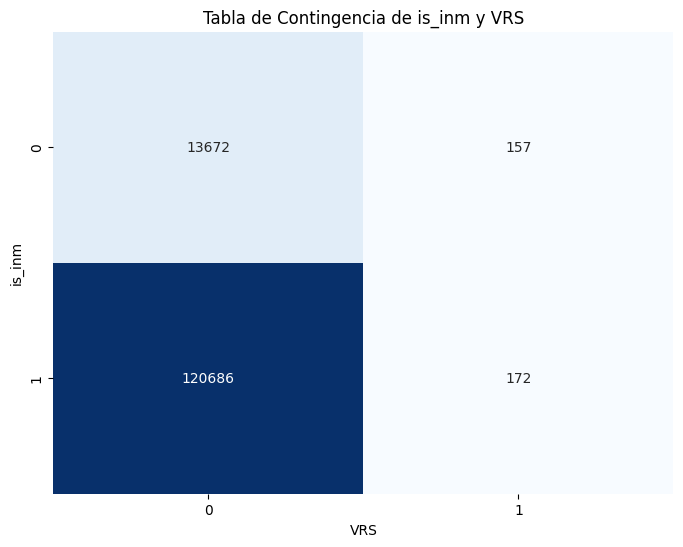

In [461]:
# Crear la tabla de contingencia
contingency_table = pd.crosstab(df['is_inm'], df['VRS'])

# Configurar el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues', cbar=False)

# Añadir título y etiquetas
plt.title('Tabla de Contingencia de is_inm y VRS')
plt.xlabel('VRS')
plt.ylabel('is_inm')

# Mostrar el gráfico
plt.show()

In [462]:
vrs_dupli = df[df['VRS'] == 1].duplicated().sum()

print(f"Total de filas duplicadas en filas donde 'VRS' es 1: {vrs_dupli}")

Total de filas duplicadas en filas donde 'VRS' es 1: 0


# FILTROOSSSS

In [142]:
df.shape[0]

140282

In [22]:
peso_critic = 300 #exclusive (no se incluyen los de 500gr en la nueva data)
semana_lower = 22 #inclusive
semana_upper = 42 #inclusive


descart1 = df[df['PESO']<=peso_critic].shape[0]
descart2 = df[df['SEMANAS']<semana_lower].shape[0]
descart3 = df[df['SEMANAS']>semana_upper].shape[0]
descart4 = df[(df['FECHA_ING'] < df['FECHA_NAC']) & (~df['FECHA_ING'].isna())].shape[0]

descart_tot = df[ (df['PESO']<=peso_critic) | (df['SEMANAS']<semana_lower) | (df['SEMANAS']>semana_upper) | ((df['FECHA_ING'] <= df['FECHA_NAC']) & (~df['FECHA_ING'].isna())) ].shape[0]
descart_tot_vrs = df[ ((df['PESO']<=peso_critic) | (df['SEMANAS']<semana_lower) | (df['SEMANAS']>semana_upper) | ((df['FECHA_ING'] <= df['FECHA_NAC']) & (~df['FECHA_ING'].isna()))) & (df['VRS']==1) ].shape[0]


print("menores a", peso_critic,"gr : ", descart1)
print("menor a ", semana_lower, "semanas : ", descart2)
print("mas de", semana_upper, "semanas : ", descart3)
print("nacimiento mayor a ingreso : ", descart4)
print("datos totales descartados: ", descart_tot, "y de los cuales ", descart_tot_vrs, "tienen VRS")

df1 = df[(df['PESO']>peso_critic) & (df['SEMANAS']>=semana_lower) & (df['SEMANAS']<=semana_upper)]

print("Recibieron nirse : ", df1['FECHA_INMUNIZACION'].notna().sum())

df_eliminar = df1[(df1.SEMANAS >= 35 ) & (df1.PESO <=500)]
df1=df1[~df1.RUN.isin(df_eliminar.RUN)]
print('Cantidad de datos con peso <=1000 y semanas >=35: ', len(df1[(df.SEMANAS >= 35 ) & (df.PESO <=500)]) , '\n')

print('Cantidad de datos con peso >=6000: ', len( df[(df.PESO >= 6000 )]) , '\n')
df_eliminar= df1[(df1.PESO>=1000) & ( df1.SEMANAS <=25)]
df1=df1[~df1.RUN.isin(df_eliminar.RUN)]

df1.loc[(df1['FECHA_INMUNIZACION'] >= df1['FECHA_ING']) & (df1.event ==1 ), 'FECHA_INMUNIZACION'] = pd.NaT
df1.loc[ (~df1['event']) & (~df1['FECHA_ING'].isna()), 'FECHA_ING'] = pd.NaT
df1.loc[((df1['FECHA_ING'] - df1['FECHA_INMUNIZACION']).dt.days <= 7) & (df1['event']) & (~df1.FECHA_INMUNIZACION.isna()), 'FECHA_INMUNIZACION'] = pd.NaT

df1_outIngNac = df1[(df1['FECHA_ING'] <= df1['FECHA_NAC']) & (~df1['FECHA_ING'].isna())] 

df1['inmunizado'] = 1 - df1['FECHA_INMUNIZACION'].isna()

df_filtrado=df1[~df1.RUN.isin(df1_outIngNac.RUN)]

print("Nuevo N de datos: ", df_filtrado.shape[0])


menores a 300 gr :  65
menor a  22 semanas :  42
mas de 42 semanas :  57
nacimiento mayor a ingreso :  6
datos totales descartados:  3816 y de los cuales  1 tienen VRS
Recibieron nirse :  131850


C:\Users\ntrig\AppData\Local\Temp\ipykernel_23092\166394002.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print('Cantidad de datos con peso <=1000 y semanas >=35: ', len(df1[(df.SEMANAS >= 35 ) & (df.PESO <=500)]) , '\n')


Cantidad de datos con peso <=1000 y semanas >=35:  0 

Cantidad de datos con peso >=6000:  9 

Nuevo N de datos:  146359


In [23]:
vrs = df_filtrado[df_filtrado.event == 1].drop_duplicates(subset=['RUN'], keep='first')
df_novrs = df_filtrado[~df_filtrado.RUN.isin(vrs.RUN.unique())].drop_duplicates(subset=['RUN'], keep='first')
df_filtrado = pd.concat([df_novrs,vrs])
df_filtrado

,RUN,FECHA_NACIMIENTO,MES_NAC,ANO_NAC,SEXO,SEMANAS,PESO,TALLA,EDAD_M,INS_C_M,INS_N_M,COMUNA,COMUNA_N,REG_RES,URBA_RURAL,NAC_MA,FECHA_INMUNIZACION,VACUNADO,FECHA_DEFUNCION,CAUSA_DEFUNCION,ESTAB,ServicioSalud,Seremi,EDAD_CANT,TIPO_EDAD,ETNIA,T_ETNIA,P_ORIGEN,COMUNA1,PREVI,FECHA_INGRESO,AREA_FUNC_I,SER_CLIN_I,DIA_1_TRAS,MES_1_TRAS,ANO_1_TRAS,AREAF_1_TRAS,SERC_1_TRAS,DIA_2_TRAS,MES_2_TRAS,ANO_2_TRAS,AREAF_2_TRAS,SERC_2_TRAS,DIA_3_TRAS,MES_3_TRAS,ANO_3_TRAS,AREAF_3_TRAS,SERC_3_TRAS,DIA_4_TRAS,MES_4_TRAS,ANO_4_TRAS,AREAF_4_TRAS,SERC_4_TRAS,DIA_5_TRAS,MES_5_TRAS,ANO_5_TRAS,AREAF_5_TRAS,SERC_5_TRAS,DIA_6_TRAS,MES_6_TRAS,ANO_6_TRAS,AREAF_6_TRAS,SERC_6_TRAS,DIA_7_TRAS,MES_7_TRAS,ANO_7_TRAS,AREAF_7_TRAS,SERC_7_TRAS,DIA_8_TRAS,MES_8_TRAS,ANO_8_TRAS,AREAF_8_TRAS,SERC_8_TRAS,DIA_9_TRAS,MES_9_TRAS,ANO_9_TRAS,AREAF_9_TRAS,SERC_9_TRAS,FECHA_EGRESO,AREAF_EGR,SERC_EGR,DIAS_ESTAD,COND_EGR,DIAG1,DIAG2,DIAG3,DIAG4,DIAG5,DIAG6,DIAG7,DIAG8,DIAG9,DIAG10,DIAG11,FECHA_NAC,FECHA_ING,FECHA_EGR,VRS,event,is_inm,group,vacunasAlDia,NOMBRE_REGION,Macrozona2,fecha_tras_1,fecha_tras_2,fecha_tras_3,fecha_tras_4,fecha_tras_5,fecha_tras_6,fecha_tras_7,fecha_tras_8,fecha_tras_9,cama,fecha_upc,days_upc,dias_en_ing,dias_en_area_1,dias_en_area_2,dias_en_area_3,dias_en_area_4,dias_en_area_5,dias_en_area_6,dias_en_area_7,dias_en_area_8,dias_en_area_9,inmunizado
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,01OCT2023,10,2023,1,38.0,2865.0,46.0,17,3,2,13108,13108,13.0,0,C,2024-05-10,SI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-10-01,NaT,NaT,0,False,1,CATCH_UP,1,METROPOLITANA,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,02OCT2023,10,2023,1,38.0,2790.0,49.0,18,4,2,13108,13108,13.0,0,C,2024-04-12,SI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-10-02,NaT,NaT,0,False,1,CATCH_UP,1,METROPOLITANA,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,09ec8d95d9872504a3fe47603e6fa6231da3a60ce2dc84...,01OCT2023,10,2023,0,34.0,1815.0,42.0,16,3,2,13127,13127,13.0,0,C,2024-05-28,SI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-10-01,NaT,NaT,0,False,1,CATCH_UP,1,METROPOLITANA,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,28b7db8254a242af3ef60e9d6c2d8706331d48a8e3048d...,01OCT2023,10,2023,0,34.0,2300.0,43.0,16,3,2,13127,13127,13.0,0,C,2024-05-28,SI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-10-01,NaT,NaT,0,False,1,CATCH_UP,1,METROPOLITANA,Centro,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,,NaT,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,d53f2b2a19d155d0c7f40764f00116abec55135bc49874...,04OCT2023,10,2023,0,39.0,3450.0,51.0,15,2,2,13301,13301,13.0,0,C,2024-04-30,SI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,202

In [24]:
df_filtrado['VRS'].sum()

503

In [27]:
df_f = df_filtrado.copy()

df_f['age_3m'] = df_f['FECHA_NAC'] + pd.DateOffset(months=3)
df_f['age_6m'] = df_f['FECHA_NAC'] + pd.DateOffset(months=6)
#df_f['sex*prem'] = df_f['muy_prematuro']*df_f['SEXO']


In [41]:
df_f[(df_f['inmunizado']==0) ].shape[0], df_f[(df_f['inmunizado']==1) ].shape[0]

(14239, 124462)

In [278]:
print("(no inmunes vrs, inmunes vrs) = (", df_f[(df_f['VRS']==1) & (df_f['inmunizado']==0) ].shape[0],"," , df_f[(df_f['VRS']==1) & (df_f['inmunizado']==1) ].shape[0],")")

(no inmunes vrs, inmunes vrs) = ( 163 , 177 )


### Cortes

In [28]:
df_f['id'] = df_f['RUN'] + df_f['FECHA_ING'].astype('str')

In [29]:
df_f.shape[0]

145037

In [30]:
cortes = {17:'2024-04-21',18:'2024-04-28',19:'2024-05-05',20:'2024-05-12',21:'2024-05-19',22:'2024-05-26',23:'2024-06-02',24:'2024-06-09',25:'2024-06-16',26:'2024-06-23',27:'2024-06-30',
          28:'2024-07-07',29:'2024-07-14',30:'2024-07-21'}

dfs = {}
for i in range(25,27):
    eliminar = df_f[(df_f['FECHA_ING'] >= cortes[i])]
    eliminar['id'] = eliminar['RUN'] #+ eliminar['FECHA_ING'].astype('str')
    print(eliminar.shape)
    #df_f['3meses_vida'] = np.where(df_f['3meses_vida']>= cortes[i], pd.NaT ,df_f['3meses_vida'])
    df_f.loc[(df_f['age_3m']>= cortes[i]), 'age_3m'] = pd.NaT
    df_f.loc[(df_f['age_6m']>= cortes[i]), 'age_6m'] = pd.NaT
    df_f['si_3_meses'] = 1 - df_f['age_3m'].isna()
    df_f['si_6_meses'] = 1 - df_f['age_6m'].isna()
    dfs[i+1] = df_f[~df_f.RUN.isin(eliminar.id)]
    print(dfs[i+1].shape)
    print(dfs[i+1]['VRS'].sum())
    print(df_f['VRS'].sum())




C:\Users\ntrig\AppData\Local\Temp\ipykernel_23092\2065508307.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eliminar['id'] = eliminar['RUN'] #+ eliminar['FECHA_ING'].astype('str')
C:\Users\ntrig\AppData\Local\Temp\ipykernel_23092\2065508307.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eliminar['id'] = eliminar['RUN'] #+ eliminar['FECHA_ING'].astype('str')


(247, 130)
(144790, 132)
256
503
(195, 132)
(144842, 132)
308
503


In [31]:
dfs[27]['VRS'].sum()

308

# Preprocesamiento

In [44]:
df_f=dfs[26]
df_f.shape[0]

138581

In [45]:
base_df = df_f[['RUN','FECHA_NAC','FECHA_INMUNIZACION','FECHA_ING','inmunizado','group','prematuro_extremo','muy_prematuro','prematuro_moderado','prematuro','event']]
base_df = base_df.sort_values(by='event')
base_df

,RUN,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,inmunizado,group,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,event
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,2023-10-01,2024-05-10,NaT,1,CATCH_UP,0,0,0,0,False
93622,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,2024-04-30,2024-04-30,NaT,1,SEASONAL,0,0,0,0,False
93621,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,2024-04-24,NaT,NaT,0,SEASONAL,0,0,0,0,False
93620,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,2024-04-28,2024-04-29,NaT,1,SEASONAL,0,0,0,0,False
93619,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,2024-04-28,2024-04-29,NaT,1,SEASONAL,0,0,0,0,False
...,...,...,...,...,...,...,...,...,...,...,...
52466,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,2024-01-29,2024-04-02,2024-05-22,1,CATCH_UP,0,0,0,0,True
52855,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,2024-01-29,NaT,2024-05-21,0,CATCH_UP,0,0,0,0,True
52951,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,2024-01-27,NaT,2024-05-11,0,CATCH_UP,0,0,0,0,True
64469,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,2024-02-23,NaT,2024-04-30,0,CATCH_UP,0,0,1,1,True


In [47]:
T_inicial = pd.to_datetime('2024-03-31')
T_0_inmune = pd.to_datetime(df['FECHA_INMUNIZACION'].min())
T_0_inmune = df['FECHA_INMUNIZACION'].min()
#T_final_inmune = df['FECHA_INMUNIZACION'].max()

#base_df['long_inmune'] = (base_df['FECHA_INMUNIZACION'] - T_0_inmune).dt.days
base_df['FECHA_INMUNIZACION'] = (base_df['FECHA_INMUNIZACION'] - T_inicial).dt.days
base_df['FECHA_ING'] = (base_df['FECHA_ING'] - T_inicial).dt.days
base_df['FECHA_NAC'] = (base_df['FECHA_NAC'] - T_inicial).dt.days
    
base_df['start'] = np.where(base_df['group']=="CATCH_UP", 0, base_df['FECHA_NAC'])


base_df

,RUN,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,inmunizado,group,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,event,start
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,-182,40.0,NaN,1,CATCH_UP,0,0,0,0,False,0
93622,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,30,30.0,NaN,1,SEASONAL,0,0,0,0,False,30
93621,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,24,NaN,NaN,0,SEASONAL,0,0,0,0,False,24
93620,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,28,29.0,NaN,1,SEASONAL,0,0,0,0,False,28
93619,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,28,29.0,NaN,1,SEASONAL,0,0,0,0,False,28
...,...,...,...,...,...,...,...,...,...,...,...,...
52466,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,-62,2.0,52.0,1,CATCH_UP,0,0,0,0,True,0
52855,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,-62,NaN,51.0,0,CATCH_UP,0,0,0,0,True,0
52951,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,-64,NaN,41.0,0,CATCH_UP,0,0,0,0,True,0
64469,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,-37,NaN,30.0,0,CATCH_UP,0,0,1,1,True,0


In [241]:
#max_weeks = np.floor(base_df['long_inmune'].max() / 7).astype(int)
#print(max_weeks)
#for i in range(2, max_weeks + 1):
#    base_df[f'Inmu_{i}'] = np.where(base_df['long_inmune'] <= i * 7, 1, 0)
#base_df

In [48]:
df_model = pd.melt(base_df, id_vars=['RUN'], value_vars=['FECHA_INMUNIZACION', 'FECHA_ING'],var_name='fecha', value_name='duration',ignore_index=True)
df_model = df_model.merge(base_df[['RUN','inmunizado','event']], on = 'RUN' , how='left')
df_model

,RUN,fecha,duration,inmunizado,event
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,FECHA_INMUNIZACION,40.0,1,False
1,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,FECHA_INMUNIZACION,30.0,1,False
2,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,FECHA_INMUNIZACION,NaN,0,False
3,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,FECHA_INMUNIZACION,29.0,1,False
4,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,FECHA_INMUNIZACION,29.0,1,False
...,...,...,...,...,...
277157,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,FECHA_ING,52.0,1,True
277158,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,FECHA_ING,51.0,0,True
277159,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,FECHA_ING,41.0,0,True
277160,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,FECHA_ING,30.0,0,True


In [49]:
base = df_model[df_model.fecha=='FECHA_ING'][['RUN','duration','event']].drop_duplicates(subset=['RUN'])
base['duration'] = base['duration'].fillna(base.duration.max())
base

,RUN,duration,event
138581,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,76.0,False
138582,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,76.0,False
138583,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,76.0,False
138584,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,76.0,False
138585,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,76.0,False
...,...,...,...
277157,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,52.0,True
277158,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,51.0,True
277159,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,41.0,True
277160,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,30.0,True


In [50]:
base = to_long_format(base, duration_col="duration")
base[base.event==0]

,RUN,event,start,stop
138581,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,False,0,76.0
138582,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,False,0,76.0
138583,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,False,0,76.0
138584,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,False,0,76.0
138585,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,False,0,76.0
...,...,...,...,...
276902,e23c4129842b866ec536b58f633d7b09f95500d45563e1...,False,0,76.0
276903,3af5a2e3a7ab97fa919c601c5ee0fd67be64e19607d883...,False,0,76.0
276904,34c13f7c0d90ecd9e31d7b8533a328e55597eab48bc2b6...,False,0,76.0
276905,dfba962b39367a8881932b204247d10dec29baee33e3b0...,False,0,76.0


In [51]:
base = base[['RUN','stop','event']].merge(base_df[['RUN','start']],on='RUN',how='left')
base

,RUN,stop,event,start
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,76.0,False,0
1,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,76.0,False,30
2,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,76.0,False,24
3,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,76.0,False,28
4,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,76.0,False,28
...,...,...,...,...
138576,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,52.0,True,0
138577,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,51.0,True,0
138578,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,41.0,True,0
138579,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,30.0,True,0


In [52]:
cv = df_model[df_model.fecha=='FECHA_INMUNIZACION'][['RUN','duration','inmunizado']]
cv = cv.rename(columns={'duration':'time'})
cv = cv.dropna()
cv

,RUN,time,inmunizado
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,40.0,1
1,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,30.0,1
3,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,29.0,1
4,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,29.0,1
5,a48ed528da91d05b664751361716571e2655138f6e10f9...,28.0,1
...,...,...,...
138564,e0499247fc954c489b1a83853fc7299e74fac8f1031b4e...,33.0,1
138572,521bc9c4940b0bebf8a1c2dbc05753da1500cd36252525...,11.0,1
138573,7eb2ad10988ea14f52f20eec24d4741445bd5c968db921...,24.0,1
138574,c2586a4807cdf96f87b6498150b01501d7a55237d75803...,12.0,1


# Modelos

## Modelo_0

In [ ]:
df2 = add_covariate_to_timeline(base, cv, duration_col="time", id_col="RUN", event_col="event")
df2

In [ ]:
df2['inmunizado'].fillna(0,inplace=True)
df2['stop'].replace(0,base.stop.max(),inplace=True)
df2


,start,inmunizao,stop,RUN,event
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,1.0,34.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,0.0,0.0,34.0,00002189304469ac9a966c4839627e100f6286cdddc141...,False
3,29.0,0.0,34.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
4,0.0,0.0,18.0,000159d772b59f1cf493db5fb5cc31c8c52ee611637419...,False
...,...,...,...,...,...
120732,0.0,0.0,19.0,ffffce10e8210b06f9c982ce92f30ce9c47483ab43e32d...,False
120733,19.0,1.0,34.0,ffffce10e8210b06f9c982ce92f30ce9c47483ab43e32d...,False
120734,5.0,1.0,34.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False
120735,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


Iteration 1: norm_delta = 5.35e-01, step_size = 0.9500, log_lik = -904.22489, newton_decrement = 9.67e+00, seconds_since_start = 0.2
Iteration 2: norm_delta = 5.33e-02, step_size = 0.9500, log_lik = -894.42289, newton_decrement = 8.40e-02, seconds_since_start = 0.3
Iteration 3: norm_delta = 3.54e-03, step_size = 0.9500, log_lik = -894.33834, newton_decrement = 3.59e-04, seconds_since_start = 0.5
Iteration 4: norm_delta = 1.91e-04, step_size = 1.0000, log_lik = -894.33799, newton_decrement = 9.38e-07, seconds_since_start = 0.8
Iteration 5: norm_delta = 1.13e-08, step_size = 1.0000, log_lik = -894.33799, newton_decrement = 3.27e-15, seconds_since_start = 1.0
Convergence completed after 5 iterations.


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

<lifelines.CoxTimeVaryingFitter: fitted with 120737 periods, 67731 subjects, 82 events>
         event col = 'event'
number of subjects = 67731
 number of periods = 120737
  number of events = 82
partial log-likelihood = -894.34
  time fit was run = 2024-07-31 00:32:57 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
inmunizao  -1.19       0.31       0.28            -1.73            -0.64                 0.18                 0.53

            cmp to     z      p   -log2(p)
covariate                                 
inmunizao     0.00 -4.25 <0.005      15.52
---
Partial AIC = 1790.68
log-likelihood ratio test = 19.77 on 1 df
-log2(p) of ll-ratio test = 16.81

Iteration 1: norm_delta = 5.35e-01, step_size = 0.9500, log_lik = -904.22489, newton_decrement = 9.67e+00, seconds_since_start = 0.2
Iteration 2: norm_delta = 5.33e-02, step_size = 0.9500, log_lik = -894.42289, newton_decrement = 8.40e-02, seconds_since_start = 0.4
Iteration 3: norm_delta = 3.54e-03, step_size = 0.9500, log_lik = -894.33834, newton_decrement = 3.59e-04, seconds_since_start = 0.6
Iteration 4: norm_delta = 1.91e-04, step_size = 1.0000, log_lik = -894.33799, newton_decrement = 9.38e-07, seconds_since_start = 0.9
Iteration 5: norm_delta = 1.13e-08, step_size = 1.0000, log_lik = -894.33799, newton_decrement = 3.27e-15, seconds_since_start = 1.1
Convergence completed after 5 iterations.


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

<lifelines.CoxTimeVaryingFitter: fitted with 120737 periods, 67731 subjects, 82 events>
         event col = 'event'
number of subjects = 67731
 number of periods = 120737
  number of events = 82
partial log-likelihood = -894.34
  time fit was run = 2024-07-31 00:33:01 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
inmunizao  -1.19       0.31       0.28            -1.73            -0.64                 0.18                 0.53

            cmp to     z      p   -log2(p)
covariate                                 
inmunizao     0.00 -4.25 <0.005      15.52
---
Partial AIC = 1790.68
log-likelihood ratio test = 19.77 on 1 df
-log2(p) of ll-ratio test = 16.81

<Axes: xlabel='log(HR) (95% CI)'>

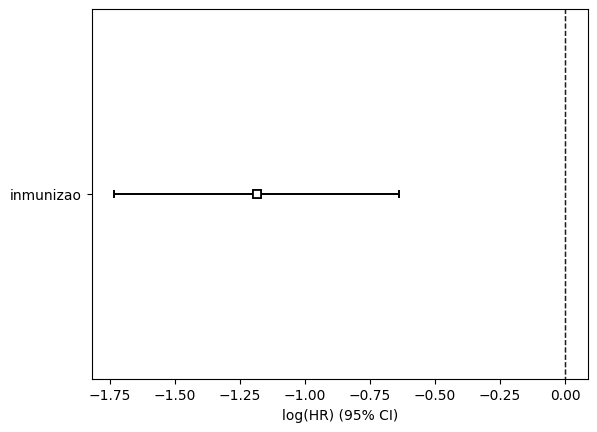

In [ ]:
ctv = CoxTimeVaryingFitter()
ctv.fit(df2, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()
ctv = CoxTimeVaryingFitter()
ctv.fit(df2, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()

## Efectividad(t)

In [ ]:
cv

,RUN,time,inmunizao
0,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,12.0,1
1,a7b49beb77412c4214376dcea24ab939cf1859a3648d31...,9.0,1
2,6b9b4f03ed27867d2efa2990a8ff79deb415e1f65636ab...,23.0,1
3,d5a4dc61555a138cc497bcbc0ab345f8080eeeee8e306b...,8.0,1
4,93ddbdfa1431e91acd1a3b15df2ea492b6f2337d3423f5...,26.0,1
...,...,...,...
68547,3c27c2f464de2ffd6191b913f64387ea00fb2d2c49ccd9...,19.0,1
68554,1fee8e6f73ae69ef1b87618a5fc0205583a8c09e27b5a3...,8.0,1
68555,67ce931af1afbbf1fdbffd409c4a206602061765196689...,19.0,1
68556,cc031ecfd353a5f8ddd3280e43dd4cc5f71b7982e1870e...,5.0,1


### Modelo: SIN REEEMPLAZO, insta-inmune, solo se activa una binaria

In [ ]:
#CON REEEMPLAZO, insta-inmune, solo se activa una binaria
increments = [0, 7, 14, 21]

cv2 = pd.DataFrame()

new_rows = []

for index, row in cv.iterrows():
    # Extraer id y tiempo base
    id_value = row['RUN']
    base_time = row['time']
    
    for inc in increments:
        new_row = {
            'RUN': id_value,
            'time': base_time + inc,
            'I_0': 1 if 7 > inc >= 0 else 0,
            'I_1': 1 if 14 > inc >= 7 else 0,
            'I_2': 1 if 21 > inc >= 14 else 0,
            'I_3': 1 if 28 > inc >= 21 else 0
        }
        new_rows.append(new_row)

cv2 = pd.DataFrame(new_rows)
cv2

,RUN,time,I_0,I_1,I_2,I_3
0,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,12.0,1,0,0,0
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,19.0,0,1,0,0
2,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,26.0,0,0,1,0
3,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,33.0,0,0,0,1
4,a7b49beb77412c4214376dcea24ab939cf1859a3648d31...,9.0,1,0,0,0
...,...,...,...,...,...,...
229063,cc031ecfd353a5f8ddd3280e43dd4cc5f71b7982e1870e...,26.0,0,0,0,1
229064,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,2.0,1,0,0,0
229065,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,9.0,0,1,0,0
229066,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,16.0,0,0,1,0


Iteration 1: norm_delta = 8.84e-01, step_size = 0.9500, log_lik = -904.22489, newton_decrement = 1.04e+01, seconds_since_start = 0.4
Iteration 2: norm_delta = 9.57e-02, step_size = 0.9500, log_lik = -893.82672, newton_decrement = 1.25e-01, seconds_since_start = 0.8
Iteration 3: norm_delta = 1.20e-02, step_size = 0.9500, log_lik = -893.69890, newton_decrement = 1.48e-03, seconds_since_start = 1.2
Iteration 4: norm_delta = 7.90e-04, step_size = 1.0000, log_lik = -893.69742, newton_decrement = 5.63e-06, seconds_since_start = 1.6
Iteration 5: norm_delta = 6.87e-07, step_size = 1.0000, log_lik = -893.69741, newton_decrement = 4.36e-12, seconds_since_start = 1.9
Convergence completed after 5 iterations.
covariate
I_0    0.649973
I_1    0.701447
I_2    0.659137
I_3    0.846187
dtype: float64
           95% lower-bound  95% upper-bound
covariate                                  
I_0               0.834267         0.260745
I_1               0.874385         0.290424
I_2               0.870553  

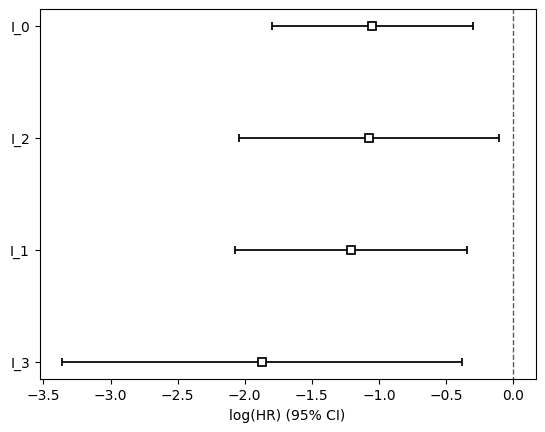

In [ ]:
df2 = add_covariate_to_timeline(base, cv2, duration_col="time", id_col="RUN", event_col="event") #6m 57s

df2['I_0'].fillna(0,inplace=True)
df2['I_1'].fillna(0,inplace=True)
df2['I_2'].fillna(0,inplace=True)
df2['I_3'].fillna(0,inplace=True)
df2['stop'].replace(0,base.stop.max(),inplace=True)
ctv2 = CoxTimeVaryingFitter()
ctv2.fit(df2, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
#ctv2.print_summary()
ctv2.plot()
coef2 = ctv2.params_
conf_int2 = ctv2.confidence_intervals_

hazard_ratios2 = 1-np.exp(coef2)
hazard_ratios_conf_int2 = 1-np.exp(conf_int2)
print(hazard_ratios2)
print(hazard_ratios_conf_int2)

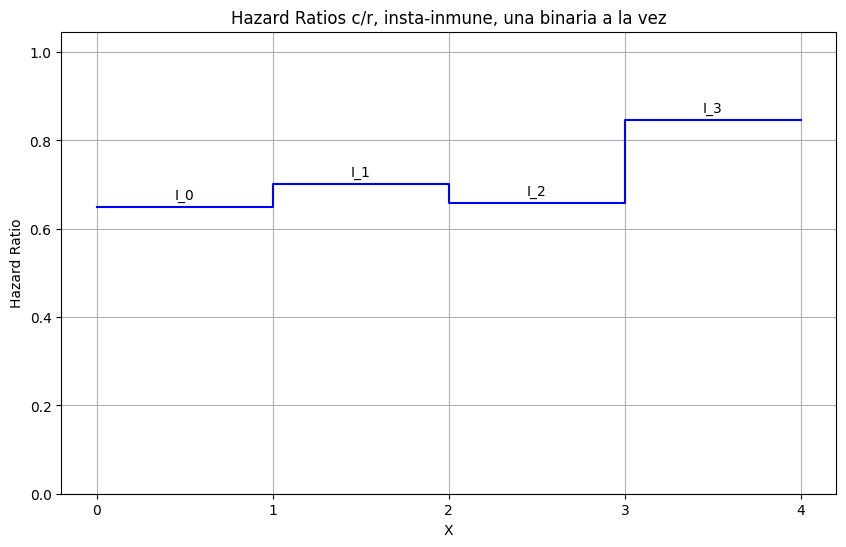

In [ ]:
x = [0, 1, 2, 3, 4]
y = list(hazard_ratios2) + [hazard_ratios2.iloc[-1]]  

plt.figure(figsize=(10, 6))


plt.step(x, y, where='post', linestyle='-', color='b')

for i, hr in enumerate(hazard_ratios2):
    plt.text(x[i+1] - 0.5, hazard_ratios2[i] + 0.01, f'I_{i}', ha='center', va='bottom', color='black')

plt.xlabel('X')
plt.ylabel('Hazard Ratio')
plt.title('Hazard Ratios s/r, insta-inmune, una binaria a la vez')

plt.xticks(np.arange(min(x), max(x)+1, 1))

plt.ylim(bottom=0, top=max(y) + 0.2)  

# Mostrar el gráfico
plt.grid(True)
plt.show()

### Modelo: SIN REEEMPLAZO, insta-inmune, se activan varias binarias

In [ ]:
#CON REEEMPLAZO, insta-inmune, se activan varias binarias
increments = [0, 7, 14, 21]

cv2_1 = pd.DataFrame()

new_rows = []

for index, row in cv.iterrows():
    # Extraer id y tiempo base
    id_value = row['RUN']
    base_time = row['time']
    
    for inc in increments:
        new_row = {
            'RUN': id_value,
            'time': base_time + inc,
            'I_0': 1 if inc >= 0 else 0,
            'I_1': 1 if inc >= 7 else 0,
            'I_2': 1 if inc >= 14 else 0,
            'I_3': 1 if inc >= 21 else 0
        }
        new_rows.append(new_row)

cv2_1 = pd.DataFrame(new_rows)
df2_1 = add_covariate_to_timeline(base, cv2_1, duration_col="time", id_col="RUN", event_col="event") #9m 35s 22w
df2_1['I_0'].fillna(0,inplace=True)
df2_1['I_1'].fillna(0,inplace=True)
df2_1['I_2'].fillna(0,inplace=True)
df2_1['I_3'].fillna(0,inplace=True)
df2_1['stop'].replace(0,base.stop.max(),inplace=True)
df2_1

,start,I_0,I_1,I_2,I_3,stop,RUN,event
0,0.0,0.0,0.0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,1.0,0.0,0.0,0.0,31.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,31.0,1.0,1.0,0.0,0.0,34.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
3,0.0,0.0,0.0,0.0,0.0,34.0,00002189304469ac9a966c4839627e100f6286cdddc141...,False
4,29.0,0.0,0.0,0.0,0.0,34.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
...,...,...,...,...,...,...,...,...
231806,0.0,0.0,0.0,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231807,5.0,1.0,0.0,0.0,0.0,12.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231808,12.0,1.0,1.0,0.0,0.0,19.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231809,19.0,1.0,1.0,1.0,0.0,26.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


Iteration 1: norm_delta = 4.58e-01, step_size = 0.9500, log_lik = -904.22489, newton_decrement = 1.04e+01, seconds_since_start = 0.4
Iteration 2: norm_delta = 1.13e-01, step_size = 0.9500, log_lik = -893.82672, newton_decrement = 1.25e-01, seconds_since_start = 0.8
Iteration 3: norm_delta = 1.18e-02, step_size = 0.9500, log_lik = -893.69890, newton_decrement = 1.48e-03, seconds_since_start = 1.2
Iteration 4: norm_delta = 7.83e-04, step_size = 1.0000, log_lik = -893.69742, newton_decrement = 5.63e-06, seconds_since_start = 1.7
Iteration 5: norm_delta = 6.85e-07, step_size = 1.0000, log_lik = -893.69741, newton_decrement = 4.36e-12, seconds_since_start = 2.1
Convergence completed after 5 iterations.


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

<lifelines.CoxTimeVaryingFitter: fitted with 231811 periods, 67731 subjects, 82 events>
         event col = 'event'
number of subjects = 67731
 number of periods = 231811
  number of events = 82
partial log-likelihood = -893.70
  time fit was run = 2024-07-31 00:52:03 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
I_0        -1.05       0.35       0.38            -1.80            -0.30                 0.17                 0.74
I_1        -0.16       0.85       0.54            -1.22             0.91                 0.29                 2.47
I_2         0.13       1.14       0.61            -1.06             1.33                 0.34                 3.78
I_3        -0.80       0.45       0.85            -2.46             0.87                 0.09                 2.38

            cmp to     z    p   -log2(p)
covariate                               
I_0           0.00 -2.75 0.01       7.40
I_1           0.00 -0.29 0.77       0.38
I_2           0.00  0.22 0.83       0.27
I_3           0.00 -0.94 0.35       1.52
---
Partial AIC = 1795.39
log-likelihood ratio test = 21.05 on 4 df
-log2(p) of ll-ratio test = 11.66

<Axes: xlabel='log(HR) (95% CI)'>

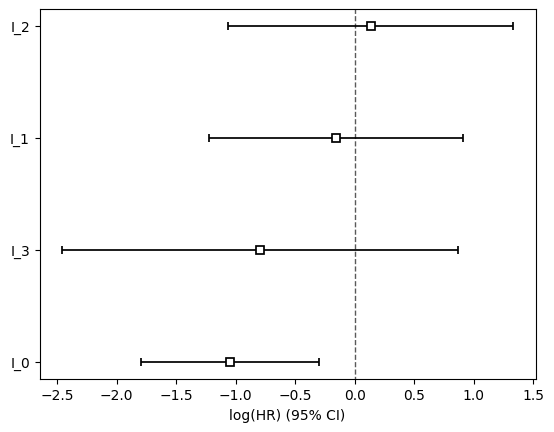

In [ ]:
from lifelines import CoxTimeVaryingFitter

ctv2_1 = CoxTimeVaryingFitter()
ctv2_1.fit(df2_1, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv2_1.print_summary()
ctv2_1.plot()

In [ ]:
coef2_1 = ctv2_1.params_
conf_int2_1 = ctv2_1.confidence_intervals_

hazard_ratios2_1 = 1-np.exp(coef2_1)
hazard_ratios_conf_int2_1 = 1-np.exp(conf_int2_1)
print(hazard_ratios2_1)
print(hazard_ratios_conf_int2_1)

covariate
I_0    0.649973
I_1    0.147059
I_2   -0.141718
I_3    0.548754
dtype: float64
           95% lower-bound  95% upper-bound
covariate                                  
I_0               0.834267         0.260745
I_1               0.705932        -1.473946
I_2               0.655169        -2.780174
I_3               0.914455        -1.380310


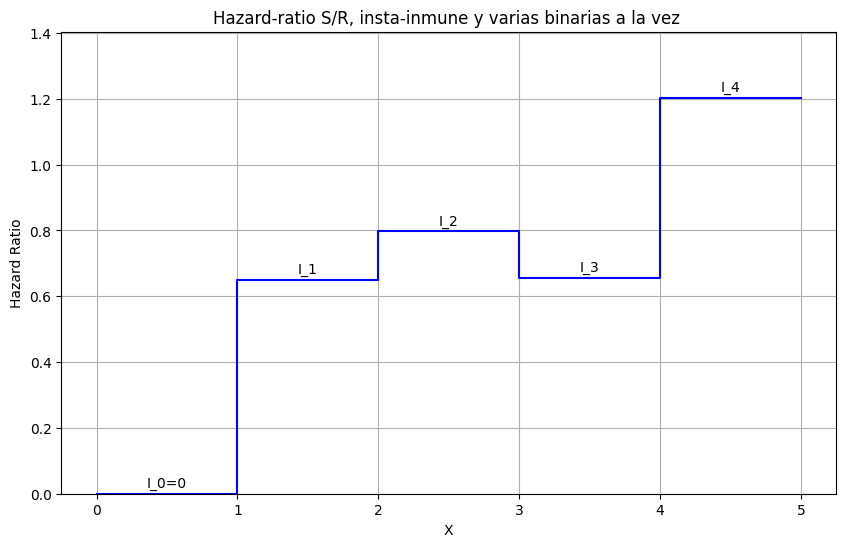

In [ ]:
x = [0, 1, 2, 3, 4,5]
y = [0,0,0,0,0,0]  
j=0
r=1
for i in hazard_ratios2_1:
    j=j+i
    if r==4:
        y[r+1]=j
    y[r]=j
    r=r+1



plt.figure(figsize=(10, 6))
plt.step(x, y, where='post', linestyle='-', color='b')

plt.text(x[1] - 0.5, 0 + 0.01, 'I_0=0', ha='center', va='bottom', color='black')
for i, hr in enumerate(y):
    if i ==4:
        break
    plt.text(x[i+2] - 0.5, y[i+1] + 0.01, f'I_{i+1}', ha='center', va='bottom', color='black')


plt.xlabel('X')
plt.ylabel('Hazard Ratio')
plt.title('Hazard-ratio S/R, insta-inmune y varias binarias a la vez ')

plt.xticks(np.arange(min(x), max(x)+1, 1))

plt.ylim(bottom=0, top=max(y) + 0.2)  

# Mostrar el gráfico
plt.grid(True)
plt.show()

### Modelo: SIN REEMPLAZO, NO INMUNE <7, sólo una binaria se activa

In [ ]:
# CON REEMPLAZO, NO INMUNE <7, sólo una binaria se activa

increments = [0, 7, 14, 21]


cv3 = pd.DataFrame()

new_rows = []


for index, row in cv.iterrows():

    id_value = row['RUN']
    base_time = row['time']
    
  
    for inc in increments:
        new_row = {
            'RUN': id_value,
            'time': base_time + inc,
            #'I_0': 0 if  inc >= 0 else 0,
            'I_1': 1 if  14 > inc >= 7 else 0,
            'I_2': 1 if  21 > inc >= 14 else 0,
            'I_3': 1 if  28 > inc >= 21 else 0
        }
        new_rows.append(new_row)

cv3 = pd.DataFrame(new_rows)
cv3

,RUN,time,I_1,I_2,I_3
0,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,12.0,0,0,0
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,19.0,1,0,0
2,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,26.0,0,1,0
3,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,33.0,0,0,1
4,a7b49beb77412c4214376dcea24ab939cf1859a3648d31...,9.0,0,0,0
...,...,...,...,...,...
229063,cc031ecfd353a5f8ddd3280e43dd4cc5f71b7982e1870e...,26.0,0,0,1
229064,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,2.0,0,0,0
229065,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,9.0,1,0,0
229066,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,16.0,0,1,0


In [ ]:
df3 = add_covariate_to_timeline(base, cv3, duration_col="time", id_col="RUN", event_col="event") #7m 53s con 22weeks

In [ ]:
df3['I_1'].fillna(0,inplace=True)
df3['I_2'].fillna(0,inplace=True)
df3['I_3'].fillna(0,inplace=True)
df3['stop'].replace(0,base.stop.max(),inplace=True)
df3

,start,I_1,I_2,I_3,stop,RUN,event
0,0.0,0.0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,0.0,0.0,0.0,31.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,31.0,1.0,0.0,0.0,34.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
3,0.0,0.0,0.0,0.0,34.0,00002189304469ac9a966c4839627e100f6286cdddc141...,False
4,29.0,0.0,0.0,0.0,34.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
...,...,...,...,...,...,...,...
231806,0.0,0.0,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231807,5.0,0.0,0.0,0.0,12.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231808,12.0,1.0,0.0,0.0,19.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231809,19.0,0.0,1.0,0.0,26.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


Iteration 1: norm_delta = 5.77e-01, step_size = 0.9500, log_lik = -904.22489, newton_decrement = 5.30e+00, seconds_since_start = 0.5
Iteration 2: norm_delta = 1.12e-01, step_size = 0.9500, log_lik = -898.68139, newton_decrement = 1.63e-01, seconds_since_start = 0.9
Iteration 3: norm_delta = 1.62e-02, step_size = 0.9500, log_lik = -898.51157, newton_decrement = 2.80e-03, seconds_since_start = 1.3
Iteration 4: norm_delta = 1.15e-03, step_size = 1.0000, log_lik = -898.50875, newton_decrement = 1.21e-05, seconds_since_start = 1.7
Iteration 5: norm_delta = 1.46e-06, step_size = 1.0000, log_lik = -898.50873, newton_decrement = 1.96e-11, seconds_since_start = 2.1
Convergence completed after 5 iterations.


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

<lifelines.CoxTimeVaryingFitter: fitted with 231811 periods, 67731 subjects, 82 events>
         event col = 'event'
number of subjects = 67731
 number of periods = 231811
  number of events = 82
partial log-likelihood = -898.51
  time fit was run = 2024-07-31 00:57:16 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
I_1        -0.96       0.38       0.44            -1.81            -0.10                 0.16                 0.91
I_2        -0.80       0.45       0.49            -1.76             0.16                 0.17                 1.17
I_3        -1.59       0.20       0.76            -3.07            -0.10                 0.05                 0.90

            cmp to     z    p   -log2(p)
covariate                               
I_1           0.00 -2.19 0.03       5.12
I_2           0.00 -1.64 0.10       3.32
I_3           0.00 -2.10 0.04       4.80
---
Partial AIC = 1803.02
log-likelihood ratio test = 11.43 on 3 df
-log2(p) of ll-ratio test = 6.70

<Axes: xlabel='log(HR) (95% CI)'>

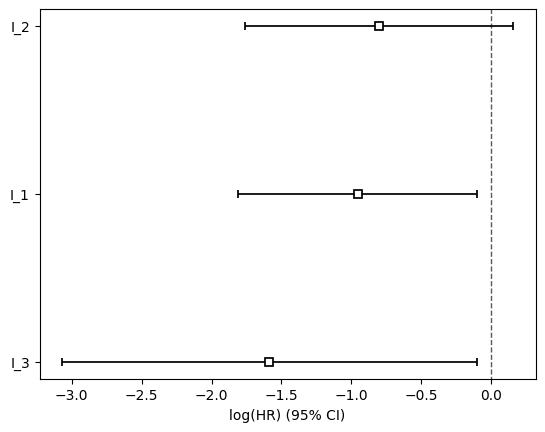

In [ ]:
from lifelines import CoxTimeVaryingFitter

ctv3 = CoxTimeVaryingFitter()
ctv3.fit(df3, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv3.print_summary()
ctv3.plot()

In [ ]:
coef3 = ctv3.params_
conf_int3 = ctv3.confidence_intervals_

hazard_ratios3 = 1-np.exp(coef3)
hazard_ratios_conf_int3 = 1-np.exp(conf_int3)
print(hazard_ratios3)
print(hazard_ratios_conf_int3)

covariate
I_1    0.615471
I_2    0.552288
I_3    0.795213
dtype: float64
           95% lower-bound  95% upper-bound
covariate                                  
I_1               0.836730         0.094366
I_2               0.828338        -0.167683
I_3               0.953479         0.098515


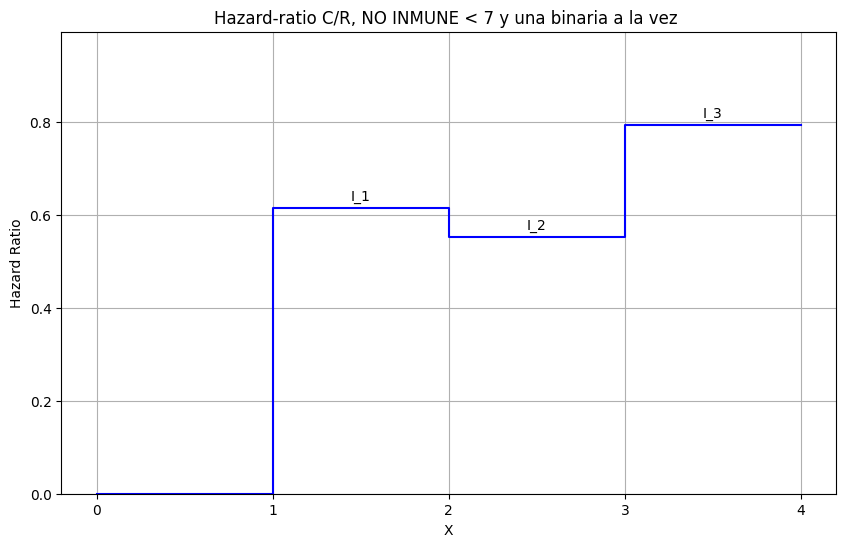

In [ ]:

x = [0, 1, 2, 3, 4]
y = [0] + list(hazard_ratios3) + [hazard_ratios3.iloc[-1]]  


plt.figure(figsize=(10, 6))
plt.step(x, y, where='post', linestyle='-', color='b')


for i, hr in enumerate(hazard_ratios3):
    plt.text(x[i+2] - 0.5, hazard_ratios3[i] + 0.01, f'I_{i+1}', ha='center', va='bottom', color='black')


plt.xlabel('X')
plt.ylabel('Hazard Ratio')
plt.title('Hazard-ratio C/R, NO INMUNE < 7 y una binaria a la vez ')

plt.xticks(np.arange(min(x), max(x)+1, 1))

plt.ylim(bottom=0, top=max(y) + 0.2)  

# Mostrar el gráfico
plt.grid(True)
plt.show()

### Modelo: SIN REEMPLAZO, NO INMUNE <7, varias binarias activs

In [ ]:
# CON REEMPLAZO, NO INMUNE <7, varias binarias activs

increments = [0, 7, 14, 21]


cv3_1 = pd.DataFrame()

new_rows = []


for index, row in cv.iterrows():

    id_value = row['RUN']
    base_time = row['time']
    
  
    for inc in increments:
        new_row = {
            'RUN': id_value,
            'time': base_time + inc,
            #'I_0': 1 if   inc >= 0 else 0,
            'I_1': 1 if   inc >= 7 else 0,
            'I_2': 1 if   inc >= 14 else 0,
            'I_3': 1 if   inc >= 21 else 0
        }
        new_rows.append(new_row)

cv3_1 = pd.DataFrame(new_rows)
cv3_1

,RUN,time,I_1,I_2,I_3
0,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,12.0,0,0,0
1,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,19.0,1,0,0
2,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,26.0,1,1,0
3,2210152b4f55db42615f7896776dccfc0361fbebeb2d2d...,33.0,1,1,1
4,a7b49beb77412c4214376dcea24ab939cf1859a3648d31...,9.0,0,0,0
...,...,...,...,...,...
229063,cc031ecfd353a5f8ddd3280e43dd4cc5f71b7982e1870e...,26.0,1,1,1
229064,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,2.0,0,0,0
229065,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,9.0,1,0,0
229066,69f14d46da840fd976b262ed1c1bb4266920dab7f64c86...,16.0,1,1,0


In [ ]:
df3_1 = add_covariate_to_timeline(base, cv3_1, duration_col="time", id_col="RUN", event_col="event") #6m 24s

In [ ]:
df3_1['I_1'].fillna(0,inplace=True)
df3_1['I_2'].fillna(0,inplace=True)
df3_1['I_3'].fillna(0,inplace=True)
df3_1['stop'].replace(0,base.stop.max(),inplace=True)
df3_1

,start,I_1,I_2,I_3,stop,RUN,event
0,0.0,0.0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,0.0,0.0,0.0,31.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,31.0,1.0,0.0,0.0,34.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
3,0.0,0.0,0.0,0.0,34.0,00002189304469ac9a966c4839627e100f6286cdddc141...,False
4,29.0,0.0,0.0,0.0,34.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
...,...,...,...,...,...,...,...
231806,0.0,0.0,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231807,5.0,0.0,0.0,0.0,12.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231808,12.0,1.0,0.0,0.0,19.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False
231809,19.0,1.0,1.0,0.0,26.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


Iteration 1: norm_delta = 4.23e-01, step_size = 0.9500, log_lik = -904.22489, newton_decrement = 5.30e+00, seconds_since_start = 0.4
Iteration 2: norm_delta = 1.23e-01, step_size = 0.9500, log_lik = -898.68139, newton_decrement = 1.63e-01, seconds_since_start = 0.8
Iteration 3: norm_delta = 1.73e-02, step_size = 0.9500, log_lik = -898.51157, newton_decrement = 2.80e-03, seconds_since_start = 1.2
Iteration 4: norm_delta = 1.20e-03, step_size = 1.0000, log_lik = -898.50875, newton_decrement = 1.21e-05, seconds_since_start = 1.6
Iteration 5: norm_delta = 1.46e-06, step_size = 1.0000, log_lik = -898.50873, newton_decrement = 1.96e-11, seconds_since_start = 2.0
Convergence completed after 5 iterations.


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

<lifelines.CoxTimeVaryingFitter: fitted with 231811 periods, 67731 subjects, 82 events>
         event col = 'event'
number of subjects = 67731
 number of periods = 231811
  number of events = 82
partial log-likelihood = -898.51
  time fit was run = 2024-07-31 01:03:15 UTC

---
            coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                         
I_1        -0.96       0.38       0.44            -1.81            -0.10                 0.16                 0.91
I_2         0.15       1.16       0.61            -1.05             1.35                 0.35                 3.86
I_3        -0.78       0.46       0.85            -2.45             0.88                 0.09                 2.41

            cmp to     z    p   -log2(p)
covariate                               
I_1           0.00 -2.19 0.03       5.12
I_2           0.00  0.25 0.80       0.32
I_3           0.00 -0.92 0.36       1.49
---
Partial AIC = 1803.02
log-likelihood ratio test = 11.43 on 3 df
-log2(p) of ll-ratio test = 6.70

<Axes: xlabel='log(HR) (95% CI)'>

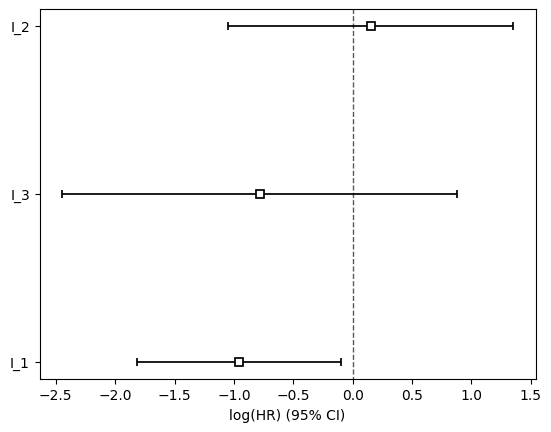

In [ ]:
from lifelines import CoxTimeVaryingFitter

ctv3_1 = CoxTimeVaryingFitter()
ctv3_1.fit(df3_1, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv3_1.print_summary()
ctv3_1.plot()

In [ ]:
coef3_1 = ctv3_1.params_
conf_int3_1 = ctv3_1.confidence_intervals_

hazard_ratios3_1 = 1-np.exp(coef3_1)
hazard_ratios_conf_int3_1 = 1-np.exp(conf_int3_1)
print(hazard_ratios3_1)
print(hazard_ratios_conf_int3_1)

covariate
I_1    0.615471
I_2   -0.164313
I_3    0.542593
dtype: float64
           95% lower-bound  95% upper-bound
covariate                                  
I_1               0.836730         0.094366
I_2               0.648545        -2.857182
I_3               0.913350        -1.414563


In [ ]:
y = [0,0,0,0]  
j=0
r=1
for i in hazard_ratios3_1:
    j=j+i
    y[r]=j
    r=r+1
y

[0, 0.6154707418315103, 0.4511578742342036, 0.9937503926086225]

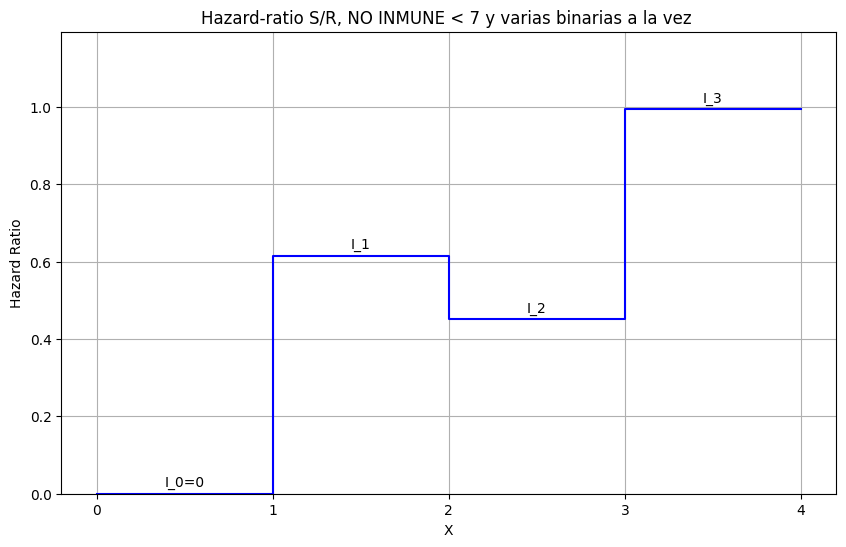

In [ ]:

x = [0, 1, 2, 3, 4]
y = [0,0,0,0,0]  
j=0
r=1
for i in hazard_ratios3_1:
    j=j+i
    if r==3:
        y[r+1]=j
    y[r]=j
    r=r+1



plt.figure(figsize=(10, 6))
plt.step(x, y, where='post', linestyle='-', color='b')

plt.text(x[1] - 0.5, 0 + 0.01, 'I_0=0', ha='center', va='bottom', color='black')
for i, hr in enumerate(y):
    if i ==3:
        break
    plt.text(x[i+2] - 0.5, y[i+1] + 0.01, f'I_{i+1}', ha='center', va='bottom', color='black')


plt.xlabel('X')
plt.ylabel('Hazard Ratio')
plt.title('Hazard-ratio S/R, NO INMUNE < 7 y varias binarias a la vez ')

plt.xticks(np.arange(min(x), max(x)+1, 1))

plt.ylim(bottom=0, top=max(y) + 0.2)  

# Mostrar el gráfico
plt.grid(True)
plt.show()

## Preprocesamiento 2

In [32]:
df26=dfs[26]
df26.shape[0]

144790

In [160]:
df26_norte = df26[df26['Macrozona2']=="Norte"]
df26_centro = df26[df26['Macrozona2']=="Centro"]
df26_sur = df26[df26['Macrozona2']=="Sur"]

In [34]:
df_f = df26

In [407]:
print("No inmunes: " ,df_f[df_f['inmunizado']==0].shape[0], " Inmunes: " ,df_f[df_f['inmunizado']==1].shape[0])

No inmunes:  7782  Inmunes:  75301


In [35]:
base_df = df_f[['RUN','SEXO','sex*prem','FECHA_NAC','group','prematuro_extremo','muy_prematuro','prematuro_moderado','prematuro','FECHA_INMUNIZACION','FECHA_ING','inmunizado','event','age_3m','age_6m','si_3_meses','si_6_meses']]
base_df = base_df.sort_values(by='event')
base_df

KeyError: "['sex*prem', 'prematuro_extremo', 'muy_prematuro', 'prematuro_moderado', 'prematuro'] not in index"

In [56]:
T_inicial = pd.to_datetime('2024-03-31')
T_0_inmune = pd.to_datetime(df['FECHA_INMUNIZACION'].min())
T_0_inmune = df['FECHA_INMUNIZACION'].min()
#T_final_inmune = df['FECHA_INMUNIZACION'].max()

#base_df['long_inmune'] = (base_df['FECHA_INMUNIZACION'] - T_0_inmune).dt.days
base_df['age_3m'] = (base_df['age_3m'] - T_inicial).dt.days
base_df['age_6m'] = (base_df['age_6m'] - T_inicial).dt.days
base_df['FECHA_INMUNIZACION'] = (base_df['FECHA_INMUNIZACION'] - T_inicial).dt.days
base_df['FECHA_ING'] = (base_df['FECHA_ING'] - T_inicial).dt.days
base_df['FECHA_NAC'] = (base_df['FECHA_NAC'] - T_inicial).dt.days

base_df['start'] = np.where(base_df['group']=="CATCH_UP", 0, base_df['FECHA_NAC'])

base_df['age_3m'] = np.where(base_df['age_3m']<=0, 0, base_df['age_3m'])
base_df['age_6m'] = np.where(base_df['age_6m']<=0, 0, base_df['age_6m'])
#base_df['si_3_meses'] = np.ones(len(base_df))


base_df

,RUN,SEXO,sex*prem,FECHA_NAC,group,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,FECHA_INMUNIZACION,FECHA_ING,inmunizado,event,age_3m,age_6m,si_3_meses,si_6_meses,start
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,1,0,-182,CATCH_UP,0,0,0,0,40.0,NaN,1,False,0.0,1.0,1,1,0
93622,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,1,0,30,SEASONAL,0,0,0,0,30.0,NaN,1,False,NaN,NaN,0,0,30
93621,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,1,0,24,SEASONAL,0,0,0,0,NaN,NaN,0,False,NaN,NaN,0,0,24
93620,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,1,0,28,SEASONAL,0,0,0,0,29.0,NaN,1,False,NaN,NaN,0,0,28
93619,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,0,0,28,SEASONAL,0,0,0,0,29.0,NaN,1,False,NaN,NaN,0,0,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52466,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,1,0,-62,CATCH_UP,0,0,0,0,2.0,52.0,1,True,29.0,NaN,1,0,0
52855,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,1,0,-62,CATCH_UP,0,0,0,0,NaN,51.0,0,True,29.0,NaN,1,0,0
52951,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,1,0,-64,CATCH_UP,0,0,0,0,NaN,41.0,0,True,27.0,NaN,1,0,0
64469,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,1,0,-37,CATCH_UP,0,0,1,1,NaN,30.0,0,True,53.0,NaN,1,0,0


In [57]:
df_model = pd.melt(base_df, id_vars=['RUN'], value_vars=['FECHA_INMUNIZACION', 'FECHA_ING','age_3m','age_6m'],var_name='fecha', value_name='duration',ignore_index=True)
df_model = df_model.merge(base_df[['RUN','SEXO','sex*prem','FECHA_NAC','group','prematuro_extremo','muy_prematuro','prematuro_moderado','prematuro','inmunizado','event','si_3_meses','si_6_meses'
                                   ]], on = 'RUN' , how='left')
df_model['group']=np.where(df_model['group']=='CATCH_UP',1,0)
df_model

,RUN,fecha,duration,SEXO,sex*prem,FECHA_NAC,group,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,inmunizado,event,si_3_meses,si_6_meses
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,FECHA_INMUNIZACION,40.0,1,0,-182,1,0,0,0,0,1,False,1,1
1,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,FECHA_INMUNIZACION,30.0,1,0,30,0,0,0,0,0,1,False,0,0
2,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,FECHA_INMUNIZACION,NaN,1,0,24,0,0,0,0,0,0,False,0,0
3,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,FECHA_INMUNIZACION,29.0,1,0,28,0,0,0,0,0,1,False,0,0
4,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,FECHA_INMUNIZACION,29.0,0,0,28,0,0,0,0,0,1,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
554319,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,age_6m,NaN,1,0,-62,1,0,0,0,0,1,True,1,0
554320,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,age_6m,NaN,1,0,-62,1,0,0,0,0,0,True,1,0
554321,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,age_6m,NaN,1,0,-64,1,0,0,0,0,0,True,1,0
554322,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,age_6m,NaN,1,0,-37,1,0,0,1,1,0,True,1,0


In [58]:
base = df_model[df_model.fecha=='FECHA_ING'][['RUN','SEXO','sex*prem','group','prematuro_extremo','muy_prematuro','prematuro_moderado','prematuro','duration','event']].drop_duplicates(subset=['RUN'])
base['duration'] = base['duration'].fillna(df_model.duration.max())
base

,RUN,SEXO,sex*prem,group,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,duration,event
138581,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,1,0,1,0,0,0,0,141.0,False
138582,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,1,0,0,0,0,0,0,141.0,False
138583,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,1,0,0,0,0,0,0,141.0,False
138584,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,1,0,0,0,0,0,0,141.0,False
138585,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,0,0,0,0,0,0,0,141.0,False
...,...,...,...,...,...,...,...,...,...,...
277157,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,1,0,1,0,0,0,0,52.0,True
277158,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,1,0,1,0,0,0,0,51.0,True
277159,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,1,0,1,0,0,0,0,41.0,True
277160,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,1,0,1,0,0,1,1,30.0,True


In [59]:
base = to_long_format(base, duration_col="duration")
base[base.event==0]

,RUN,SEXO,sex*prem,group,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,event,start,stop
138581,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,1,0,1,0,0,0,0,False,0,141.0
138582,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,1,0,0,0,0,0,0,False,0,141.0
138583,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,1,0,0,0,0,0,0,False,0,141.0
138584,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,1,0,0,0,0,0,0,False,0,141.0
138585,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,0,0,0,0,0,0,0,False,0,141.0
...,...,...,...,...,...,...,...,...,...,...,...
276902,e23c4129842b866ec536b58f633d7b09f95500d45563e1...,0,0,1,0,0,0,0,False,0,141.0
276903,3af5a2e3a7ab97fa919c601c5ee0fd67be64e19607d883...,0,0,1,0,0,0,0,False,0,141.0
276904,34c13f7c0d90ecd9e31d7b8533a328e55597eab48bc2b6...,1,0,1,0,0,0,0,False,0,141.0
276905,dfba962b39367a8881932b204247d10dec29baee33e3b0...,1,0,1,0,0,0,0,False,0,141.0


In [60]:
base_fp=base

In [61]:
covs_fijas1 = base_fp[['RUN','prematuro']]
covs_fijas2 = base_fp[['RUN','prematuro_extremo','muy_prematuro','prematuro_moderado']]
covs_fijas3 = base_fp[['RUN','SEXO','muy_prematuro']]
covs_fijas4 = base_fp[['RUN','SEXO','prematuro_extremo','muy_prematuro','prematuro_moderado']]
covs_fijas5 = base_fp[['RUN','SEXO','muy_prematuro']]
covs_fijas3


,RUN,SEXO,muy_prematuro
138581,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,1,0
138582,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,1,0
138583,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,1,0
138584,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,1,0
138585,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,0,0
...,...,...,...
277157,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,1,0
277158,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,1,0
277159,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,1,0
277160,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,1,0


In [62]:
base = base[['RUN','stop','event']].merge(base_df[['RUN','start']],on='RUN',how='left') 
base

,RUN,stop,event,start
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,141.0,False,0
1,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,141.0,False,30
2,015191623338247135aa8b4ff0da3ab2a776ebe51d2e16...,141.0,False,24
3,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,141.0,False,28
4,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,141.0,False,28
...,...,...,...,...
138576,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,52.0,True,0
138577,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,51.0,True,0
138578,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,41.0,True,0
138579,68ebfa65c8dad48ea996997b71542f7d6030d507cb3b52...,30.0,True,0


In [63]:
cv = df_model[df_model.fecha=='FECHA_INMUNIZACION'][['RUN','duration','inmunizado']]
cv = cv.rename(columns={'duration':'time'})
cv = cv.dropna()
cv

,RUN,time,inmunizado
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,40.0,1
1,92d316e7c501a8b3fcc6ae986d85fd5b8479686daded7e...,30.0,1
3,08d45494de1c303eb8308b072285b4e38416cb7222f14e...,29.0,1
4,24aa3250d55a48f46d42be31cc75de220002a9d7b5bd13...,29.0,1
5,a48ed528da91d05b664751361716571e2655138f6e10f9...,28.0,1
...,...,...,...
138564,e0499247fc954c489b1a83853fc7299e74fac8f1031b4e...,33.0,1
138572,521bc9c4940b0bebf8a1c2dbc05753da1500cd36252525...,11.0,1
138573,7eb2ad10988ea14f52f20eec24d4741445bd5c968db921...,24.0,1
138574,c2586a4807cdf96f87b6498150b01501d7a55237d75803...,12.0,1


## Modelo vrs 3meses

In [1356]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials

# Configurar las credenciales
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/spreadsheets",
         "https://www.googleapis.com/auth/drive.file", "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name("credencials.json", scope)
client = gspread.authorize(creds)

# Abrir la hoja de cálculo
spreadsheet = client.open("Efecto_NIRSE")  # Reemplaza con el nombre de tu hoja de cálculo
sheet = spreadsheet.sheet1 

# Seleccionar la hoja de trabajo por nombre
worksheet = spreadsheet.worksheet("Models")


In [1351]:
df_f[(df_f['VRS']==1) & (df_f['inmunizado']==0) ].shape[0], df_f[(df_f['VRS']==1) & (df_f['inmunizado']==1) ].shape[0]

(124, 106)

In [1433]:
df_f[(df_f['inmunizado']==0) ].shape[0], df_f[ (df_f['inmunizado']==1) ].shape[0]

(11426, 97587)

In [64]:
df_0 = add_covariate_to_timeline(base, cv, duration_col="time", id_col="RUN", event_col="event") 
df_0['inmunizado'].fillna(0,inplace=True)
df_0['stop'].replace(0,base.stop.max(),inplace=True)

,start,inmunizado,stop,RUN,event
0,0.0,NaN,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,1.0,141.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,29.0,NaN,141.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
3,0.0,NaN,60.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False
4,60.0,1.0,141.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False
...,...,...,...,...,...
245434,5.0,1.0,141.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False
245435,0.0,NaN,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
245436,54.0,1.0,141.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
245437,0.0,NaN,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


Iteration 1: norm_delta = 4.63e-01, step_size = 0.9500, log_lik = -2935.97905, newton_decrement = 2.09e+01, seconds_since_start = 0.5
Iteration 2: norm_delta = 2.22e-02, step_size = 0.9500, log_lik = -2916.62988, newton_decrement = 5.72e-02, seconds_since_start = 1.0
Iteration 3: norm_delta = 1.14e-03, step_size = 0.9500, log_lik = -2916.57276, newton_decrement = 1.49e-04, seconds_since_start = 1.5
Iteration 4: norm_delta = 5.99e-05, step_size = 1.0000, log_lik = -2916.57261, newton_decrement = 3.74e-07, seconds_since_start = 2.0
Iteration 5: norm_delta = 2.13e-10, step_size = 1.0000, log_lik = -2916.57261, newton_decrement = 4.71e-18, seconds_since_start = 2.5
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 245439 periods, 138581 subjects, 255 events>
         event col = 'event'
number of subjects = 138581
 number of periods = 245439
  number of events = 255
partial log-likelihood = -2916.57
  time fit was run = 2024-09-09 14:21:24 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -0.88      0.42      0.14           -1.15           -0.61                0.32                0.54

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -6.35 <0.005     32.08
---
Partial AIC = 5835.15
log-likelihood ratio test = 38.81 on 1 df
-log2(p) of ll-ratio test = 31.00

covariate
inmunizado    0.584898
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.683606         0.455395


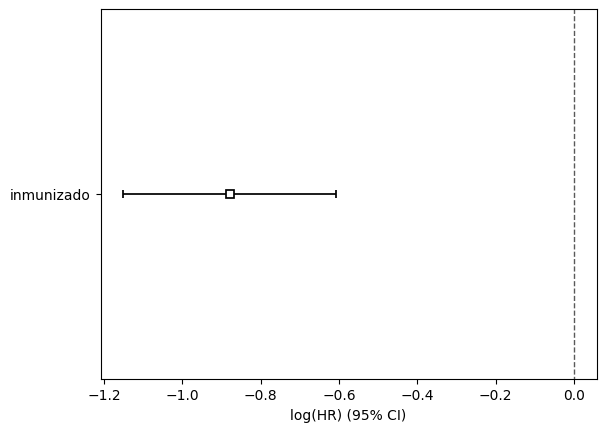

In [76]:
df_0['inmunizado'].fillna(0,inplace=True)
df_0['stop'].replace(0,base.stop.max(),inplace=True)

ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_0, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_0.print_summary()
ctv_0.plot()

coef_0 = ctv_0.params_
conf_0 = ctv_0.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)

In [81]:
df_0['duration']=df_0['stop'] - df_0['start']

In [103]:
df_0['time*inmune'] = df_0['inmunizado'] * df_0['stop']
df_0['time*inmune'].fillna(0,inplace=True)

C:\Users\ntrig\AppData\Local\Temp\ipykernel_15448\3871973712.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_0['time*inmune'].fillna(0,inplace=True)


In [94]:
df_0

,start,inmunizado,stop,RUN,event,duration,time*inmune
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,24.0,0.0
1,24.0,1.0,141.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,117.0,141.0
2,29.0,0.0,141.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False,112.0,0.0
3,0.0,0.0,60.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False,60.0,0.0
4,60.0,1.0,141.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False,81.0,141.0
...,...,...,...,...,...,...,...
245434,5.0,1.0,141.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False,136.0,141.0
245435,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,54.0,0.0
245436,54.0,1.0,141.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,87.0,141.0
245437,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,5.0,0.0


In [105]:
print(df_0.isna().sum())

# Verificar si hay valores infinitos en las columnas
print((df_0 == np.inf).sum())
print((df_0 == -np.inf).sum())

start          0
inmunizado     0
stop           0
RUN            0
event          0
duration       0
time*inmune    0
dtype: int64
start          0
inmunizado     0
stop           0
RUN            0
event          0
duration       0
time*inmune    0
dtype: int64
start          0
inmunizado     0
stop           0
RUN            0
event          0
duration       0
time*inmune    0
dtype: int64


Iteration 1: norm_delta = 4.63e-01, step_size = 0.9500, log_lik = -2935.97905, newton_decrement = 2.09e+01, seconds_since_start = 0.6
Iteration 2: norm_delta = 2.22e-02, step_size = 0.9500, log_lik = -2916.62988, newton_decrement = 5.72e-02, seconds_since_start = 1.1
Iteration 3: norm_delta = 1.14e-03, step_size = 0.9500, log_lik = -2916.57276, newton_decrement = 1.49e-04, seconds_since_start = 1.6
Iteration 4: norm_delta = 5.99e-05, step_size = 1.0000, log_lik = -2916.57261, newton_decrement = 3.74e-07, seconds_since_start = 2.1
Iteration 5: norm_delta = 2.13e-10, step_size = 1.0000, log_lik = -2916.57261, newton_decrement = 4.71e-18, seconds_since_start = 2.6
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 245439 periods, 138581 subjects, 255 events>
         event col = 'event'
number of subjects = 138581
 number of periods = 245439
  number of events = 255
partial log-likelihood = -2916.573
  time fit was run = 2024-09-09 18:19:00 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
inmunizado -0.879     0.415     0.139          -1.151          -0.608               0.316               0.545

            cmp to      z       p  -log2(p)
covariate                                  
inmunizado   0.000 -6.346 <0.0005    32.078
---
Partial AIC = 5835.145
log-likelihood ratio test = 38.813 on 1 df
-log2(p) of ll-ratio test = 30.998

<Axes: xlabel='log(HR) (95% CI)'>

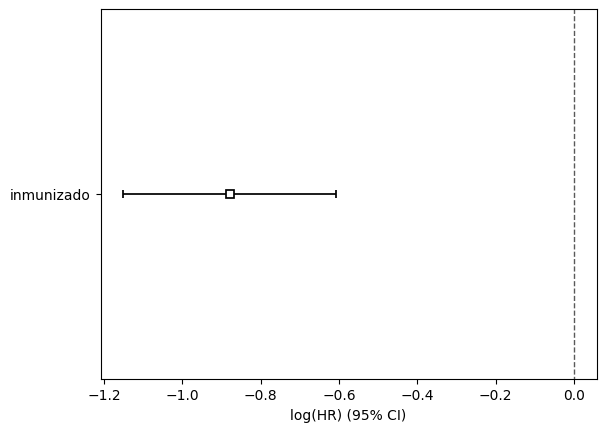

In [106]:
ctv_0 = CoxTimeVaryingFitter()
ctv_0.fit(df_0[['start','inmunizado','stop','RUN','event']], id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_0.print_summary(3)
ctv_0.plot()

Iteration 1: norm_delta = 6.62e-01, step_size = 0.9500, log_lik = -3042.02917, newton_decrement = 4.23e+01, seconds_since_start = 1.2
Iteration 2: norm_delta = 6.76e-02, step_size = 0.9500, log_lik = -3005.26086, newton_decrement = 5.54e-01, seconds_since_start = 2.3
Iteration 3: norm_delta = 3.06e-03, step_size = 0.9500, log_lik = -3004.71030, newton_decrement = 1.14e-03, seconds_since_start = 3.4
Iteration 4: norm_delta = 3.17e-07, step_size = 1.0000, log_lik = -3004.70916, newton_decrement = 1.23e-11, seconds_since_start = 4.7
Convergence success after 4 iterations.


<lifelines.CoxPHFitter: fitted with 245439 total observations, 245184 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 245439
number of events observed = 255
   partial log-likelihood = -3004.71
         time fit was run = 2024-09-09 19:43:41 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -1.12      0.32      0.13           -1.37           -0.87                0.25                0.42

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -8.78 <0.005     59.12
---
Concordance = 0.62
Partial AIC = 6011.42
log-likelihood ratio test = 74.64 on 1 df
-log2(p) of ll-ratio test = 57.30

covariate
inmunizado    0.675008
Name: coef, dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.747102         0.582362


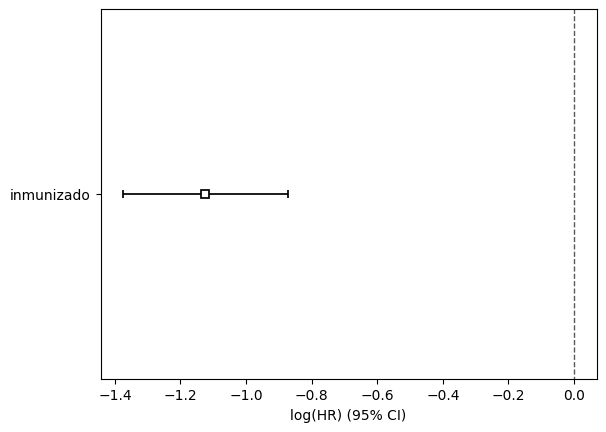

In [107]:
cph = CoxPHFitter()
cph.fit(df_0[['event','duration','inmunizado']],duration_col='duration', event_col="event",show_progress=True)
cph.print_summary()
cph.plot()

coef_0 = cph.params_
conf_0 = cph.confidence_intervals_

hazard_ratios_0 = 1-np.exp(coef_0)
hazard_ratios_conf_int_0 = 1-np.exp(conf_0)
print(hazard_ratios_0)
print(hazard_ratios_conf_int_0)


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 245439 total observations, 245184 right-censored observations>
         test_name = proportional_hazard_test

---
                 test_statistic      p  -log2(p)
inmunizado km              9.78 <0.005      9.15
           rank            7.65   0.01      7.46



1. Variable 'inmunizado' failed the non-proportional test: p-value is 0.0018.

   Advice: with so few unique values (only 2), you can include `strata=['inmunizado', ...]` in the
call in `.fit`. See documentation in link [E] below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[[<Axes: xlabel='rank-transformed time\n(p=0.0057)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0018)'>]]

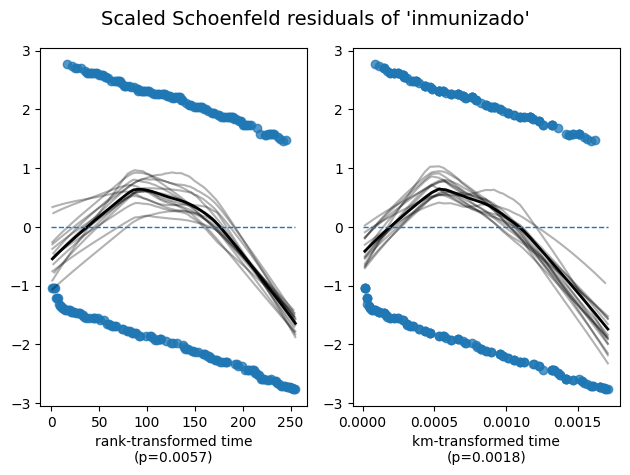

In [108]:
cph.check_assumptions(df_0[['event','duration','inmunizado']],show_plots=True)

In [ ]:
from lifelines import CoxPHFitter

covariables = df_0.columns.difference(['RUN', 'start', 'stop'])

# Crear y ajustar el modelo de Cox usando CoxPHFitter
cph = CoxPHFitter()
cph.fit(df_0[covariables], duration_col='duration', event_col='event')

# Mostrar el resumen del modelo ajustado
cph.print_summary()

# Testear el supuesto de hazard rate proportional
cph.check_assumptions(df_0)

In [ ]:
from lifelines.statistics import proportional_hazard_test
test_results = proportional_hazard_test(ctv_0, df_0, time_transform="rank")
test_results.print_summary()

In [174]:
from lifelines.statistics import proportional_hazard_test

# Generar residuos de Schoenfeld
residuals = ctv_0.compute_residuals(df_0, "schoenfeld")

# Unir los residuos con el tiempo
residuals_with_time = residuals.join(df_0[['start', 'stop']])

# Hacer regresión o graficar residuos contra el tiempo para evaluar la proporcionalidad
# Aquí podrías usar statsmodels o simplemente visualizar las tendencias
import seaborn as sns
import matplotlib.pyplot as plt

# Graficar para cada covariable
for covariate in residuals.columns:
    plt.figure(figsize=(10, 6))
    sns.regplot(x='stop', y=covariate, data=residuals_with_time, lowess=True)
    plt.title(f'Residuals of {covariate} vs. Time')
    plt.show()

# Alternativamente, podrías usar un test de riesgos proporcionales (asumir que id_col es RUN)
test_results = proportional_hazard_test(ctv_0, df_0, time_transform="rank")
test_results.print_summary()

AttributeError: 'CoxTimeVaryingFitter' object has no attribute 'entry_col'

In [173]:
#from lifelines import CoxPHFitter
#from lifelines.datasets import load_rossi

# Cargar datos de ejemplo
#df = load_rossi()

# Crear y ajustar el modelo de Cox
#cph = CoxPHFitter()
#cph.fit(df, duration_col='week', event_col='arrest')

# Testear el supuesto de hazard rate proportional
ctv_0.check_assumptions(df_0)

AttributeError: 'CoxTimeVaryingFitter' object has no attribute 'entry_col'

In [1368]:
hazard_ratios_list = [round(coef, 2) for coef in hazard_ratios_0]
worksheet.update('D8', [[coef]  for coef in hazard_ratios_list])

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\228541921.py:2: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update('D8', [[coef]  for coef in hazard_ratios_list])


{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Models!D8',
 'updatedRows': 1,
 'updatedColumns': 1,
 'updatedCells': 1}

In [1367]:
#hazard_ratios_list = hazard_ratios_0.tolist()
#hazard_ratios_conf_int_list = hazard_ratios_conf_int_0.values.tolist()
#worksheet.update('D8', [[coef] + conf_int for coef, conf_int in zip(hazard_ratios_list, hazard_ratios_conf_int_list)])

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\1646838033.py:3: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update('D8', [[coef]  for coef in hazard_ratios_list])


{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Models!D8',
 'updatedRows': 1,
 'updatedColumns': 1,
 'updatedCells': 1}

In [1426]:

covs=[covs_fijas1, covs_fijas2, covs_fijas3, covs_fijas4, covs_fijas5]

In [ ]:
for i in covs:
    d=df_0.merge(i, on='RUN',how='left') 
    ctv_01 = CoxTimeVaryingFitter()
    ctv_01.fit(d, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
    print("-----------------------MODELO INMUNE +,", ', '.join(i), "------------------------------")
    ctv_01.print_summary()
    ctv_01.plot()

    coef_01 = ctv_01.params_
    conf_01 = ctv_01.confidence_intervals_

    hazard_ratios_01 = 1-np.exp(coef_01)
    hazard_ratios_conf_int_01 = 1-np.exp(conf_01)
    print(hazard_ratios_01)
    print(hazard_ratios_conf_int_01)

In [66]:
cv_3m = df_model[df_model.fecha=='age_3m'][['RUN','duration','si_3_meses']]
cv_3m = cv_3m.rename(columns={'duration':'time'})
cv_3m = cv_3m.dropna()
cv_3m

,RUN,time,si_3_meses
277162,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,0.0,1
277485,673da0cbe0e951a5e80afd592ca9c7d6c3337df57a81d2...,0.0,1
277594,289e6d0a94c2d96ce1cfe37b7796e2d3c8a20b0bf57b28...,53.0,1
278343,7c69471a7300836f5d677290b4f19472e79239295c75a8...,26.0,1
278572,ac0d120ad817b03f20a624f0a6000647e834e1c4b8f252...,62.0,1
...,...,...,...
415737,3f8b63880c53fdfe9ffaf5349c4dedfc98a1dec09f7a90...,28.0,1
415738,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,29.0,1
415739,9523f24f385d4e4ce789b78ee9b7ea9753064b2c4b3871...,29.0,1
415740,ea1e21c50e910808675e40967adc1df731bb5b703951b7...,27.0,1


In [67]:
df_01 = add_covariate_to_timeline(df_0, cv_3m, duration_col="time", id_col="RUN", event_col="event") 

In [68]:
df_01['si_3_meses'].fillna(0,inplace=True)
df_01['inmunizado'].fillna(0,inplace=True)
df_01['stop'].replace(0,base.stop.max(),inplace=True)
df_01

C:\Users\ntrig\AppData\Local\Temp\ipykernel_15448\449081320.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_01['si_3_meses'].fillna(0,inplace=True)
C:\Users\ntrig\AppData\Local\Temp\ipykernel_15448\449081320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

,start,inmunizado,si_3_meses,stop,RUN,event
0,0.0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,1.0,0.0,45.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,45.0,1.0,1.0,141.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
3,29.0,0.0,0.0,141.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
4,0.0,0.0,1.0,60.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False
...,...,...,...,...,...,...
278765,5.0,1.0,0.0,141.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False
278766,0.0,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
278767,54.0,1.0,0.0,141.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
278768,0.0,0.0,1.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


In [632]:
#df_01[df_01['RUN']=='8b21f695eb1be4c9b3f389995472a74fcd26e3cf78e3a7cce3bdd86ffc9ba804']

,start,inmunizado,stop,RUN,event,si_3_meses
111040,0.0,0.0,11.0,8b21f695eb1be4c9b3f389995472a74fcd26e3cf78e3a7...,False,0.0
111041,11.0,0.0,50.0,8b21f695eb1be4c9b3f389995472a74fcd26e3cf78e3a7...,False,1.0
111042,50.0,1.0,76.0,8b21f695eb1be4c9b3f389995472a74fcd26e3cf78e3a7...,False,1.0


In [69]:
covs=[#covs_fijas1, covs_fijas2, 
      covs_fijas3
      #, covs_fijas4, covs_fijas5
      ]

In [70]:
df_oo = df_01.merge(covs_fijas3, on='RUN',how='left') 
df_oo

,start,inmunizado,si_3_meses,stop,RUN,event,SEXO,muy_prematuro
0,0.0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0,0
1,24.0,1.0,0.0,45.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0,0
2,45.0,1.0,1.0,141.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0,0
3,29.0,0.0,0.0,141.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False,1,0
4,0.0,0.0,1.0,60.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False,1,0
...,...,...,...,...,...,...,...,...
278765,5.0,1.0,0.0,141.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False,0,0
278766,0.0,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,1,0
278767,54.0,1.0,0.0,141.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,1,0
278768,0.0,0.0,1.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,0,1


Iteration 1: norm_delta = 7.27e-01, step_size = 0.9500, log_lik = -2935.97905, newton_decrement = 5.66e+01, seconds_since_start = 1.0
Iteration 2: norm_delta = 6.65e-02, step_size = 0.9500, log_lik = -2886.51631, newton_decrement = 2.57e+00, seconds_since_start = 2.0
Iteration 3: norm_delta = 2.13e-02, step_size = 0.9500, log_lik = -2883.66471, newton_decrement = 2.00e-01, seconds_since_start = 2.9
Iteration 4: norm_delta = 3.22e-03, step_size = 1.0000, log_lik = -2883.45557, newton_decrement = 3.52e-03, seconds_since_start = 3.8
Iteration 5: norm_delta = 4.02e-05, step_size = 1.0000, log_lik = -2883.45201, newton_decrement = 5.37e-07, seconds_since_start = 4.7
Iteration 6: norm_delta = 6.20e-09, step_size = 1.0000, log_lik = -2883.45201, newton_decrement = 1.27e-14, seconds_since_start = 5.7
Convergence completed after 6 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 278770 periods, 138581 subjects, 255 events>
         event col = 'event'
number of subjects = 138581
 number of periods = 278770
  number of events = 255
partial log-likelihood = -2883.45
  time fit was run = 2024-09-09 14:15:45 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -0.99      0.37      0.14           -1.26           -0.72                0.28                0.49
si_3_meses    -0.89      0.41      0.13           -1.14           -0.64                0.32                0.53
SEXO           0.38      1.46      0.13            0.13            0.63                1.14                1.88
muy_prematuro  1.06      2.88      0.32            0.43            1.69                1.53                5.43

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -7.11 <0.005     39.62
si_3_meses       0.00 -6.90 <0.005     37.44
SEXO             0.00  2.98 <0.005      8.43
muy_prematuro    0.00  3.28 <0.005      9.92
---
Partial AIC = 5774.90
log-likelihood ratio test = 105.05 on 4 df
-log2(p) of ll-ratio test = 70.04

covariate
inmunizado       0.627638
si_3_meses       0.589172
SEXO            -0.463572
muy_prematuro   -1.883255
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.716436         0.511032
si_3_meses            0.680952         0.470990
SEXO                 -0.139171        -0.880353
muy_prematuro        -0.531672        -4.427506


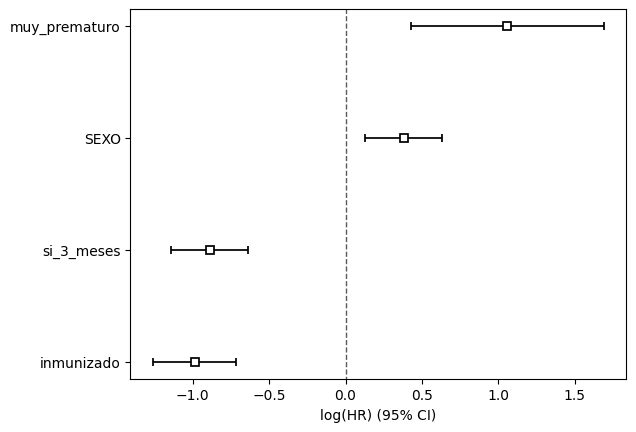

In [71]:
ctv_01 = CoxTimeVaryingFitter()
ctv_01.fit(df_oo, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_01.print_summary()
ctv_01.plot()

coef_01 = ctv_01.params_
conf_01 = ctv_01.confidence_intervals_

hazard_ratios_01 = 1-np.exp(coef_01)
hazard_ratios_conf_int_01 = 1-np.exp(conf_01)
print(hazard_ratios_01)
print(hazard_ratios_conf_int_01)

In [75]:
# Calcular los residuos de Schoenfeld para tu modelo Cox dependiente del tiempo
schoenfeld_residuals = ctv_01.compute_residuals(df_oo, kind='schoenfeld')

# Mostrar los primeros valores para entender la estructura
print(schoenfeld_residuals.head())

AttributeError: 'CoxTimeVaryingFitter' object has no attribute 'entry_col'

Iteration 1: norm_delta = 7.90e-01, step_size = 0.9500, log_lik = -2614.90584, newton_decrement = 5.28e+01, seconds_since_start = 1.0
Iteration 2: norm_delta = 6.64e-02, step_size = 0.9500, log_lik = -2565.51839, newton_decrement = 5.08e-01, seconds_since_start = 1.8
Iteration 3: norm_delta = 3.88e-03, step_size = 0.9500, log_lik = -2565.00947, newton_decrement = 1.73e-03, seconds_since_start = 2.6
Iteration 4: norm_delta = 2.07e-04, step_size = 1.0000, log_lik = -2565.00775, newton_decrement = 4.45e-06, seconds_since_start = 3.4
Iteration 5: norm_delta = 1.09e-08, step_size = 1.0000, log_lik = -2565.00774, newton_decrement = 1.18e-14, seconds_since_start = 4.2
Convergence completed after 5 iterations.
-----------------------MODELO INMUNE + 3M +, RUN, prematuro ------------------------------


<lifelines.CoxTimeVaryingFitter: fitted with 205103 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205103
  number of events = 228
partial log-likelihood = -2565.01
  time fit was run = 2024-08-21 12:31:16 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -1.25      0.29      0.15           -1.54           -0.96                0.21                0.38
si_3_meses -0.88      0.42      0.15           -1.16           -0.59                0.31                0.55
prematuro   0.36      1.44      0.20           -0.02            0.75                0.98                2.11

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -8.37 <0.005     53.99
si_3_meses    0.00 -6.02 <0.005     29.10
prematuro     0.00  1.84   0.07      3.94
---
Partial AIC = 5136.02
log-likelihood ratio test = 99.80 on 3 df
-log2(p) of ll-ratio test = 68.98

covariate
inmunizado    0.712818
si_3_meses    0.584207
prematuro    -0.435625
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.785549         0.615421
si_3_meses         0.687526         0.446726
prematuro          0.022282        -1.107990
Iteration 1: norm_delta = 8.21e-01, step_size = 0.9500, log_lik = -2614.90584, newton_decrement = 5.84e+01, seconds_since_start = 0.9
Iteration 2: norm_delta = 9.71e-02, step_size = 0.9500, log_lik = -2566.58680, newton_decrement = 3.96e+00, seconds_since_start = 2.0
Iteration 3: norm_delta = 2.66e-02, step_size = 0.9500, log_lik = -2562.19817, newton_decrement = 3.48e-01, seconds_since_start = 3.1
Iteration 4: norm_delta = 5.55e-03, step_size = 1.0000, log_lik = -2561.82725, newton_decrement = 1.21e-02, seconds_since_start = 4.2
Iteration 5: norm_delta = 2.39e-04, step_size = 1.0000, log_lik = -2561.81484, newton_decrement = 2.21e-05, seconds_since_start = 5.2
Iteration 6

<lifelines.CoxTimeVaryingFitter: fitted with 205103 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205103
  number of events = 228
partial log-likelihood = -2561.81
  time fit was run = 2024-08-21 12:31:22 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
inmunizado         -1.24      0.29      0.15           -1.54           -0.95                0.22                0.39
si_3_meses         -0.87      0.42      0.15           -1.16           -0.59                0.31                0.56
prematuro_extremo   1.02      2.77      0.71           -0.37            2.41                0.69               11.19
muy_prematuro       1.13      3.10      0.34            0.46            1.80                1.59                6.05
prematuro_moderado  0.10      1.10      0.24           -0.38            0.57                0.69                1.76

                    cmp to     z      p  -log2(p)
covariate                                        
inmunizado            0.00 -8.36 <0.005     53.78
si_3_meses            0.00 -5.99 <0.005     28.86
prematuro_extremo     0.00  1.43   0.15      2.72
muy_prematuro         0.00  3.32 <0.005     10.13
prematuro_moderado    0.00  0.40   0.69      0.53
---
Partial AIC = 5133.63
log-likelihood ratio test = 106.18 on 5 df
-log2(p) of ll-ratio test = 68.37

covariate
inmunizado            0.711789
si_3_meses            0.582581
prematuro_extremo    -1.773900
muy_prematuro        -2.103946
prematuro_moderado   -0.099727
dtype: float64
                    95% lower-bound  95% upper-bound
covariate                                           
inmunizado                 0.784729         0.614133
si_3_meses                 0.686308         0.444555
prematuro_extremo          0.312293       -10.188653
muy_prematuro             -0.591174        -5.054949
prematuro_moderado         0.313263        -0.761080
Iteration 1: norm_delta = 8.29e-01, step_size = 0.9500, log_lik = -2614.90584, newton_decrement = 6.01e+01, seconds_since_start = 0.9
Iteration 2: norm_delta = 8.98e-02, step_size = 0.9500, log_lik = -2562.26652, newton_decrement = 2.61e+00, seconds_since_start = 1.9
Iteration 3: norm_delta = 2.06e-02, step_size = 0.9500, log_lik = -2559.42694, newton_decrement = 1.65e-01, seconds_since_start = 2.8
Iteration 4: norm_delta = 2.98e-03, step_size =

...

covariate
inmunizado       0.713201
si_3_meses       0.585171
SEXO            -0.415994
muy_prematuro   -2.010589
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.785785         0.616024
si_3_meses            0.688233         0.448039
SEXO                 -0.087257        -0.844126
muy_prematuro        -0.545298        -4.865304
Iteration 1: norm_delta = 8.37e-01, step_size = 0.9500, log_lik = -2614.90584, newton_decrement = 6.17e+01, seconds_since_start = 1.0
Iteration 2: norm_delta = 9.75e-02, step_size = 0.9500, log_lik = -2563.17218, newton_decrement = 3.93e+00, seconds_since_start = 2.0
Iteration 3: norm_delta = 2.64e-02, step_size = 0.9500, log_lik = -2558.82086, newton_decrement = 3.41e-01, seconds_since_start = 3.0
Iteration 4: norm_delta = 5.45e-03, step_size = 1.0000, log_lik = -2558.45762, newton_decrement = 1.16e-02, seconds_since_start = 4.0
Iteration 5: norm_delta = 2.29e-04, step_size =

<lifelines.CoxTimeVaryingFitter: fitted with 205103 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205103
  number of events = 228
partial log-likelihood = -2558.45
  time fit was run = 2024-08-21 12:31:35 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
inmunizado         -1.25      0.29      0.15           -1.54           -0.95                0.22                0.39
si_3_meses         -0.88      0.42      0.15           -1.16           -0.59                0.31                0.55
SEXO                0.35      1.41      0.13            0.08            0.61                1.09                1.84
prematuro_extremo   1.02      2.78      0.71           -0.37            2.42                0.69               11.22
muy_prematuro       1.11      3.05      0.34            0.45            1.78                1.56                5.95
prematuro_moderado  0.08      1.08      0.24           -0.39            0.55                0.68                1.74

                    cmp to     z      p  -log2(p)
covariate                                        
inmunizado            0.00 -8.36 <0.005     53.87
si_3_meses            0.00 -6.01 <0.005     28.99
SEXO                  0.00  2.57   0.01      6.64
prematuro_extremo     0.00  1.44   0.15      2.73
muy_prematuro         0.00  3.27 <0.005      9.86
prematuro_moderado    0.00  0.34   0.74      0.44
---
Partial AIC = 5128.89
log-likelihood ratio test = 112.92 on 6 df
-log2(p) of ll-ratio test = 70.77

covariate
inmunizado            0.712103
si_3_meses            0.583433
SEXO                 -0.414961
prematuro_extremo    -1.780856
muy_prematuro        -2.048886
prematuro_moderado   -0.084427
dtype: float64
                    95% lower-bound  95% upper-bound
covariate                                           
inmunizado                 0.784962         0.614558
si_3_meses                 0.686951         0.445684
SEXO                      -0.086393        -0.842900
prematuro_extremo          0.310498       -10.215577
muy_prematuro             -0.562719        -4.948418
prematuro_moderado         0.322896        -0.736780
Iteration 1: norm_delta = 8.19e-01, step_size = 0.9500, log_lik = -2614.90584, newton_decrement = 6.05e+01, seconds_since_start = 1.1
Iteration 2: norm_delta = 8.28e-02, step_size = 0.9500, log_lik = -2563.87870, newton_decrement = 3.76e+00, seconds_since_start = 2.1
Iteration 3: norm_delta = 2.34e-02, step_size = 0.9500, log_lik = -2559.67241, newton_decrement =

<lifelines.CoxTimeVaryingFitter: fitted with 205103 periods, 109009 subjects, 228 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205103
  number of events = 228
partial log-likelihood = -2559.23
  time fit was run = 2024-08-21 12:31:43 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
inmunizado    -1.25      0.29      0.15           -1.54           -0.96                0.21                0.38
si_3_meses    -0.88      0.41      0.15           -1.17           -0.59                0.31                0.55
SEXO           0.34      1.41      0.14            0.07            0.61                1.08                1.84
muy_prematuro  1.01      2.76      0.59           -0.14            2.16                0.87                8.71
sex*prem       0.14      1.14      0.72           -1.28            1.55                0.28                4.70

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -8.39 <0.005     54.19
si_3_meses       0.00 -6.04 <0.005     29.25
SEXO             0.00  2.50   0.01      6.32
muy_prematuro    0.00  1.73   0.08      3.57
sex*prem         0.00  0.19   0.85      0.23
---
Partial AIC = 5128.47
log-likelihood ratio test = 111.34 on 5 df
-log2(p) of ll-ratio test = 71.99

covariate
inmunizado       0.713253
si_3_meses       0.585150
SEXO            -0.408921
muy_prematuro   -1.757798
sex*prem        -0.144539
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.785826         0.616089
si_3_meses            0.688217         0.448011
SEXO                 -0.076411        -0.844144
muy_prematuro         0.127088        -7.712737
sex*prem              0.721084        -3.696641


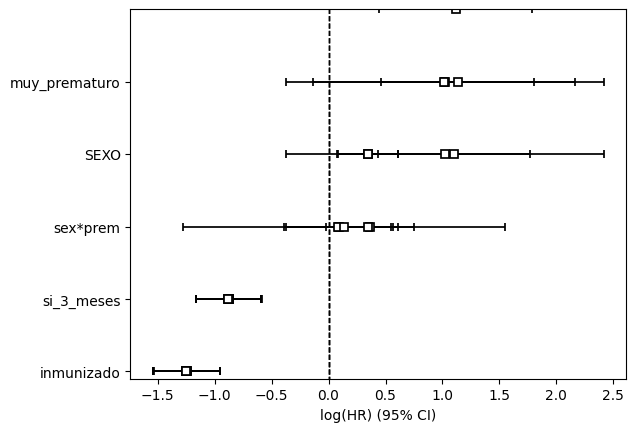

In [1434]:


for i in covs:
    d=df_01.merge(i, on='RUN',how='left') 
    ctv_01 = CoxTimeVaryingFitter()
    ctv_01.fit(d, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
    print("-----------------------MODELO INMUNE + 3M +,", ', '.join(i), "------------------------------")
    ctv_01.print_summary()
    ctv_01.plot()

    coef_01 = ctv_01.params_
    conf_01 = ctv_01.confidence_intervals_

    hazard_ratios_01 = 1-np.exp(coef_01)
    hazard_ratios_conf_int_01 = 1-np.exp(conf_01)
    print(hazard_ratios_01)
    print(hazard_ratios_conf_int_01)

## Tabla 1.2

In [371]:
cv_6m = df_model[df_model.fecha=='age_6m'][['RUN','duration','si_6_meses']]
cv_6m = cv_6m.rename(columns={'duration':'time'})
cv_6m = cv_6m.dropna()
cv_6m

,RUN,time,si_6_meses
283737,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,1.0,1
296711,e084d477b4bb0b6e2041a8b9e65201d5b3a6334e82f5bf...,16.0,1
308289,8fcff193ec821e7346aa98a3ae47aa072ceadd07cfac56...,3.0,1
331484,b54df94e5b6399c1ec22a7726dd03e2892d07b0d82ee84...,18.0,1
331652,4603fa82819acb209651450673bcfd8dcbe9aa8b4d1b71...,18.0,1
...,...,...,...
378263,166d90aba07147bfe44bea6e28ea04a657e213d6e4d303...,6.0,1
378281,99c65ec7a12c5d4f61732fb378f6e137e0474faa76b1d9...,20.0,1
378282,cbc83e3e284156ac3a6afa8d9661ad9100045818fda80f...,13.0,1
378297,f9eb87c4ada5610272bc04335a6f30751bbfb083359d08...,15.0,1


In [372]:
df_t1 = add_covariate_to_timeline(df_01, cv_6m, duration_col="time", id_col="RUN", event_col="event") 

In [ ]:
df_t1['si_3_meses'].fillna(0,inplace=True)
df_t1['si_6_meses'].fillna(0,inplace=True)
df_t1['inmunizado'].fillna(0,inplace=True)
df_t1['stop'].replace(0,base.stop.max(),inplace=True)
df_t1

In [374]:
df_t1

,start,inmunizao,stop,RUN,event,si_3_meses,si_6_meses
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0,0.0
1,24.0,1.0,55.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0,0.0
2,0.0,0.0,55.0,00002189304469ac9a966c4839627e100f6286cdddc141...,False,0.0,0.0
3,29.0,0.0,55.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False,0.0,0.0
4,0.0,0.0,18.0,000159d772b59f1cf493db5fb5cc31c8c52ee611637419...,False,1.0,0.0
...,...,...,...,...,...,...,...
183889,5.0,1.0,55.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False,0.0,0.0
183890,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0,0.0
183891,54.0,1.0,55.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0,0.0
183892,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0,0.0


In [377]:
df_t=df_t1.copy()
df_t['not_inm_days'] = np.where(df_t['inmunizado']==0, df_t['stop']-df_t['start'], 0)
df_t['inm_days'] = np.where(df_t['inmunizado']==1, df_t['stop']-df_t['start'], 0)
df_t



,start,inmunizao,stop,RUN,event,si_3_meses,si_6_meses,not_inm_days,inm_days
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0,0.0,24.0,0.0
1,24.0,1.0,55.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0,0.0,0.0,31.0
2,0.0,0.0,55.0,00002189304469ac9a966c4839627e100f6286cdddc141...,False,0.0,0.0,55.0,0.0
3,29.0,0.0,55.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False,0.0,0.0,26.0,0.0
4,0.0,0.0,18.0,000159d772b59f1cf493db5fb5cc31c8c52ee611637419...,False,1.0,0.0,18.0,0.0
...,...,...,...,...,...,...,...,...,...
183889,5.0,1.0,55.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False,0.0,0.0,0.0,50.0
183890,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0,0.0,54.0,0.0
183891,54.0,1.0,55.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0,0.0,0.0,1.0
183892,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0,0.0,5.0,0.0


In [378]:
df_t['not_inm_<3m_days'] = np.where((df_t['inmunizado']==0) & (df_t['si_3_meses']==0) , df_t['stop']-df_t['start'], 0)
df_t['not_inm_3to6_days'] = np.where((df_t['inmunizado']==0) & (df_t['si_3_meses']==1) & (df_t['si_6_meses']==0)  , df_t['stop']-df_t['start'], 0)
df_t['not_inm_>6_days'] = np.where((df_t['inmunizado']==0) & (df_t['si_3_meses']==1) & (df_t['si_6_meses']==1)  , df_t['stop']-df_t['start'], 0)
df_t['inm_<3m_days'] = np.where((df_t['inmunizado']==1) & (df_t['si_3_meses']==0) , df_t['stop']-df_t['start'], 0)
df_t['inm_3to6_days'] = np.where((df_t['inmunizado']==1) & (df_t['si_3_meses']==1) & (df_t['si_6_meses']==0)  , df_t['stop']-df_t['start'], 0)
df_t['inm_>6_days'] = np.where((df_t['inmunizado']==1) & (df_t['si_3_meses']==1) & (df_t['si_6_meses']==1)  , df_t['stop']-df_t['start'], 0)

df_t


,start,inmunizao,stop,RUN,event,si_3_meses,si_6_meses,not_inm_days,inm_days,not_inm_<3m_days,not_inm_3to6_days,not_inm_>6_days,inm_<3m_days,inm_3to6_days,inm_>6_days
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0,0.0,24.0,0.0,24.0,0.0,0.0,0.0,0.0,0.0
1,24.0,1.0,55.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0,0.0,0.0,31.0,0.0,0.0,0.0,31.0,0.0,0.0
2,0.0,0.0,55.0,00002189304469ac9a966c4839627e100f6286cdddc141...,False,0.0,0.0,55.0,0.0,55.0,0.0,0.0,0.0,0.0,0.0
3,29.0,0.0,55.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False,0.0,0.0,26.0,0.0,26.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,18.0,000159d772b59f1cf493db5fb5cc31c8c52ee611637419...,False,1.0,0.0,18.0,0.0,0.0,18.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183889,5.0,1.0,55.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False,0.0,0.0,0.0,50.0,0.0,0.0,0.0,50.0,0.0,0.0
183890,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0,0.0,54.0,0.0,54.0,0.0,0.0,0.0,0.0,0.0
183891,54.0,1.0,55.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
183892,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0,0.0,5.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0


In [390]:
n_bebes = df_t['RUN'].nunique()
print(n_bebes)

92617


In [383]:
N_not_nirse_days = df_t['not_inm_days'].sum()
N_not_nirse_less3m = df_t['not_inm_<3m_days'].sum()
N_not_nirse_3to6 = df_t['not_inm_3to6_days'].sum()
N_not_nirse_more6m = df_t['not_inm_>6_days'].sum()

N_nirse_days = df_t['inm_days'].sum()
N_nirse_less3m = df_t['inm_<3m_days'].sum()
N_nirse_3to6 = df_t['inm_3to6_days'].sum()
N_nirse_more6m = df_t['inm_>6_days'].sum()

print(f"N_not_nirse_days: {N_not_nirse_days}")
print(f"N_not_nirse_less3m: {N_not_nirse_less3m}")
print(f"N_not_nirse_3to6: {N_not_nirse_3to6}")
print(f"N_not_nirse_more6m: {N_not_nirse_more6m}")

print(f"N_nirse_days: {N_nirse_days}")
print(f"N_nirse_less3m: {N_nirse_less3m}")
print(f"N_nirse_3to6: {N_nirse_3to6}")
print(f"N_nirse_more6m: {N_nirse_more6m}")

N_not_nirse_days: 1994949.0
N_not_nirse_less3m: 867306.0
N_not_nirse_3to6: 985748.0
N_not_nirse_more6m: 141895.0
N_nirse_days: 2502963.0
N_nirse_less3m: 1353868.0
N_nirse_3to6: 933649.0
N_nirse_more6m: 215446.0


In [385]:
# Crear el DataFrame para la tabla
data = {
    'Not nirse recipients-days': [N_not_nirse_days, N_not_nirse_less3m, N_not_nirse_3to6, N_not_nirse_more6m],
    'nirse recipients-days': [N_nirse_days, N_nirse_less3m, N_nirse_3to6, N_nirse_more6m]
}

index = ['all', '<3 months', '3-6 months', '>6 months']

df_summary = pd.DataFrame(data, index=index)

# Mostrar la tabla
print(df_summary)

            Not nirse recipients-days  nirse recipients-days
all                         1994949.0              2502963.0
<3 months                    867306.0              1353868.0
3-6 months                   985748.0               933649.0
>6 months                    141895.0               215446.0


In [410]:
print("promedio días no inmune: ", df_t['not_inm_days'].mean())
print("promedio días inmune: ", df_t['inm_days'].mean())

promedio días no inmune:  10.848363731279976
promedio días inmune:  13.610900845052042


In [411]:
df_t['not_inm_days'].describe()

count    183894.000000
mean         10.848364
std          16.414919
min           0.000000
25%           0.000000
50%           1.000000
75%          16.000000
max          55.000000
Name: not_inm_days, dtype: float64

In [412]:
df_t['inm_days'].describe()

count    183894.000000
mean         13.610901
std          18.185422
min           0.000000
25%           0.000000
50%           0.000000
75%          30.000000
max          54.000000
Name: inm_days, dtype: float64

In [ ]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials

# Configurar las credenciales
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/spreadsheets",
         "https://www.googleapis.com/auth/drive.file", "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name("credencials.json", scope)
client = gspread.authorize(creds)

# Abrir la hoja de cálculo
spreadsheet = client.open("NIRSE-CL")  # Reemplaza con el nombre de tu hoja de cálculo
sheet = spreadsheet.sheet1 





In [ ]:
# Seleccionar la hoja de trabajo por nombre
worksheet = spreadsheet.worksheet("Tabla1.2")

In [400]:


data = {
    'Not nirse recipients-days': ["",
                                  N_not_nirse_less3m*n_bebes / N_not_nirse_days,
                                  N_not_nirse_3to6*n_bebes / N_not_nirse_days,
                                  N_not_nirse_more6m *n_bebes/ N_not_nirse_days],
    'Nirse recipients-days': ["",
                              N_nirse_less3m*n_bebes / N_nirse_days,
                              N_nirse_3to6*n_bebes / N_nirse_days,
                              N_nirse_more6m*n_bebes / N_nirse_days]
}

index = ['Age', '<3 months', '3-6 months', '>6 months']

# Crear el DataFrame
index = ['Age', '<3 months', '3-6 months', '>6 months']
df_summary = pd.DataFrame(data, index=index)

df_values = df_summary.values.tolist()

# Escribir los datos en celdas específicas
# Escribir encabezados



worksheet.update('C38', [['Age', 'Not nirse recipients-days', 'Nirse recipients-days']])

# Escribir los datos del DataFrame, comenzando en la celda A2
worksheet.update('C39', [[index[i]] + df_values[i] for i in range(len(df_values))])

C:\Users\ntrig\AppData\Local\Temp\ipykernel_1784\661560424.py:39: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update('C38', [['Age', 'Not nirse recipients-days', 'Nirse recipients-days']])
C:\Users\ntrig\AppData\Local\Temp\ipykernel_1784\661560424.py:42: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update('C39', [[index[i]] + df_values[i] for i in range(len(df_values))])


{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Tabla1.2!C39:E42',
 'updatedRows': 4,
 'updatedColumns': 3,
 'updatedCells': 12}

In [ ]:
# Datos a escribir
data = [
    [N_not_nirse_less3m/365, #* n_bebes / N_not_nirse_days,
     N_nirse_less3m/365], #* n_bebes / N_nirse_days],
    
    [N_not_nirse_3to6/365, #* n_bebes / N_not_nirse_days,
     N_nirse_3to6/365], #* n_bebes / N_nirse_days],
    
    [N_not_nirse_more6m/365, #* n_bebes / N_not_nirse_days,
     N_nirse_more6m/365] #* n_bebes / N_nirse_days]
]

# Aplicar np.floor() a los valores y convertir a enteros
data_truncated = [[int(np.floor(value)) for value in row] for row in data]


# Escribir los datos en la hoja de cálculo, comenzando desde la celda A1
worksheet.update('E7', data_truncated)

In [423]:

new_covs = df_f[['RUN','PESO', 'SEMANAS', 'SEXO']]
new_covs = new_covs.drop_duplicates(subset='RUN', keep='last')
print(new_covs.shape[0])
print(df_t.shape[0])
df_t = pd.merge(df_t, new_covs, on='RUN', how='left')
print(df_t.shape[0])

92617
183894
183894


In [429]:
df_t['SEMANAS'].describe()

count    183894.000000
mean         38.175351
std           1.834882
min          22.000000
25%          38.000000
50%          38.000000
75%          39.000000
max          45.000000
Name: SEMANAS, dtype: float64

In [427]:
df_t['not_inm_sex1_days'] = np.where((df_t['inmunizado']==0) & (df_t['SEXO']==1) , df_t['stop']-df_t['start'], 0)
df_t['not_inm_sex2_days'] = np.where((df_t['inmunizado']==0) & (df_t['SEXO']==2), df_t['stop']-df_t['start'], 0)
df_t['not_inm_sex3_days'] = np.where((df_t['inmunizado']==0) & (df_t['SEXO']==9), df_t['stop']-df_t['start'], 0)
df_t['inm_sex1_days'] = np.where((df_t['inmunizado']==1) & (df_t['SEXO']==1) , df_t['stop']-df_t['start'], 0)
df_t['inm_sex2_days'] = np.where((df_t['inmunizado']==1) & (df_t['SEXO']==2) , df_t['stop']-df_t['start'], 0)
df_t['inm_sex3_days'] = np.where((df_t['inmunizado']==1) & (df_t['SEXO']==9) , df_t['stop']-df_t['start'], 0)

N_not_inm_sex1_days = df_t['not_inm_sex1_days'].sum()
N_not_inm_sex2_days = df_t['not_inm_sex2_days'].sum()
N_not_inm_sex3_days = df_t['not_inm_sex3_days'].sum()

N_inm_sex1_days = df_t['inm_sex1_days'].sum()
N_inm_sex2_days = df_t['inm_sex2_days'].sum()
N_inm_sex3_days =  df_t['inm_sex3_days'].sum()

# Imprimir los resultados
print(f"N_not_inm_sex1_days: {N_not_inm_sex1_days}")
print(f"N_not_inm_sex2_days: {N_not_inm_sex2_days}")
print(f"N_not_inm_sex3_days: {N_not_inm_sex3_days}")

print(f"N_inm_sex1_days: {N_inm_sex1_days}")
print(f"N_inm_sex2_days: {N_inm_sex2_days}")
print(f"N_inm_sex3_days: {N_inm_sex3_days}")

data = [
    [N_not_inm_sex1_days/365, #* n_bebes / N_not_nirse_days,
     N_inm_sex1_days/365], #* n_bebes / N_nirse_days],
    
    [N_not_inm_sex2_days/365, #* n_bebes / N_not_nirse_days,
     N_inm_sex2_days/365], #* n_bebes / N_nirse_days],
    
    [N_not_inm_sex3_days, #* n_bebes / N_not_nirse_days,
     N_inm_sex3_days] #* n_bebes / N_nirse_days]
]

# Aplicar np.floor() a los valores y convertir a enteros
data_truncated = [[int(np.floor(value)) for value in row] for row in data]


# Escribir los datos en la hoja de cálculo, comenzando desde la celda A1
worksheet.update('E11', data_truncated)

N_not_inm_sex1_days: 1012673.0
N_not_inm_sex2_days: 982208.0
N_not_inm_sex3_days: 68.0
N_inm_sex1_days: 1268629.0
N_inm_sex2_days: 1234269.0
N_inm_sex3_days: 65.0


C:\Users\ntrig\AppData\Local\Temp\ipykernel_1784\3528703892.py:34: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet.update('E11', data_truncated)


{'spreadsheetId': '1-2qpesSusN3YQRlCdzCRIseRBAr8cpvPfjLu45BZgos',
 'updatedRange': 'Tabla1.2!E11:F13',
 'updatedRows': 3,
 'updatedColumns': 2,
 'updatedCells': 6}

In [435]:

weeks_range = range(22, 46)  

num_sem_not_inm = 0
num_sem_inm = 0
den_1=0
den_2=0

for week in weeks_range:
    col_name_not_inm = f'not_inm_weeks{week}_days'
    col_name_inm = f'inm_weeks{week}_days'
    df_t[col_name_not_inm] = np.where((df_t['inmunizado'] == 0) & (df_t['SEMANAS'] == week), df_t['stop'] - df_t['start'], 0)
    df_t[col_name_inm] = np.where((df_t['inmunizado'] == 1) & (df_t['SEMANAS'] == week), df_t['stop'] - df_t['start'], 0)
 
    num_sem_not_inm += week*df_t[col_name_not_inm].sum()
    num_sem_inm += week*df_t[col_name_inm].sum()
    den_1 += df_t[col_name_not_inm].sum()
    den_2 += df_t[col_name_inm].sum()
    
print(num_sem_not_inm/den_1)
print(num_sem_inm/den_2)



38.243865883288244
38.14092297808637


In [453]:
print(df_t[df_t['inmunizado'] == 0]['SEMANAS'].mean())
print(df_t[df_t['inmunizao'] == 1]['SEMANAS'].mean())

38.178647494675374
38.17142107835541


In [450]:
df_otro = df_f[df_f['inmunizado']==0].drop_duplicates(subset='RUN')
print(df_otro['SEMANAS'].mean())

df_otro = df_f[df_f['inmunizado'] == 1].drop_duplicates(subset='RUN')
print(df_otro['SEMANAS'].mean())


#df_f[df_f['inmunizado']==0].shape[0]


38.39776647902669
38.181267845544895


In [ ]:

data = [
    [N_not_inm_sex1_days/365, #* n_bebes / N_not_nirse_days,
     N_inm_sex1_days/365], #* n_bebes / N_nirse_days],
    
    [N_not_inm_sex2_days/365, #* n_bebes / N_not_nirse_days,
     N_inm_sex2_days/365], #* n_bebes / N_nirse_days],
    
]

# Aplicar np.floor() a los valores y convertir a enteros
data_truncated = [[int(np.floor(value)) for value in row] for row in data]

# Supongamos que worksheet está definido
worksheet.update('E11', data_truncated)

## Modelo: pro 

In [ ]:
['RUN', 'PESO', 'SEMANAS', 'SEXO']

In [44]:
# CON REEMPLAZO, NO INMUNE <7, sólo una binaria se activa

increments = list(range(0, 29))

cv_lineal = pd.DataFrame()

new_rows = []

for index, row in cv.iterrows():
    id_value = row['RUN']
    base_time = row['time']

    for inc in increments:
        new_row = {
            'RUN': id_value,
            'time': base_time + inc,
            'I_1': min(1, inc / 7) if inc < 7 else 1,
            'I_2': min(1, (inc - 7) / 7) if 7 <= inc < 14 else (1 if inc >= 14 else 0),
            'I_3': min(1, (inc - 14) / 7) if 14 <= inc < 21 else (1 if inc >= 21 else 0),
            'I_4': min(1, (inc - 21) / 7) if inc >= 21 else 0
        }
        new_rows.append(new_row)

cv_lineal = pd.DataFrame(new_rows)
cv_lineal

,RUN,time,I_1,I_2,I_3,I_4
0,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,40.0,0.000000,0.0,0.0,0.000000
1,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,41.0,0.142857,0.0,0.0,0.000000
2,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,42.0,0.285714,0.0,0.0,0.000000
3,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,43.0,0.428571,0.0,0.0,0.000000
4,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,44.0,0.571429,0.0,0.0,0.000000
...,...,...,...,...,...,...
2416971,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,26.0,1.000000,1.0,1.0,0.428571
2416972,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,27.0,1.000000,1.0,1.0,0.571429
2416973,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,28.0,1.000000,1.0,1.0,0.714286
2416974,a6d1de0f87ae1a77b56f31768b11fd37db2071667f1e81...,29.0,1.000000,1.0,1.0,0.857143


In [45]:
df_lineal = add_covariate_to_timeline(base, cv_lineal, duration_col="time", id_col="RUN", event_col="event") 

In [46]:
cv_3m = df_model[df_model.fecha=='3meses_vida'][['RUN','duration','si_3_meses']]
cv_3m = cv_3m.rename(columns={'duration':'time'})
cv_3m = cv_3m.dropna()
cv_3m

,RUN,time,si_3_meses
189158,523859c5cf172484f2e48146777d527a3c8557b9f3250b...,0.0,1
189832,1b87505821fd43ebfe6cda2c7cd0a871f37428d8fd167b...,0.0,1
190206,5a36e7904098ff9ad6e79072585c5b8d5c7e1de5e4a55f...,0.0,1
190691,31b3c65a294e58353d578b9c5322cfbd32aef7119ab776...,0.0,1
192330,af6e19085e1678a560862337a04c4f99b8071f820bfde7...,11.0,1
...,...,...,...
283725,d100227f7212c011b837a55076f65d0c21aa5eb032546f...,0.0,1
283726,a1bc79a9b57809c8aa00e590d748f6ae73e29e5bbfc254...,14.0,1
283729,f47d5f84631e933f3eea79bd5ff47793aeea808a73f06f...,0.0,1
283733,ad0ba429f576c89dfda8e34edf0fdd8043296c318211fe...,19.0,1


In [47]:
df_pro = add_covariate_to_timeline(df_lineal, cv_3m, duration_col="time", id_col="RUN", event_col="event") 

In [48]:
df_pro['si_3_meses'].fillna(0,inplace=True)
df_pro['I_1'].fillna(0,inplace=True)
df_pro['I_2'].fillna(0,inplace=True)
df_pro['I_3'].fillna(0,inplace=True)
df_pro['I_4'].fillna(0,inplace=True)
df_pro['stop'].replace(0,base.stop.max(),inplace=True)
df_pro

,start,I_1,I_2,I_3,I_4,stop,RUN,event,si_3_meses
0,0.0,0.000000,0.0,0.0,0.000000,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0
1,24.0,0.000000,0.0,0.0,0.000000,25.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0
2,25.0,0.142857,0.0,0.0,0.000000,26.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0
3,26.0,0.285714,0.0,0.0,0.000000,27.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0
4,27.0,0.428571,0.0,0.0,0.000000,28.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0
...,...,...,...,...,...,...,...,...,...
1977332,29.0,1.000000,1.0,1.0,0.428571,30.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0
1977333,30.0,1.000000,1.0,1.0,0.571429,31.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0
1977334,31.0,1.000000,1.0,1.0,0.714286,32.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0
1977335,32.0,1.000000,1.0,1.0,0.857143,33.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0


Iteration 1: norm_delta = 8.64e-01, step_size = 0.9500, log_lik = -1834.13960, newton_decrement = 3.29e+01, seconds_since_start = 1.6
Iteration 2: norm_delta = 4.73e-01, step_size = 0.9500, log_lik = -1799.98229, newton_decrement = 1.79e+00, seconds_since_start = 3.4
Iteration 3: norm_delta = 1.75e-01, step_size = 0.9500, log_lik = -1798.00199, newton_decrement = 1.43e-01, seconds_since_start = 5.1
Iteration 4: norm_delta = 2.78e-02, step_size = 1.0000, log_lik = -1797.85215, newton_decrement = 2.75e-03, seconds_since_start = 6.8
Iteration 5: norm_delta = 3.84e-04, step_size = 1.0000, log_lik = -1797.84937, newton_decrement = 5.17e-07, seconds_since_start = 8.4
Iteration 6: norm_delta = 7.28e-08, step_size = 1.0000, log_lik = -1797.84937, newton_decrement = 1.86e-14, seconds_since_start = 10.0
Convergence completed after 6 iterations.


ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.

<lifelines.CoxTimeVaryingFitter: fitted with 1977337 periods, 92617 subjects, 162 events>
         event col = 'event'
number of subjects = 92617
 number of periods = 1977337
  number of events = 162
partial log-likelihood = -1797.85
  time fit was run = 2024-07-31 16:48:32 UTC

---
             coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                          
I_1         -2.84       0.06       0.65            -4.11            -1.57                 0.02                 0.21
I_2          2.18       8.86       0.79             0.63             3.73                 1.88                41.71
I_3         -0.13       0.88       0.58            -1.26             1.00                 0.28                 2.73
I_4         -0.09       0.91       0.43            -0.94             0.75                 0.39                 2.12
si_3_meses  -0.99       0.37       0.17            -1.34            -0.65                 0.26                 0.52

             cmp to     z      p   -log2(p)
covariate                                  
I_1            0.00 -4.38 <0.005      16.39
I_2            0.00  2.76   0.01       7.44
I_3            0.00 -0.22   0.83       0.28
I_4            0.00 -0.22   0.83       0.27
si_3_meses     0.00 -5.72 <0.005      26.45
---
Partial AIC = 3605.70
log-likelihood ratio test = 72.58 on 5 df
-log2(p) of ll-ratio test = 44.93

<Axes: xlabel='log(HR) (95% CI)'>

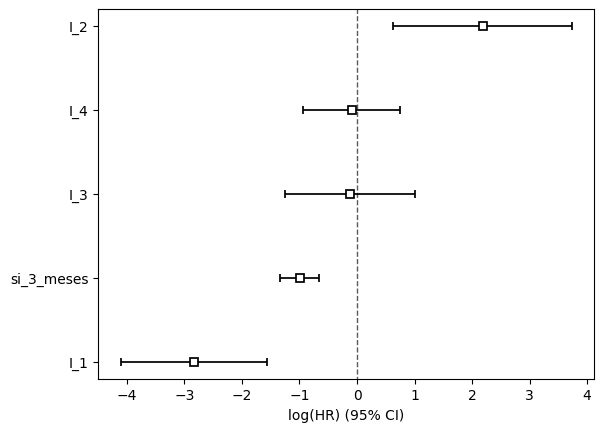

In [49]:
ctv_lineal = CoxTimeVaryingFitter()
ctv_lineal.fit(df_pro, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_lineal.print_summary()
ctv_lineal.plot()

In [ ]:
print(coef_lineal)
print(conf_lineal)

covariate
I_1          -1.067510
I_2           0.414765
I_3           0.051263
I_4          -0.308632
si_3_meses   -0.995663
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
I_1               -1.936424        -0.198597
I_2               -0.846604         1.676135
I_3               -1.161697         1.264223
I_4               -1.203345         0.586082
si_3_meses        -1.339220        -0.652106


In [51]:
I_10 = 1-np.exp(coef_lineal[0])
I_20 = 1-np.exp(coef_lineal[0] + coef_lineal[1])
I_30 = 1-np.exp(coef_lineal[0] + coef_lineal[1] + coef_lineal[2])
I_40 = 1-np.exp(coef_lineal[0] + coef_lineal[1] + coef_lineal[2]+ coef_lineal[3])

print(I_10)
print(I_20)
print(I_30)
print(I_40)

0.9414477357429889
0.4810704830793838
0.5429303455445778
0.583600746564043


In [50]:
coef_lineal = ctv_lineal.params_
conf_lineal = ctv_lineal.confidence_intervals_

hazard_ratios_lineal = 1-np.exp(coef_lineal)
hazard_ratios_conf_int_lineal = 1-np.exp(conf_lineal)
print(hazard_ratios_lineal)
print(hazard_ratios_conf_int_lineal)

covariate
I_1           0.941448
I_2          -7.862672
I_3           0.119207
I_4           0.088981
si_3_meses    0.630057
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
I_1                0.983533         0.791802
I_2               -0.883181       -40.709720
I_3                0.715814        -1.729893
I_4                0.607874        -1.116554
si_3_meses         0.736937         0.479753


In [ ]:
coef_lineal = ctv_lineal.params_
conf_lineal = ctv_lineal.confidence_intervals_

hazard_ratios_lineal = 1-np.exp(coef_lineal)
hazard_ratios_conf_int_lineal = 1-np.exp(conf_lineal)
print(hazard_ratios_lineal)
print(hazard_ratios_conf_int_lineal)

covariate
I_1           0.656136
I_2          -0.514016
I_3          -0.052599
I_4           0.265549
si_3_meses    0.630522
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
I_1                0.855781         0.180119
I_2                0.571131        -4.344859
I_3                0.687046        -2.540340
I_4                0.699812        -0.796934
si_3_meses         0.737950         0.479053


In [ ]:
y = [0,0,0,0]  
j=0
r=1
for i in hazard_ratios_lineal:
    j=j+i
    y[r]=j
    r=r+1
y

[0, 0.6154707418315103, 0.4511578742342036, 0.9937503926086225]

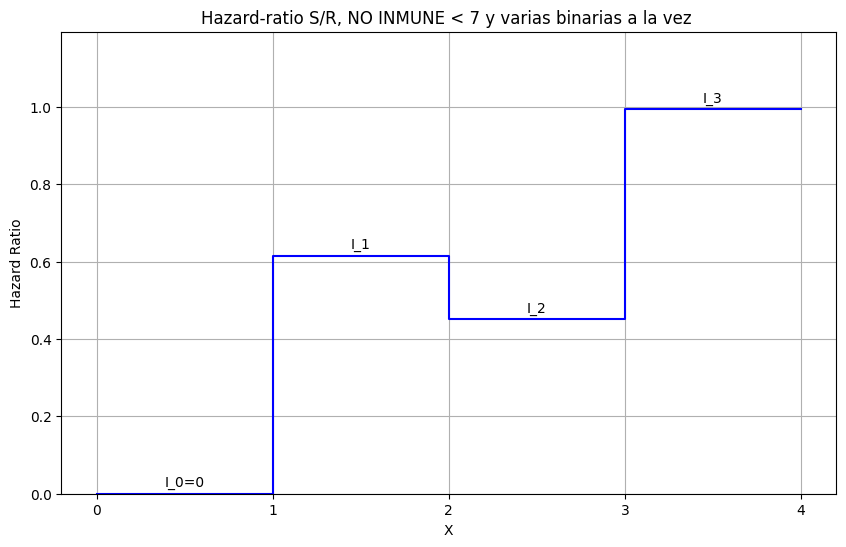

In [ ]:

x = [0, 1, 2, 3, 4]
y = [0,0,0,0,0]  
j=0
r=1
for i in hazard_ratios_lineal:
    j=j+i
    if r==3:
        y[r+1]=j
    y[r]=j
    r=r+1



plt.figure(figsize=(10, 6))
plt.step(x, y, where='post', linestyle='-', color='b')

plt.text(x[1] - 0.5, 0 + 0.01, 'I_0=0', ha='center', va='bottom', color='black')
for i, hr in enumerate(y):
    if i ==3:
        break
    plt.text(x[i+2] - 0.5, y[i+1] + 0.01, f'I_{i+1}', ha='center', va='bottom', color='black')


plt.xlabel('X')
plt.ylabel('Hazard Ratio')
plt.title('Hazard-ratio S/R, NO INMUNE < 7 y varias binarias a la vez ')

plt.xticks(np.arange(min(x), max(x)+1, 1))

plt.ylim(bottom=0, top=max(y) + 0.2)  

# Mostrar el gráfico
plt.grid(True)
plt.show()

## Modelo_0 UPC

In [1554]:
df_f=dfs[26]
df_f.shape[0]

109013

In [1555]:
df_f['event'] = (df_f['fecha_upc'].notna()) & (df_f['VRS']==1)

In [1556]:
print("inmunes vrs upc:", df_f[(df_f['event']==1) & (df_f['inmunizado']==1)].shape[0])
print("no inmunes vrs upc:",df_f[(df_f['event']==1) & (df_f['inmunizado']==0)].shape[0])

inmunes vrs upc: 17
no inmunes vrs upc: 26


In [1557]:
df_f.loc[ (~df_f['event']), 'fecha_upc'] = pd.NaT
df_f.loc[(df_f['FECHA_INMUNIZACION'] >= df_f['fecha_upc']) & (df_f.event ==1 ), 'FECHA_INMUNIZACION'] = pd.NaT

In [1560]:
base_df = df_f[['RUN','SEXO','sex*prem','prematuro_extremo','muy_prematuro','prematuro_moderado','prematuro','FECHA_NAC','FECHA_INMUNIZACION','FECHA_ING','fecha_upc','inmunizado','group','event','age_3m','age_6m','si_3_meses','si_6_meses']]
base_df = base_df.sort_values(by='event')
base_df

,RUN,SEXO,sex*prem,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,fecha_upc,inmunizado,group,event,age_3m,age_6m,si_3_meses,si_6_meses
208,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,1,0,0,0,0,0,2024-02-20,NaT,2024-04-27,NaT,0,CATCH_UP,False,NaT,NaT,0,0
77233,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,1,0,0,0,0,0,2024-03-21,2024-04-04,NaT,NaT,1,CATCH_UP,False,NaT,NaT,0,0
77232,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,1,0,0,0,0,0,2024-03-23,2024-04-15,NaT,NaT,1,CATCH_UP,False,NaT,NaT,0,0
77231,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,1,0,0,0,0,0,2024-03-12,2024-04-30,NaT,NaT,1,CATCH_UP,False,NaT,NaT,0,0
77230,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,0,0,0,0,1,1,2024-03-20,NaT,NaT,NaT,0,CATCH_UP,False,NaT,NaT,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43380,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,0,0,0,0,0,0,2024-01-08,2024-04-10,2024-05-08,2024-05-08,1,CATCH_UP,True,2024-04-08,NaT,1,0
43291,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,0,0,0,0,0,0,2024-01-09,NaT,2024-05-31,2024-05-31,0,CATCH_UP,True,2024-04-09,NaT,1,0
78796,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,1,0,0,0,1,1,2024-03-26,NaT,2024-05-31,2024-05-31,0,CATCH_UP,True,NaT,NaT,0,0
32146,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,0,0,0,0,0,0,2023-12-14,NaT,2024-04-09,2024-04-09,0,CATCH_UP,True,2024-03-14,NaT,1,0


In [1561]:
vrs = base_df[base_df.event == 1]
df_vrs = base_df[base_df.RUN.isin(vrs.RUN.unique())]
df_vrs = df_vrs.drop_duplicates(subset=['RUN'], keep='last')
base_df = base_df[~base_df.RUN.isin(vrs.RUN.unique())]
base_df = pd.concat([base_df,df_vrs])
base_df

,RUN,SEXO,sex*prem,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,fecha_upc,inmunizado,group,event,age_3m,age_6m,si_3_meses,si_6_meses
208,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,1,0,0,0,0,0,2024-02-20,NaT,2024-04-27,NaT,0,CATCH_UP,False,NaT,NaT,0,0
77233,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,1,0,0,0,0,0,2024-03-21,2024-04-04,NaT,NaT,1,CATCH_UP,False,NaT,NaT,0,0
77232,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,1,0,0,0,0,0,2024-03-23,2024-04-15,NaT,NaT,1,CATCH_UP,False,NaT,NaT,0,0
77231,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,1,0,0,0,0,0,2024-03-12,2024-04-30,NaT,NaT,1,CATCH_UP,False,NaT,NaT,0,0
77230,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,0,0,0,0,1,1,2024-03-20,NaT,NaT,NaT,0,CATCH_UP,False,NaT,NaT,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43380,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,0,0,0,0,0,0,2024-01-08,2024-04-10,2024-05-08,2024-05-08,1,CATCH_UP,True,2024-04-08,NaT,1,0
43291,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,0,0,0,0,0,0,2024-01-09,NaT,2024-05-31,2024-05-31,0,CATCH_UP,True,2024-04-09,NaT,1,0
78796,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,1,0,0,0,1,1,2024-03-26,NaT,2024-05-31,2024-05-31,0,CATCH_UP,True,NaT,NaT,0,0
32146,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,0,0,0,0,0,0,2023-12-14,NaT,2024-04-09,2024-04-09,0,CATCH_UP,True,2024-03-14,NaT,1,0


In [1562]:
T_inicial = pd.to_datetime('2024-03-31')
T_0_inmune = pd.to_datetime(df['FECHA_INMUNIZACION'].min())
T_0_inmune = df['FECHA_INMUNIZACION'].min()
#T_final_inmune = df['FECHA_INMUNIZACION'].max()

#base_df['long_inmune'] = (base_df['FECHA_INMUNIZACION'] - T_0_inmune).dt.days
base_df['age_3m'] = (base_df['age_3m'] - T_inicial).dt.days
base_df['age_6m'] = (base_df['age_6m'] - T_inicial).dt.days
base_df['FECHA_INMUNIZACION'] = (base_df['FECHA_INMUNIZACION'] - T_inicial).dt.days
base_df['FECHA_ING'] = (base_df['FECHA_ING'] - T_inicial).dt.days
base_df['FECHA_NAC'] = (base_df['FECHA_NAC'] - T_inicial).dt.days
base_df['fecha_upc'] = (base_df['fecha_upc'] - T_inicial).dt.days

base_df['start'] = np.where(base_df['group']=="CATCH_UP", 0, base_df['FECHA_NAC'])

base_df['age_3m'] = np.where(base_df['age_3m']<=0, 0, base_df['age_3m'])
base_df['age_6m'] = np.where(base_df['age_6m']<=0, 0, base_df['age_6m'])
#base_df['si_3_meses'] = np.ones(len(base_df))


base_df

,RUN,SEXO,sex*prem,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,FECHA_NAC,FECHA_INMUNIZACION,FECHA_ING,fecha_upc,inmunizado,group,event,age_3m,age_6m,si_3_meses,si_6_meses,start
208,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,1,0,0,0,0,0,-40,NaN,27.0,NaN,0,CATCH_UP,False,NaN,NaN,0,0,0
77233,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,1,0,0,0,0,0,-10,4.0,NaN,NaN,1,CATCH_UP,False,NaN,NaN,0,0,0
77232,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,1,0,0,0,0,0,-8,15.0,NaN,NaN,1,CATCH_UP,False,NaN,NaN,0,0,0
77231,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,1,0,0,0,0,0,-19,30.0,NaN,NaN,1,CATCH_UP,False,NaN,NaN,0,0,0
77230,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,0,0,0,0,1,1,-11,NaN,NaN,NaN,0,CATCH_UP,False,NaN,NaN,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43380,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,0,0,0,0,0,0,-83,10.0,38.0,38.0,1,CATCH_UP,True,8.0,NaN,1,0,0
43291,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,0,0,0,0,0,0,-82,NaN,61.0,61.0,0,CATCH_UP,True,9.0,NaN,1,0,0
78796,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,1,0,0,0,1,1,-5,NaN,61.0,61.0,0,CATCH_UP,True,NaN,NaN,0,0,0
32146,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,0,0,0,0,0,0,-108,NaN,9.0,9.0,0,CATCH_UP,True,0.0,NaN,1,0,0


In [1563]:
df_model = pd.melt(base_df, id_vars=['RUN'], value_vars=['FECHA_INMUNIZACION', 'FECHA_ING','fecha_upc','age_3m','age_6m'],var_name='fecha', value_name='duration',ignore_index=True)
df_model = df_model.merge(base_df[['RUN','inmunizado','event','si_3_meses','si_6_meses','SEXO','sex*prem','prematuro_extremo','muy_prematuro','prematuro_moderado','prematuro'
                                   ]], on = 'RUN' , how='left')
#df_model['group']=np.where(df_model['group']=='CATCH_UP',1,0)
df_model

,RUN,fecha,duration,inmunizado,event,si_3_meses,si_6_meses,SEXO,sex*prem,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro
0,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,FECHA_INMUNIZACION,NaN,0,False,0,0,1,0,0,0,0,0
1,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,FECHA_INMUNIZACION,4.0,1,False,0,0,1,0,0,0,0,0
2,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,FECHA_INMUNIZACION,15.0,1,False,0,0,1,0,0,0,0,0
3,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,FECHA_INMUNIZACION,30.0,1,False,0,0,1,0,0,0,0,0
4,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,FECHA_INMUNIZACION,NaN,0,False,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
545100,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,age_6m,NaN,1,True,1,0,0,0,0,0,0,0
545101,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,age_6m,NaN,0,True,1,0,0,0,0,0,0,0
545102,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,age_6m,NaN,0,True,0,0,1,0,0,0,1,1
545103,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,age_6m,NaN,0,True,1,0,0,0,0,0,0,0


In [1564]:
base = df_model[df_model.fecha=='fecha_upc'][['RUN','SEXO','sex*prem','prematuro_extremo','muy_prematuro','prematuro_moderado','prematuro','duration','event']].drop_duplicates(subset=['RUN'])
base['duration'] = base['duration'].fillna(df_model.duration.max()) ############################################ SE PONE LA MAXIMA FECHA POSIBLE
base

,RUN,SEXO,sex*prem,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,duration,event
218042,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,1,0,0,0,0,0,76.0,False
218043,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,1,0,0,0,0,0,76.0,False
218044,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,1,0,0,0,0,0,76.0,False
218045,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,1,0,0,0,0,0,76.0,False
218046,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,0,0,0,0,1,1,76.0,False
...,...,...,...,...,...,...,...,...,...
327058,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,0,0,0,0,0,0,38.0,True
327059,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,0,0,0,0,0,0,61.0,True
327060,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,1,0,0,0,1,1,61.0,True
327061,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,0,0,0,0,0,0,9.0,True


In [1565]:
base = to_long_format(base, duration_col="duration")
base[base.event==0]

,RUN,SEXO,sex*prem,prematuro_extremo,muy_prematuro,prematuro_moderado,prematuro,event,start,stop
218042,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,1,0,0,0,0,0,False,0,76.0
218043,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,1,0,0,0,0,0,False,0,76.0
218044,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,1,0,0,0,0,0,False,0,76.0
218045,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,1,0,0,0,0,0,False,0,76.0
218046,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,0,0,0,0,1,1,False,0,76.0
...,...,...,...,...,...,...,...,...,...,...
327015,3345b26d07bd38feeffba92cb23c8a668fdb6f1fab5aa6...,0,0,0,0,1,1,False,0,76.0
327016,a060e73c2f1a0fe45d7601755076d8aa675b07ec9752eb...,0,0,0,0,0,0,False,0,76.0
327017,d0f754b9fbab46fce4ed88894fd2e0f09c15d042edc243...,1,0,0,0,0,0,False,0,76.0
327018,f90d393b63bcc3d437706acbee4e02a762d3afaf02eb14...,1,0,0,0,0,0,False,0,76.0


In [1570]:
base_fp=base

In [1571]:
covs_fijas1 = base_fp[['RUN','prematuro']]
covs_fijas2 = base_fp[['RUN','muy_prematuro','prematuro_moderado']]
covs_fijas3 = base_fp[['RUN','SEXO','muy_prematuro']]
covs_fijas4 = base_fp[['RUN','SEXO','muy_prematuro','prematuro_moderado']]
covs_fijas5 = base_fp[['RUN','SEXO','muy_prematuro',"sex*prem"]]
covs=[covs_fijas1, covs_fijas2, covs_fijas3, covs_fijas4, covs_fijas5]

In [1541]:
base = base[['RUN','stop','event']].merge(base_df[['RUN','start']],on='RUN',how='left')
base

,RUN,stop,event,start
0,287086f05217c4a191fc43338d1e4bbb8f97bd77a0afb4...,76.0,False,0
1,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,76.0,False,0
2,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,76.0,False,0
3,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,76.0,False,0
4,b37daebe99e458bef470d9ea606f51197ec1fe3bdd64b2...,76.0,False,0
...,...,...,...,...
109008,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,38.0,True,0
109009,9a5b6c73c780f7bf9c6fd74cda84ed6dc7713a90ba51d6...,61.0,True,0
109010,48db1def0f9b13b21aa74d99cc6426bc10db720e609695...,61.0,True,0
109011,df8a9a6bcfcfbb06336e62b3e9876ce3d7c787bb72b980...,9.0,True,0


In [1542]:
cv = df_model[df_model.fecha=='FECHA_INMUNIZACION'][['RUN','duration','inmunizado']]
cv = cv.rename(columns={'duration':'time'})
cv = cv.dropna()
cv

,RUN,time,inmunizado
1,fda60723b4c6a5b4835f399e4e2a3789a6c5a3c3b578f2...,4.0,1
2,2ad2293cb9d58557c545fede0b97852ba3b843efce2186...,15.0,1
3,503e033f61a8af092de25f926c364dbc491dbfdff838a1...,30.0,1
5,e8bfe39babaf7be0b7208d535c632df0fdf3d308f34b9b...,11.0,1
6,6e338861580ebfa55f0baf789c5d4b8d169d1a6d19aac6...,12.0,1
...,...,...,...
109013,b12b7d88d37f1443cae317c7a8e58c04913de20b88c12e...,9.0,1
109014,7dc5fd45dce636f0b0a2311030720add6bdb74bb86750c...,33.0,1
109015,eb40617231c7ed55574343e9ffd7876403ca6d3bd3818b...,29.0,1
109016,8d6c1dbdbde85321513ea834ce9559f191aaffd4a7824e...,10.0,1


In [1475]:
df_upc = add_covariate_to_timeline(base, cv, duration_col="time", id_col="RUN", event_col="event")
df_upc['inmunizado'].fillna(0,inplace=True)
df_upc['stop'].replace(0,base.stop.max(),inplace=True)
df_upc

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\3966045812.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_upc['inmunizado'].fillna(0,inplace=True)
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\3966045812.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

,start,inmunizado,stop,RUN,event
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
1,24.0,1.0,76.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False
2,29.0,0.0,76.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False
3,0.0,0.0,60.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False
4,60.0,1.0,76.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False
...,...,...,...,...,...
196733,5.0,1.0,76.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False
196734,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
196735,54.0,1.0,76.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False
196736,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False


Iteration 1: norm_delta = 8.89e-01, step_size = 0.9500, log_lik = -493.48543, newton_decrement = 1.21e+01, seconds_since_start = 0.2
Iteration 2: norm_delta = 1.06e-01, step_size = 0.9500, log_lik = -483.19469, newton_decrement = 2.11e-01, seconds_since_start = 0.4
Iteration 3: norm_delta = 3.53e-03, step_size = 0.9500, log_lik = -482.98628, newton_decrement = 2.42e-04, seconds_since_start = 0.6
Iteration 4: norm_delta = 1.84e-04, step_size = 1.0000, log_lik = -482.98603, newton_decrement = 5.97e-07, seconds_since_start = 0.8
Iteration 5: norm_delta = 3.32e-09, step_size = 1.0000, log_lik = -482.98603, newton_decrement = 1.94e-16, seconds_since_start = 1.0
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 196738 periods, 109009 subjects, 43 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 196738
  number of events = 43
partial log-likelihood = -482.99
  time fit was run = 2024-08-21 13:14:36 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -1.56      0.21      0.34           -2.22           -0.90                0.11                0.41

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -4.63 <0.005     18.03
---
Partial AIC = 967.97
log-likelihood ratio test = 21.00 on 1 df
-log2(p) of ll-ratio test = 17.73

<Axes: xlabel='log(HR) (95% CI)'>

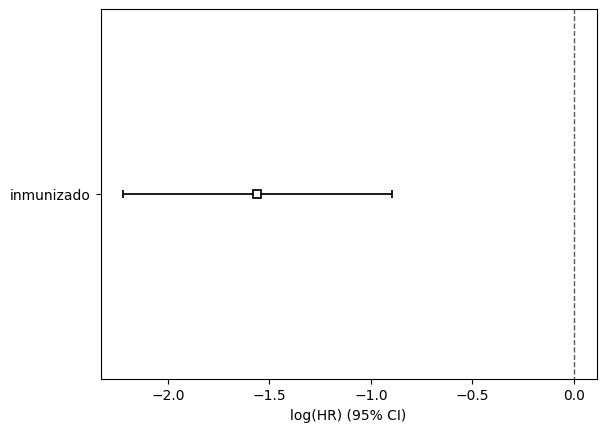

In [1545]:
ctv = CoxTimeVaryingFitter()
ctv.fit(df_upc, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv.print_summary()
ctv.plot()


Iteration 1: norm_delta = 9.53e-01, step_size = 0.9500, log_lik = -493.48543, newton_decrement = 1.44e+01, seconds_since_start = 0.3
Iteration 2: norm_delta = 1.31e-01, step_size = 0.9500, log_lik = -482.69711, newton_decrement = 1.12e+00, seconds_since_start = 0.7
Iteration 3: norm_delta = 3.21e-02, step_size = 0.9500, log_lik = -481.46160, newton_decrement = 9.85e-02, seconds_since_start = 1.0
Iteration 4: norm_delta = 6.46e-03, step_size = 1.0000, log_lik = -481.35686, newton_decrement = 2.90e-03, seconds_since_start = 1.3
Iteration 5: norm_delta = 1.62e-04, step_size = 1.0000, log_lik = -481.35391, newton_decrement = 1.74e-06, seconds_since_start = 1.7
Iteration 6: norm_delta = 9.93e-08, step_size = 1.0000, log_lik = -481.35391, newton_decrement = 6.53e-13, seconds_since_start = 2.0
Convergence completed after 6 iterations.
-----------------------MODELO INMUNE +, RUN, SEXO, muy_prematuro, sex*prem ------------------------------


<lifelines.CoxTimeVaryingFitter: fitted with 196738 periods, 109009 subjects, 43 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 196738
  number of events = 43
partial log-likelihood = -481.35
  time fit was run = 2024-08-21 13:40:20 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
inmunizado         -1.58      0.21      0.34           -2.24           -0.92                0.11                0.40
muy_prematuro       1.38      3.97      0.73           -0.05            2.80                0.96               16.52
prematuro_moderado  0.49      1.64      0.48           -0.44            1.43                0.64                4.17

                    cmp to     z      p  -log2(p)
covariate                                        
inmunizado            0.00 -4.68 <0.005     18.44
muy_prematuro         0.00  1.90   0.06      4.11
prematuro_moderado    0.00  1.03   0.30      1.72
---
Partial AIC = 968.71
log-likelihood ratio test = 24.26 on 3 df
-log2(p) of ll-ratio test = 15.47

covariate
inmunizado           -1.579939
muy_prematuro         1.379534
prematuro_moderado    0.491968
dtype: float64
                    95% lower-bound  95% upper-bound
covariate                                           
inmunizado                -2.240967        -0.918911
muy_prematuro             -0.045327         2.804395
prematuro_moderado        -0.443836         1.427772


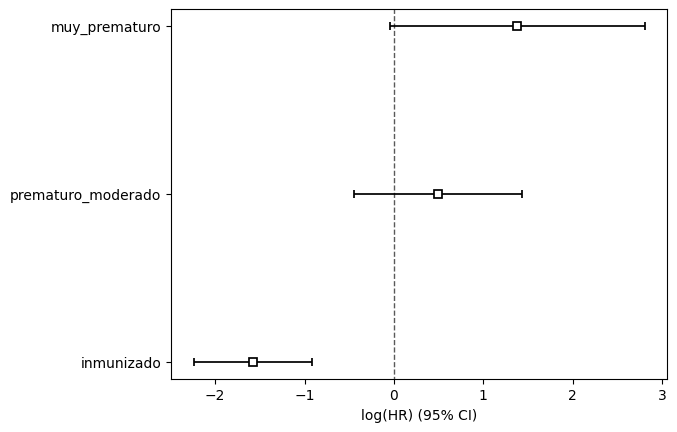

In [1573]:
d=df_upc.merge(covs_fijas2, on='RUN',how='left') 
ctv_01 = CoxTimeVaryingFitter()
ctv_01.fit(d, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
print("-----------------------MODELO INMUNE +,", ', '.join(i), "------------------------------")
ctv_01.print_summary()
ctv_01.plot()

coef_01 = ctv_01.params_
conf_01 = ctv_01.confidence_intervals_

print(coef_01)
print(conf_01)

In [1479]:
cv_3m = df_model[df_model.fecha=='age_3m'][['RUN','duration','si_3_meses']]
cv_3m = cv_3m.rename(columns={'duration':'time'})
cv_3m = cv_3m.dropna()
df_upc3m = add_covariate_to_timeline(df_upc, cv_3m, duration_col="time", id_col="RUN", event_col="event") 
df_upc3m['si_3_meses'].fillna(0,inplace=True)
df_upc3m['inmunizado'].fillna(0,inplace=True)
df_upc3m['stop'].replace(0,base.stop.max(),inplace=True)
df_upc3m

C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\945069318.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_upc3m['si_3_meses'].fillna(0,inplace=True)
C:\Users\ntrig\AppData\Local\Temp\ipykernel_2488\945069318.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

,start,inmunizado,stop,RUN,event,si_3_meses
0,0.0,0.0,24.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0
1,24.0,1.0,76.0,000011c71163b51c8177b20780b7e19c7401473945e402...,False,0.0
2,29.0,0.0,76.0,0000777dd97e631613b120b5833ca26bdaffbec66fe197...,False,0.0
3,0.0,0.0,60.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False,1.0
4,60.0,1.0,76.0,0000c85ea91c4bfc077bc159b58cc90eae9a74a0ef81d7...,False,1.0
...,...,...,...,...,...,...
205105,5.0,1.0,76.0,fffff711e38f71fbaaf01193ab00f99ab28431e9b97714...,False,0.0
205106,0.0,0.0,54.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0
205107,54.0,1.0,76.0,fffffe8c29ae493cb7ead69d260caa0af4cea3a44a5dba...,False,0.0
205108,0.0,0.0,5.0,ffffff5a8b5bca8f04fa51bbda2a0e6c7aafece6180370...,False,1.0


Iteration 1: norm_delta = 9.95e-01, step_size = 0.9500, log_lik = -493.48543, newton_decrement = 1.51e+01, seconds_since_start = 0.3
Iteration 2: norm_delta = 1.09e-01, step_size = 0.9500, log_lik = -480.16566, newton_decrement = 2.42e-01, seconds_since_start = 0.7
Iteration 3: norm_delta = 3.93e-03, step_size = 0.9500, log_lik = -479.92610, newton_decrement = 3.37e-04, seconds_since_start = 1.0
Iteration 4: norm_delta = 2.07e-04, step_size = 1.0000, log_lik = -479.92576, newton_decrement = 8.44e-07, seconds_since_start = 1.4
Iteration 5: norm_delta = 6.56e-09, step_size = 1.0000, log_lik = -479.92576, newton_decrement = 7.41e-16, seconds_since_start = 1.7
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 205110 periods, 109009 subjects, 43 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205110
  number of events = 43
partial log-likelihood = -479.93
  time fit was run = 2024-08-21 13:16:18 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -1.64      0.19      0.34           -2.31           -0.98                0.10                0.37
si_3_meses -0.78      0.46      0.33           -1.43           -0.14                0.24                0.87

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -4.86 <0.005     19.69
si_3_meses    0.00 -2.39   0.02      5.90
---
Partial AIC = 963.85
log-likelihood ratio test = 27.12 on 2 df
-log2(p) of ll-ratio test = 19.56

covariate
inmunizado    0.806818
si_3_meses    0.543315
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.900470         0.625045
si_3_meses         0.759668         0.132195


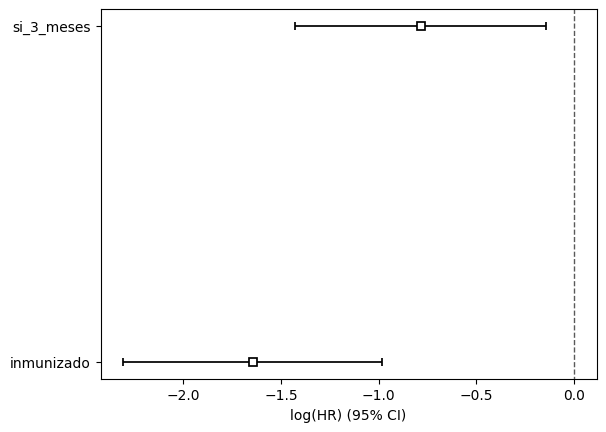

In [1548]:
ctv_upc3m = CoxTimeVaryingFitter()
ctv_upc3m.fit(df_upc3m, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
ctv_upc3m.print_summary()
ctv_upc3m.plot()

coef_01 = ctv_upc3m.params_
conf_01 = ctv_upc3m.confidence_intervals_

hazard_ratios_01 = 1-np.exp(coef_01)
hazard_ratios_conf_int_01 = 1-np.exp(conf_01)
print(hazard_ratios_01)
print(hazard_ratios_conf_int_01)

Iteration 1: norm_delta = 1.03e+00, step_size = 0.9500, log_lik = -493.48543, newton_decrement = 1.63e+01, seconds_since_start = 0.4
Iteration 2: norm_delta = 1.15e-01, step_size = 0.9500, log_lik = -479.21355, newton_decrement = 2.83e-01, seconds_since_start = 0.7
Iteration 3: norm_delta = 4.78e-03, step_size = 0.9500, log_lik = -478.93291, newton_decrement = 5.91e-04, seconds_since_start = 1.1
Iteration 4: norm_delta = 2.57e-04, step_size = 1.0000, log_lik = -478.93232, newton_decrement = 1.56e-06, seconds_since_start = 1.4
Iteration 5: norm_delta = 2.63e-08, step_size = 1.0000, log_lik = -478.93232, newton_decrement = 2.22e-14, seconds_since_start = 1.8
Convergence completed after 5 iterations.
-----------------------MODELO INMUNE +, RUN, prematuro ------------------------------


<lifelines.CoxTimeVaryingFitter: fitted with 205110 periods, 109009 subjects, 43 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205110
  number of events = 43
partial log-likelihood = -478.93
  time fit was run = 2024-08-21 13:35:50 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
inmunizado -1.65      0.19      0.34           -2.32           -0.99                0.10                0.37
si_3_meses -0.78      0.46      0.33           -1.42           -0.14                0.24                0.87
prematuro   0.63      1.87      0.41           -0.18            1.44                0.83                4.20

            cmp to     z      p  -log2(p)
covariate                                
inmunizado    0.00 -4.89 <0.005     19.93
si_3_meses    0.00 -2.38   0.02      5.84
prematuro     0.00  1.51   0.13      2.94
---
Partial AIC = 963.86
log-likelihood ratio test = 29.11 on 3 df
-log2(p) of ll-ratio test = 18.84

covariate
inmunizado    0.808820
si_3_meses    0.540806
prematuro    -0.869489
dtype: float64
            95% lower-bound  95% upper-bound
covariate                                   
inmunizado         0.901477         0.629024
si_3_meses         0.758333         0.127481
prematuro          0.168348        -3.202470
Iteration 1: norm_delta = 1.05e+00, step_size = 0.9500, log_lik = -493.48543, newton_decrement = 1.74e+01, seconds_since_start = 0.4
Iteration 2: norm_delta = 1.37e-01, step_size = 0.9500, log_lik = -479.84350, newton_decrement = 1.25e+00, seconds_since_start = 0.8
Iteration 3: norm_delta = 3.39e-02, step_size = 0.9500, log_lik = -478.46333, newton_decrement = 1.13e-01, seconds_since_start = 1.2
Iteration 4: norm_delta = 7.21e-03, step_size = 1.0000, log_lik = -478.34253, newton_decrement = 3.64e-03, seconds_since_start = 1.5
Iteration 5: norm_delta = 2.03e-04, step_size = 1.0000, log_lik = -478.33883, newton_decrement = 2.72e-06, seconds_since_start = 1.9
Iteration 6: nor

<lifelines.CoxTimeVaryingFitter: fitted with 205110 periods, 109009 subjects, 43 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205110
  number of events = 43
partial log-likelihood = -478.34
  time fit was run = 2024-08-21 13:35:53 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
inmunizado         -1.66      0.19      0.34           -2.32           -1.00                0.10                0.37
si_3_meses         -0.78      0.46      0.33           -1.42           -0.14                0.24                0.87
muy_prematuro       1.35      3.87      0.73           -0.07            2.78                0.93               16.10
prematuro_moderado  0.49      1.63      0.48           -0.45            1.42                0.64                4.15

                    cmp to     z      p  -log2(p)
covariate                                        
inmunizado            0.00 -4.91 <0.005     20.03
si_3_meses            0.00 -2.38   0.02      5.83
muy_prematuro         0.00  1.86   0.06      4.00
prematuro_moderado    0.00  1.02   0.31      1.70
---
Partial AIC = 964.68
log-likelihood ratio test = 30.29 on 4 df
-log2(p) of ll-ratio test = 17.84

covariate
inmunizado            0.809629
si_3_meses            0.540591
muy_prematuro        -2.873660
prematuro_moderado   -0.626536
dtype: float64
                    95% lower-bound  95% upper-bound
covariate                                           
inmunizado                 0.901878         0.630652
si_3_meses                 0.758191         0.127178
muy_prematuro              0.067836       -15.097208
prematuro_moderado         0.361959        -3.146475
Iteration 1: norm_delta = 1.06e+00, step_size = 0.9500, log_lik = -493.48543, newton_decrement = 1.77e+01, seconds_since_start = 0.5
Iteration 2: norm_delta = 1.37e-01, step_size = 0.9500, log_lik = -479.48002, newton_decrement = 1.26e+00, seconds_since_start = 1.0
Iteration 3: norm_delta = 3.41e-02, step_size = 0.9500, log_lik = -478.09066, newton_decrement = 1.14e-01, seconds_since_start = 1.4
Iteration 4: norm_delta = 7.26e-03, step_size = 1.0000, log_lik = -477.96873, newton_decrement = 3.69e-03, seconds_since_start = 1.7
I

...

c:\Users\ntrig\Desktop\ISCI\bases de datos\venv\Lib\site-packages\lifelines\fitters\cox_time_varying_fitter.py:488: ConvergenceWarning: Newton-Raphson convergence completed but norm(delta) is still high, 0.150. This may imply non-unique solutions to the maximum likelihood. Perhaps there is colinearity or complete separation in the dataset?
  warnings.warn(


-----------------------MODELO INMUNE +, RUN, SEXO, muy_prematuro, sex*prem ------------------------------


<lifelines.CoxTimeVaryingFitter: fitted with 205110 periods, 109009 subjects, 43 events>
         event col = 'event'
number of subjects = 109009
 number of periods = 205110
  number of events = 43
partial log-likelihood = -477.06
  time fit was run = 2024-08-21 13:36:03 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
inmunizado     -1.66      0.19      0.34           -2.32           -0.99                0.10                0.37
si_3_meses     -0.78      0.46      0.33           -1.42           -0.14                0.24                0.87
SEXO            0.33      1.39      0.32           -0.30            0.95                0.74                2.58
muy_prematuro -18.03      0.00  11009.48       -21596.22        21560.16                0.00                 inf
sex*prem       19.79  3.94e+08  11009.48       -21558.40        21597.98                0.00                 inf

               cmp to     z      p  -log2(p)
covariate                                   
inmunizado       0.00 -4.90 <0.005     19.97
si_3_meses       0.00 -2.38   0.02      5.86
SEXO             0.00  1.03   0.30      1.72
muy_prematuro    0.00 -0.00   1.00      0.00
sex*prem         0.00  0.00   1.00      0.00
---
Partial AIC = 964.11
log-likelihood ratio test = 32.86 on 5 df
-log2(p) of ll-ratio test = 17.93

covariate
inmunizado       8.090101e-01
si_3_meses       5.415605e-01
SEXO            -3.855777e-01
muy_prematuro    1.000000e+00
sex*prem        -3.936789e+08
dtype: float64
               95% lower-bound  95% upper-bound
covariate                                      
inmunizado            0.901545         0.629503
si_3_meses            0.758695         0.129042
SEXO                  0.255621        -1.579096
muy_prematuro         1.000000             -inf
sex*prem              1.000000             -inf


c:\Users\ntrig\Desktop\ISCI\bases de datos\venv\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


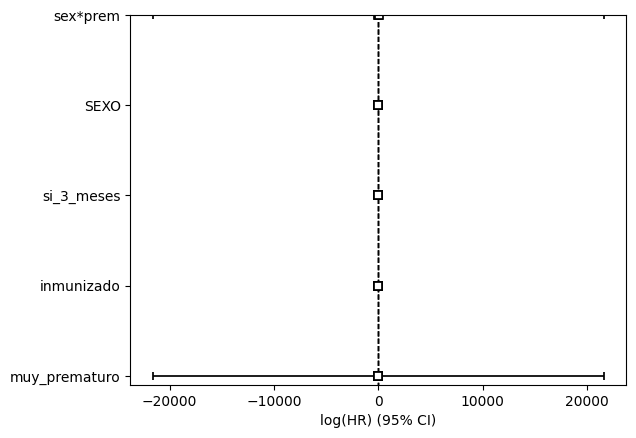

In [1572]:
for i in covs:
    d=df_upc3m.merge(i, on='RUN',how='left') 
    ctv_01 = CoxTimeVaryingFitter()
    ctv_01.fit(d, id_col="RUN", event_col="event", start_col="start", stop_col="stop", show_progress=True)
    print("-----------------------MODELO INMUNE +,", ', '.join(i), "------------------------------")
    ctv_01.print_summary()
    ctv_01.plot()

    coef_01 = ctv_01.params_
    conf_01 = ctv_01.confidence_intervals_

    hazard_ratios_01 = 1-np.exp(coef_01)
    hazard_ratios_conf_int_01 = 1-np.exp(conf_01)
    print(hazard_ratios_01)
    print(hazard_ratios_conf_int_01)